In [9]:
#import numpy as np
#import matplotlib.pyplot as plt
from helpers.SimulationAnalysis import readHlist, getDistance


GroupHalo352 = [
    ['Group Halo352 CDM', '/Users/roxannelai/ConcertoRCTData/Group_Halo352_CDM_RCT/hlist_1.00000.list', 4e5],
    ['Group Halo352 SIDM', '/Users/roxannelai/ConcertoRCTData/Group_Halo352_SIDM_RCT/hlist_1.00000.list',4e5],
    ['Group Halo352 SIDM70', '/Users/roxannelai/ConcertoRCTData/Group_Halo352_SIDM70_RCT/hlist_1.00000.list',4e5]]
GroupHalo962 = [
    ['Group Halo962 CDM', '/Users/roxannelai/ConcertoRCTData/Group_Halo962_CDM_RCT/hlist_1.00000.list',4e5],
    ['Group Halo962 SIDM70', '/Users/roxannelai/ConcertoRCTData/Group_Halo962_SIDM70_RCT/hlist_1.00000.list',4e5]]
LClusterHalo000 = [['LCluster Halo000 SIDM', '/Users/roxannelai/ConcertoRCTData/LCluster_Halo000_SIDM_RCT/hlist_1.00000.list',2.7e7]]
LMCHalo104 = [['LMC Halo104 CDM', '/Users/roxannelai/ConcertoRCTData/LMC_Halo104_CDM_RCT/hlist_1.00000.list',6.3e3],
              ['LMC Halo104 SIDM','/Users/roxannelai/ConcertoRCTData/LMC_Halo104_SIDM_RCT/hlist_1.00000.list',6.3e3]]
MWHalo004 = [['MW Halo004 SIDM', '/Users/roxannelai/ConcertoRCTData/MW_Halo004_SIDM_RCT/hlist_1.00000.list',5e4]]
MWHalo416 = [['MW Halo416 CDM', '/Users/roxannelai/ConcertoRCTData/MW_Halo416_CDM_RCT/hlist_1.00000.list',5e4],
             ['MW Halo416 MWSIDM', '/Users/roxannelai/ConcertoRCTData/MW_Halo416_MilkyWaySIDM_RCT/hlist_1.00000.list',5e4]]

list_of_halos = [GroupHalo352, GroupHalo962, LClusterHalo000, LMCHalo104, MWHalo004, MWHalo416]


# particle_mass = 4e5           
#mass_cut = 300 * particle_mass   # Msun
#h_hubble = 0.7

def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host
'''
import numpy as np
import matplotlib.pyplot as plt
import os
from helpers.SimulationAnalysis import readHlist, getDistance


hlist_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists'
hlist_path = os.path.join(hlist_dir, 'hlist_1.00000.list')
print(hlist_path)

bins, N, bins_half, N_half, host = get_shmf(hlist_path, 6.3e3)

plt.plot(bins[:-1],N,label="z=0")
plt.show()

'''

n_groups = len(list_of_halos)
#ncols = 3
#nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(2, n_groups, figsize=(4 * n_groups, 8), sharex='col')

for igroup, ihalo in enumerate(list_of_halos):
    ax_top, ax_bot = axes[0, igroup], axes[1, igroup]
    results = {}
    for label, path, particle_mass in ihalo:
        bins, N, bins_half, N_half, host = get_shmf(path, particle_mass)
        results[label] = (bins, N)
        ax_top.plot(bins[:-1], N, label=label)

    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.legend(fontsize=6)
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    ax_top.set_title(group_name, fontsize=10)
    if igroup == 0:
        ax_top.set_ylabel(r"$N_{\rm sub}(>M)$")

    cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
    if cdm_label is not None and len(results) > 1:
        cdm_bins, cdm_N = results[cdm_label]
        common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
        cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
        for label, (bins, N) in results.items():
            if label == cdm_label:
                continue
            N_interp = np.interp(common_mass, bins[:-1], N)
            ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
        ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ax_bot.legend(fontsize=6)
    else:
        ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

    ax_bot.set_xscale('log')
    ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
    if igroup == 0:
        ax_bot.set_ylabel("Ratio")

fig.suptitle("SHMF and CDM Ratios by Group", fontsize=14)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'helpers'

In [2]:
import sys
!{sys.executable} -m pip install numpy pandas --user

/cm/shared/apps/spack/0.17.3/cpu/b/opt/spack/linux-rocky8-zen2/gcc-10.2.0/python-3.8.12-7zdjza7xxfccxr5syuaomd2fpvp2x35i/bin/python3.8: No module named pip


In [8]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib helpers --user

You should consider upgrading via the '/cm/shared/apps/spack/0.17.3/cpu/b/opt/spack/linux-rocky8-zen2/gcc-10.2.0/python-3.8.12-7zdjza7xxfccxr5syuaomd2fpvp2x35i/bin/python3.8 -m pip install --upgrade pip' command.


In [4]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install numpy pandas matplotlib --user

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /scratch/rlai3/job_52628905/tmpwasooxvx
Processing /scratch/rlai3/job_52628905/tmpwasooxvx/pip-21.1.1-py3-none-any.whl
     |████████████████████████████████| 17.3 MB 19.4 MB/s eta 0:00:01
     |████████████████████████████████| 12.4 MB 115.9 MB/s eta 0:00:01
     |████████████████████████████████| 9.2 MB 103.9 MB/s eta 0:00:01     |████████████████████████████▌   | 8.2 MB 103.9 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 125.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.5 MB 115.1 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 120.0 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 113.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 110.8 MB/s eta 0:00:01
You should consider upgrading via the '/cm/shared/apps/spack/0.17.3/cpu/b/opt/spack/linux-rocky8-zen2/gcc-10.2.0/python-3.8.12-7zdjza7xxfccxr5syuaomd2fpvp2

In [10]:
import sys
!{sys.executable} -m pip uninstall helpers -y

Found existing installation: helpers 0.2.0
Uninstalling helpers-0.2.0:
  Successfully uninstalled helpers-0.2.0


In [2]:
# import symlib

path_to_halo = "/projects/ddp469/enadler/Concerto/Symfind/ConcertoGroupHR/Halo352-CDM/halos/"
h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
print(h['id'])


NameError: name 'readHlist' is not defined

In [3]:
import SimulationAnalysis

In [5]:
import SimulationAnalysis
from helpers.SimulationAnalysis import readHlist

ModuleNotFoundError: No module named 'helpers'

In [6]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance

ModuleNotFoundError: No module named 'helpers'

In [8]:
!ls -la /expanse/lustre/projects/ddp469/rlai3/helpers/

total 608
drwxr-xr-x 3 rlai3 ddp469 57344 Jul 30 10:05 .
drwxr-s--- 5 rlai3 ddp469 57344 Jul 30 10:05 ..
-rw-r--r-- 1 rlai3 ddp469 11879 Jul 30 10:05 CorrelationFunction.py
-rw-r--r-- 1 rlai3 ddp469  3694 Jul 30 10:05 distributeMUSICBndryPart.py
-rw-r--r-- 1 rlai3 ddp469  2358 Jul 30 10:05 findLagrangianVolume.py
-rw-r--r-- 1 rlai3 ddp469  5393 Jul 30 10:05 findSpheresInSnapshots.py
-rw-r--r-- 1 rlai3 ddp469  1084 Jul 30 10:05 getMUSICregion.py
-rw-r--r-- 1 rlai3 ddp469  1729 Jul 30 10:05 getSDSSid.py
-rw-r--r-- 1 rlai3 ddp469    55 Jul 30 10:05 __init__.py
-rw-r--r-- 1 rlai3 ddp469  3732 Jul 30 10:05 io_utils.py
-rw-r--r-- 1 rlai3 ddp469  2395 Jul 30 10:05 mvee.py
drwxr-xr-x 2 rlai3 ddp469 57344 Jul 30 10:05 __pycache__
-rw-r--r-- 1 rlai3 ddp469  4493 Jul 30 10:05 readGadgetSnapshot.py
-rw-r--r-- 1 rlai3 ddp469 10481 Jul 30 10:05 shuffleMockCatalog.py
-rw-r--r-- 1 rlai3 ddp469  1409 Jul 30 10:05 shuffleRanks.py
-rw-r--r-- 1 rlai3 ddp469 21582 Jul 30 10:05 SimulationAnalysis.py
-rw-r--

In [9]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance

In [11]:

import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance

hlist_path = "/projects/ddp469/enadler/Concerto/Symfind/ConcertoGroupHR/Halo352-CDM/halos/"
h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

FileNotFoundError: [Errno 2] No such file or directory: '/projects/ddp469/enadler/Concerto/Symfind/ConcertoGroupHR/Halo352-CDM/halos/'

In [14]:
!ls -la /expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/ConcertoGroupHR/Halo352-CDM/halos/

total 11850165
drwxr-sr-x 2 sroy16 ddp469      57344 Jul  7 13:50 .
drwxr-sr-x 4 sroy16 ddp469      57344 Jul  7 13:39 ..
-rw-r--r-- 1 sroy16 ddp469   68242504 Jul  7 13:50 core.0.txt
-rw-r--r-- 1 sroy16 ddp469     784246 Jul  7 13:50 core.1.txt
-rw-r--r-- 1 sroy16 ddp469     784371 Jul  7 13:50 core.2.txt
-rw-r--r-- 1 sroy16 ddp469     784342 Jul  7 13:50 core.3.txt
-rw-r--r-- 1 sroy16 ddp469     784359 Jul  7 13:50 core.4.txt
-rw-r--r-- 1 sroy16 ddp469   77772400 Jul  7 13:50 cores.dat
-rw-r--r-- 1 sroy16 ddp469     611344 Jul  7 13:50 infall_cores.dat
-rw-r--r-- 1 sroy16 ddp469       1896 Jul  7 13:50 snap_scale.dat
-rw-r--r-- 1 sroy16 ddp469   45104552 Jul  7 13:50 subhalos.dat
-rw-r--r-- 1 sroy16 ddp469 1671619928 Jul  7 13:48 tree_0.dat
-rw-r--r-- 1 sroy16 ddp469 3026512004 Jul  7 13:47 tree_1.dat
-rw-r--r-- 1 sroy16 ddp469  743796376 Jul  7 13:48 tree_2.dat
-rw-r--r-- 1 sroy16 ddp469 4706903460 Jul  7 13:44 tree_3.dat
-rw-r--r-- 1 sroy16 ddp469 1254348148 Jul  7 13:48 tree_4.dat

In [16]:
!ls -la /expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/

total 47326326
drwxr-sr-x 2 sroy16 ddp469    113152 Jul  7 14:06 .
drwxr-sr-x 6 sroy16 ddp469    113152 Jul  7 14:06 ..
-rw-r--r-- 1 sroy16 ddp469   6000704 Jul  7 14:05 hlist_0.05000.list
-rw-r--r-- 1 sroy16 ddp469   7491782 Jul  7 14:05 hlist_0.05064.list
-rw-r--r-- 1 sroy16 ddp469   8888944 Jul  7 14:05 hlist_0.05129.list
-rw-r--r-- 1 sroy16 ddp469  10318748 Jul  7 14:05 hlist_0.05195.list
-rw-r--r-- 1 sroy16 ddp469  11763450 Jul  7 14:05 hlist_0.05262.list
-rw-r--r-- 1 sroy16 ddp469  13353644 Jul  7 14:05 hlist_0.05329.list
-rw-r--r-- 1 sroy16 ddp469  15057140 Jul  7 14:05 hlist_0.05397.list
-rw-r--r-- 1 sroy16 ddp469  16915318 Jul  7 14:05 hlist_0.05467.list
-rw-r--r-- 1 sroy16 ddp469  18922652 Jul  7 14:05 hlist_0.05537.list
-rw-r--r-- 1 sroy16 ddp469  21090647 Jul  7 14:05 hlist_0.05608.list
-rw-r--r-- 1 sroy16 ddp469  23493124 Jul  7 14:06 hlist_0.05680.list
-rw-r--r-- 1 sroy16 ddp469  26023185 Jul  7 14:05 hlist_0.05753.list
-rw-r--r-- 1 sroy16 ddp469  28769440 Jul  7 14:05 hl

In [19]:
# hlist_path = "/projects/ddp469/enadler/Concerto/Symfind/ConcertoGroupHR/Halo352-CDM/halos/"

hlist_path = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/hlist_1.00000.list"
h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
print(h['id'])

[165992501 166085231 166117088 ... 166502808 166502852 166503778]


In [5]:
def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host

In [6]:
hlist_path = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/hlist_1.00000.list"
h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
print(h['id'])

[165992501 166085231 166117088 ... 166502808 166502852 166503778]


In [3]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance

Text(0.5, 1.0, 'Rockstar SHMF for Halo 352 at hlist_0.20064.list')

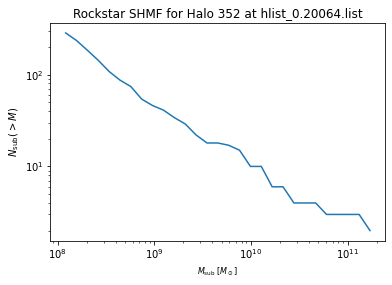

In [13]:


import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt

# how to figure out what redshift an hlist is?

def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host

# pick a random h_list under halo352 cdm
# hlist_0.20064.list
hlist_path = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/hlist_0.20064.list"
particle_mass = 4e5
bins, N, bins_half, N_half, host = get_shmf(hlist_path,particle_mass)
plt.plot(bins[:-1],N)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
plt.ylabel(r"$N_{\rm sub}(>M)$")
plt.title("Rockstar SHMF for Halo 352 at hlist_0.20064.list") 

In [14]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

hlist_dir = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists"

def build_redshift_lookup(hlist_dir):
    """Scan the hlists directory and build a mapping of redshift -> filepath."""
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])  # sort by redshift, low to high
    return lookup

lookup = build_redshift_lookup(hlist_dir)
print(f"Found {len(lookup)} hlists, spanning z = {lookup[0][0]:.3f} to z = {lookup[-1][0]:.3f}")

def find_closest_hlist(target_z, lookup):
    """Return the (z, path) pair closest to the target redshift."""
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

Found 236 hlists, spanning z = 0.000 to z = 19.000


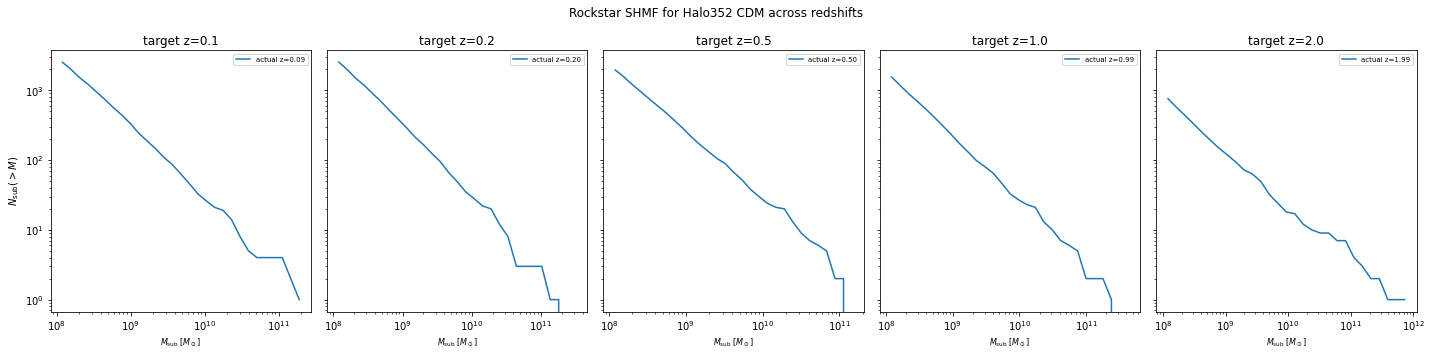

In [15]:
particle_mass = 4e5
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(target_redshifts), figsize=(4 * len(target_redshifts), 5), sharey=True)

for ax, target_z in zip(axes, target_redshifts):
    actual_z, hlist_path = find_closest_hlist(target_z, lookup)
    bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

    ax.plot(bins[:-1], N, label=f"actual z={actual_z:.2f}")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
    ax.set_title(f"target z={target_z}")
    ax.legend(fontsize=7)

axes[0].set_ylabel(r"$N_{\rm sub}(>M)$")
fig.suptitle("Rockstar SHMF for Halo352 CDM across redshifts")
plt.tight_layout()
plt.show()

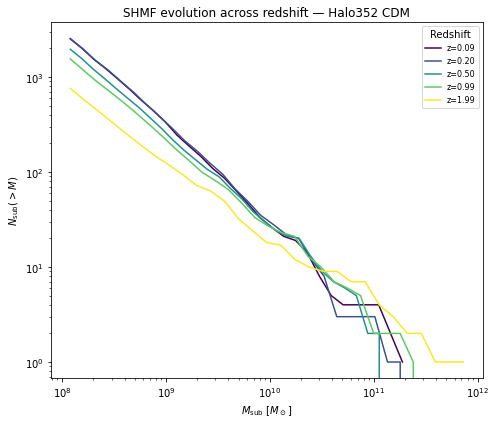

In [16]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

hlist_dir = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists"

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

lookup = build_redshift_lookup(hlist_dir)
particle_mass = 4e5
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.get_cmap("viridis")

for i, target_z in enumerate(target_redshifts):
    actual_z, hlist_path = find_closest_hlist(target_z, lookup)
    bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

    color = cmap(i / max(len(target_redshifts) - 1, 1))
    ax.plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=10)
ax.set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)
ax.set_title("SHMF evolution across redshift — Halo352 CDM")
ax.legend(fontsize=8, title="Redshift")
plt.tight_layout()
plt.show()

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

hlist_dir = "/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists"

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

lookup = build_redshift_lookup(hlist_dir)
particle_mass = 4e5
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.get_cmap("viridis")

for i, target_z in enumerate(target_redshifts):
    actual_z, hlist_path = find_closest_hlist(target_z, lookup)
    bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

    color = cmap(i / max(len(target_redshifts) - 1, 1))
    ax.plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=10)
ax.set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)
ax.set_title("SHMF evolution across redshift — Halo352 CDM")
ax.legend(fontsize=8, title="Redshift")
plt.tight_layout()
plt.show()

In [3]:
GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

NameError: name 'lookup' is not defined

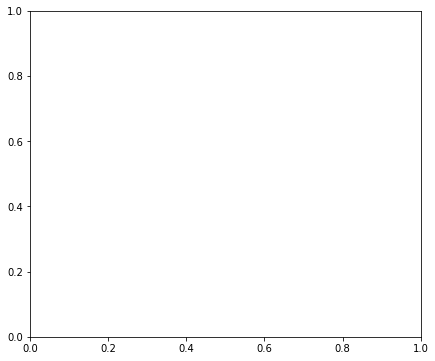

In [10]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re



GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]


def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))



#lookup = build_redshift_lookup(hlist_dir)
#particle_mass = 4e5
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

for label, hlist_path, particle_mass in GroupHalo352:

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.get_cmap("viridis")

    for i, target_z in enumerate(target_redshifts):
        actual_z, hlist_path = find_closest_hlist(target_z, lookup)
        bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

        color = cmap(i / max(len(target_redshifts) - 1, 1))
        ax.plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=10)
    ax.set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)
    ax.set_title(f"SHMF of {label} across redshift {np.min(target_redshifts)},{np.max(target_redshifts)}")
    ax.legend(fontsize=8, title="Redshift")
    plt.tight_layout()
    plt.show()

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')

from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re


In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re

'''GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists', 4e5]]
'''

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???


def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host




def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))
'''
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
fig,ax = plt.subplots(1,3,figsize=(18,7))
ax=ax.flatten()

for i_model,(label, hlist_dir, particle_mass) in enumerate(GroupHalo352):
    lookup = build_redshift_lookup(hlist_dir)   # rebuild per-model

    #fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.get_cmap("viridis")

    for i, target_z in enumerate(target_redshifts):
        actual_z, hlist_path = find_closest_hlist(target_z, lookup)
        bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

        color = cmap(i / max(len(target_redshifts) - 1, 1))
        ax[i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

    ax[i_model].set_xscale('log')
    ax[i_model].set_yscale('log')
    ax[i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=10)
    ax[i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)
    ax[i_model].set_title(f"SHMF of {label} across redshift {np.min(target_redshifts)}–{np.max(target_redshifts)}")
    ax[i_model].legend(fontsize=8, title="Redshift")
plt.tight_layout()
plt.show()'''

'\ntarget_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]\nfig,ax = plt.subplots(1,3,figsize=(18,7))\nax=ax.flatten()\n\nfor i_model,(label, hlist_dir, particle_mass) in enumerate(GroupHalo352):\n    lookup = build_redshift_lookup(hlist_dir)   # rebuild per-model\n\n    #fig, ax = plt.subplots(figsize=(7, 6))\n    cmap = plt.get_cmap("viridis")\n\n    for i, target_z in enumerate(target_redshifts):\n        actual_z, hlist_path = find_closest_hlist(target_z, lookup)\n        bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)\n\n        color = cmap(i / max(len(target_redshifts) - 1, 1))\n        ax[i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")\n\n    ax[i_model].set_xscale(\'log\')\n    ax[i_model].set_yscale(\'log\')\n    ax[i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\\odot$]", fontsize=10)\n    ax[i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)\n    ax[i_model].set_title(f"SHMF of {label} across redshift {np.min(target_redshifts)}–{np.max(target_re

In [2]:
Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???

In [3]:
for i_halo in list_of_halos:
    for label, hlist_path,particle_mass in i_halo:
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
        print(h['id'])

IsADirectoryError: [Errno 21] Is a directory: '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

In [3]:
import os

for i_halo in list_of_halos:
    for label, hlist_dir, particle_mass in i_halo:
        if not os.path.isdir(hlist_dir):
            print(f"{label}: DIRECTORY NOT FOUND -> {hlist_dir}")
            continue

        hlist_files = sorted(f for f in os.listdir(hlist_dir) if f.startswith('hlist_') and f.endswith('.list'))
        if not hlist_files:
            print(f"{label}: no hlist files found in {hlist_dir}")
            continue

        test_file = os.path.join(hlist_dir, hlist_files[0])
        try:
            h = readHlist(test_file, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
            print(f"{label}: OK — {len(h['id'])} halos (tested file: {hlist_files[0]})")
        except Exception as e:
            print(f"{label}: FAILED to read {hlist_files[0]} — {e}")

Halo352 CDM: OK — 8858 halos (tested file: hlist_0.05000.list)
Halo352 SIDM: OK — 7551 halos (tested file: hlist_0.05000.list)
Halo352 SIDM70: OK — 8425 halos (tested file: hlist_0.05000.list)
Halo962 CDM: OK — 18395 halos (tested file: hlist_0.05000.list)
Halo962 SIDM: OK — 19256 halos (tested file: hlist_0.05000.list)
Halo000 CDM: OK — 57 halos (tested file: hlist_0.07699.list)
Halo000 SIDM: OK — 59 halos (tested file: hlist_0.07699.list)
Halo104 CDM: OK — 5436 halos (tested file: hlist_0.05000.list)
Halo104 GroupSIDM: OK — 5262 halos (tested file: hlist_0.05000.list)
Halo416 CDM: OK — 638 halos (tested file: hlist_0.05000.list)
Halo416 SIDM: OK — 20747 halos (tested file: hlist_0.05000.list)


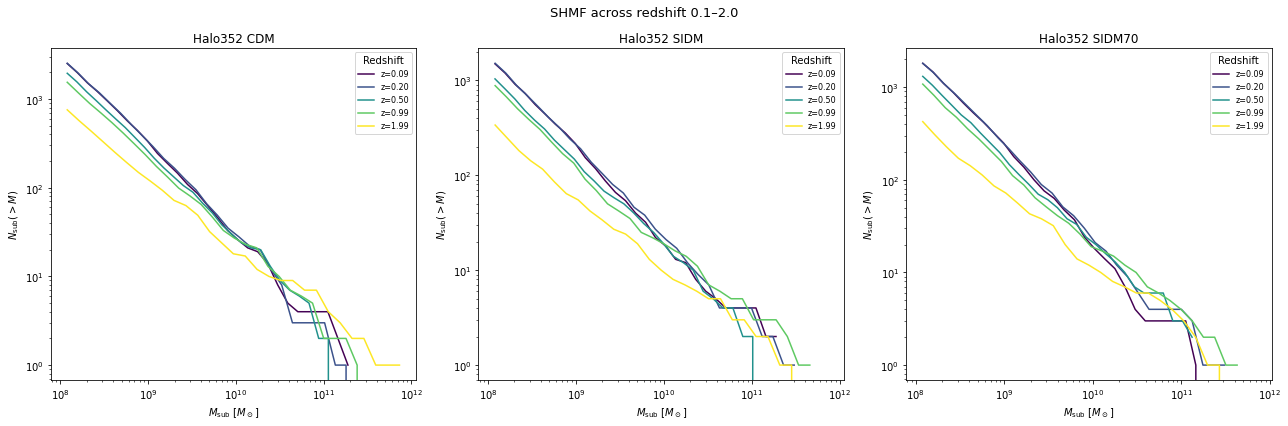

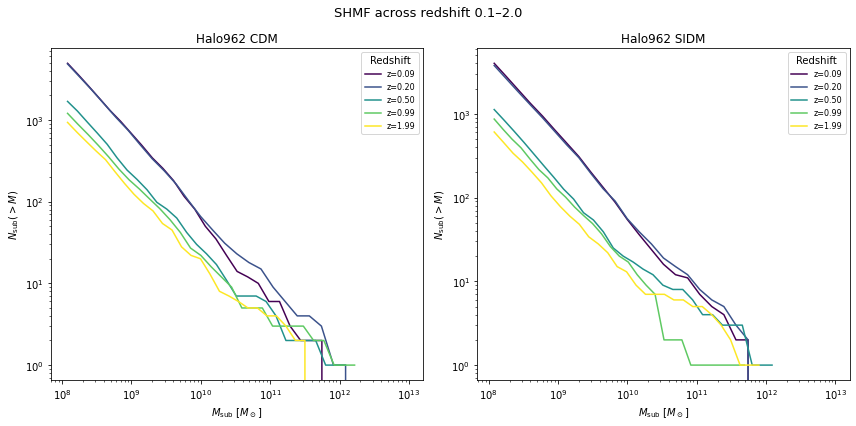

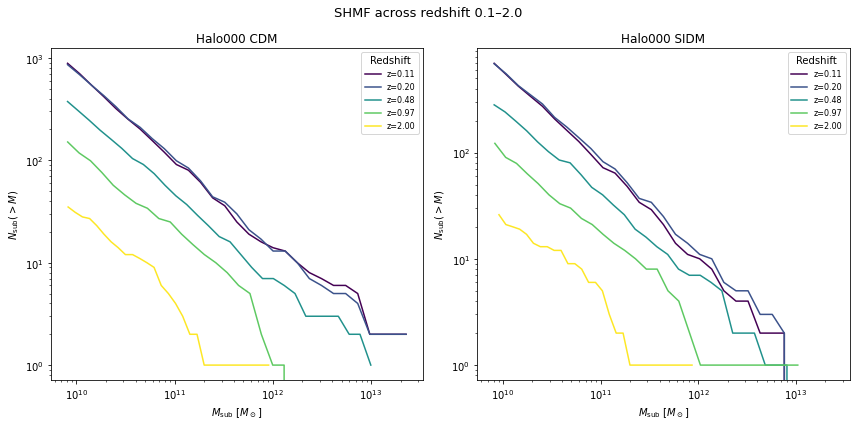

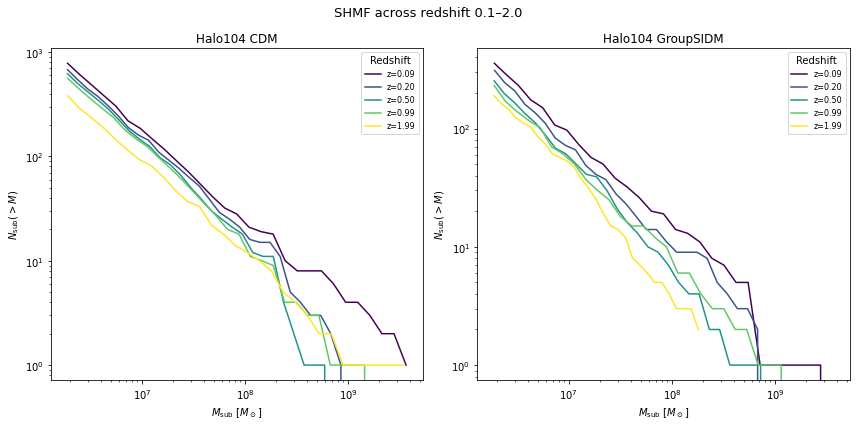

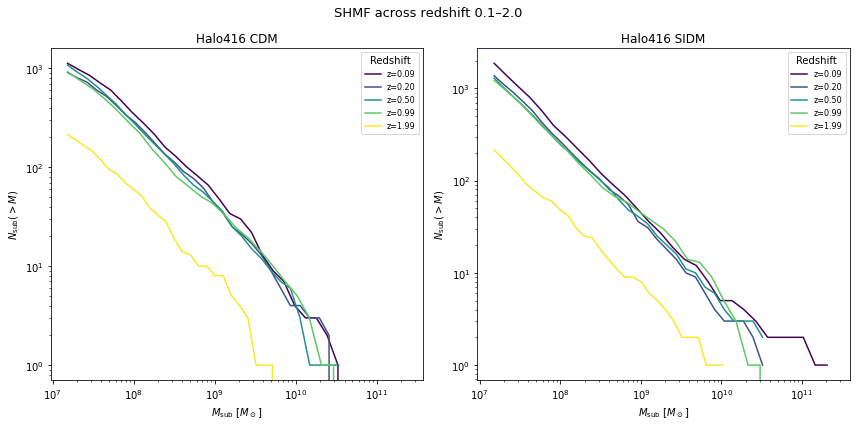

In [4]:
target_redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

for halo in list_of_halos:
    n_models = len(halo)
    fig, ax = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
    if n_models == 1:
        ax = [ax]  # keep indexing consistent even with a single model
    else:
        ax = ax.flatten()

    cmap = plt.get_cmap("viridis")

    for i_model, (label, hlist_dir, particle_mass) in enumerate(halo):
        lookup = build_redshift_lookup(hlist_dir)

        for i, target_z in enumerate(target_redshifts):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

            color = cmap(i / max(len(target_redshifts) - 1, 1))
            ax[i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

        ax[i_model].set_xscale('log')
        ax[i_model].set_yscale('log')
        ax[i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=10)
        ax[i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=10)
        ax[i_model].set_title(label)
        ax[i_model].legend(fontsize=8, title="Redshift")

    fig.suptitle(f"SHMF across redshift {np.min(target_redshifts)}–{np.max(target_redshifts)}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [4]:

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???




target_z = 0
#for i, target_z in enumerate(target_redshifts):
actual_z, hlist_path = find_closest_hlist(target_z, lookup)
bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)


for igroup, ihalo

n_groups = len(list_of_halos)
#ncols = 3
#nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(2, n_groups, figsize=(4 * n_groups, 8), sharex='col')

for igroup, ihalo in enumerate(list_of_halos):
    ax_top, ax_bot = axes[0, igroup], axes[1, igroup]
    results = {}
    for label, path, particle_mass in ihalo:
        bins, N, bins_half, N_half, host = get_shmf(path, particle_mass)
        results[label] = (bins, N)
        ax_top.plot(bins[:-1], N, label=label)

    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.legend(fontsize=6)
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    ax_top.set_title(group_name, fontsize=10)
    if igroup == 0:
        ax_top.set_ylabel(r"$N_{\rm sub}(>M)$")

    cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
    if cdm_label is not None and len(results) > 1:
        cdm_bins, cdm_N = results[cdm_label]
        common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
        cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
        for label, (bins, N) in results.items():
            if label == cdm_label:
                continue
            N_interp = np.interp(common_mass, bins[:-1], N)
            ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
        ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ax_bot.legend(fontsize=6)
    else:
        ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

    ax_bot.set_xscale('log')
    ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
    if igroup == 0:
        ax_bot.set_ylabel("Ratio")

fig.suptitle("SHMF and CDM Ratios by Group", fontsize=14)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1923424955.py, line 35)

KeyboardInterrupt: 

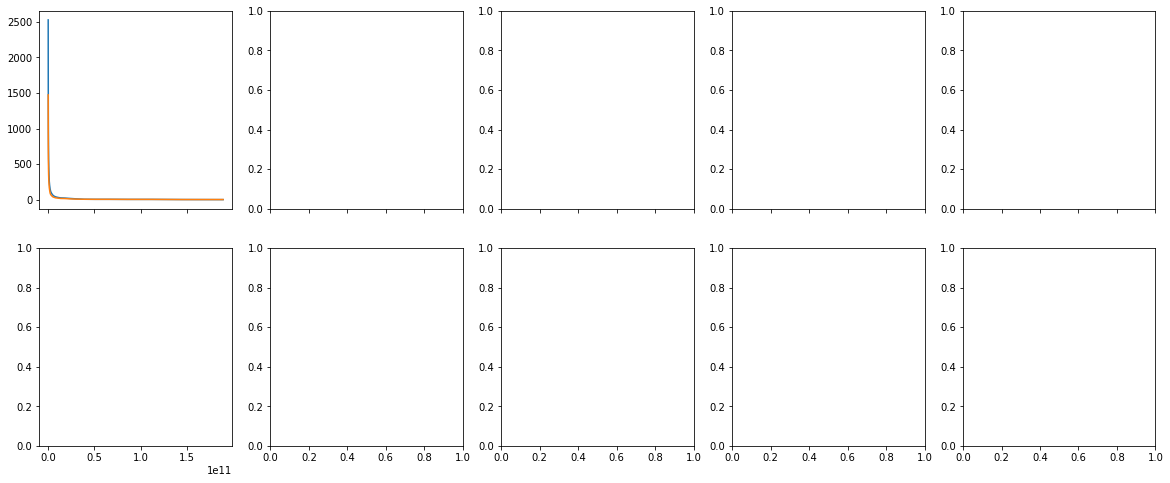

In [7]:
target_z = 0.0
n_groups = len(list_of_halos)

fig, axes = plt.subplots(2, n_groups, figsize=(4 * n_groups, 8), sharex='col')

for igroup, ihalo in enumerate(list_of_halos):
    ax_top, ax_bot = axes[0, igroup], axes[1, igroup]
    results = {}

    for label, hlist_dir, particle_mass in ihalo:
        lookup = build_redshift_lookup(hlist_dir)
        actual_z, hlist_path = find_closest_hlist(target_z, lookup)
        bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

        results[label] = (bins, N)
        ax_top.plot(bins[:-1], N, label=label)

    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.legend(fontsize=6)
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    ax_top.set_title(group_name, fontsize=10)
    if igroup == 0:
        ax_top.set_ylabel(r"$N_{\rm sub}(>M)$")

    cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
    if cdm_label is not None and len(results) > 1:
        cdm_bins, cdm_N = results[cdm_label]
        common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
        cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
        for label, (bins, N) in results.items():
            if label == cdm_label:
                continue
            N_interp = np.interp(common_mass, bins[:-1], N)
            ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
        ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ax_bot.legend(fontsize=6)
    else:
        ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

    ax_bot.set_xscale('log')
    ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
    if igroup == 0:
        ax_bot.set_ylabel("Ratio")

fig.suptitle("SHMF and CDM Ratios by Group (z=0)", fontsize=14)
plt.tight_layout()
plt.show()

/scratch/rlai3/job_52831815/ipykernel_2356524/1310058520.py:40: RuntimeWarning: invalid value encountered in divide
  ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
/scratch/rlai3/job_52831815/ipykernel_2356524/1310058520.py:40: RuntimeWarning: divide by zero encountered in divide
  ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")


KeyboardInterrupt: 

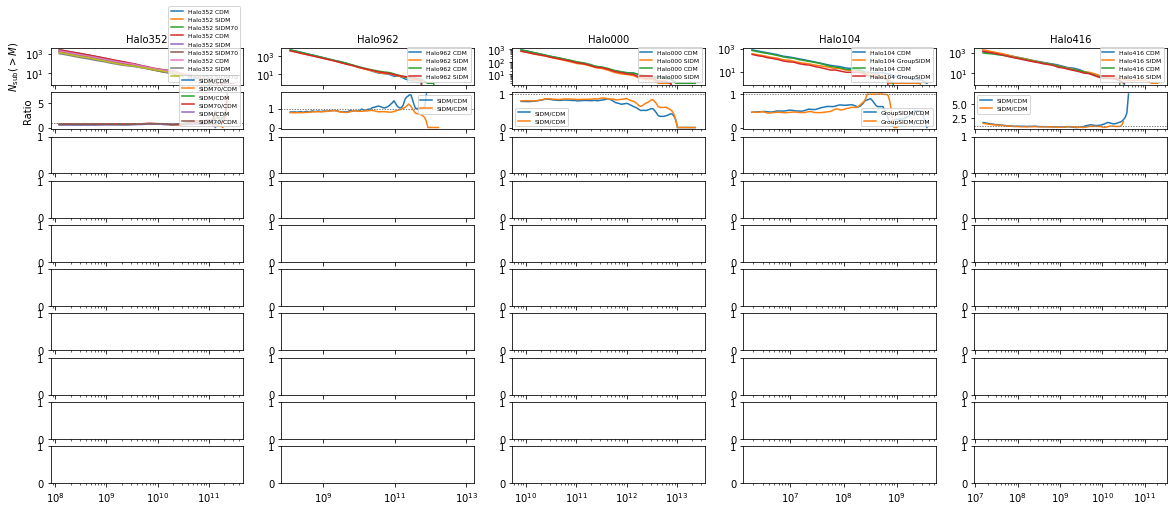

In [5]:
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

#target_z = 0.0
n_groups = len(list_of_halos)

fig, axes = plt.subplots(len(list_of_z)*2, n_groups, figsize=(4 * n_groups, 8), sharex='col')

for target_z in list_of_z: 


    for igroup, ihalo in enumerate(list_of_halos):
        ax_top, ax_bot = axes[0, igroup], axes[1, igroup]
        results = {}

        for label, hlist_dir, particle_mass in ihalo:
            lookup = build_redshift_lookup(hlist_dir)
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

            results[label] = (bins, N)
            ax_top.plot(bins[:-1], N, label=label)

        ax_top.set_xscale('log')
        ax_top.set_yscale('log')
        ax_top.legend(fontsize=6)
        group_name = ihalo[0][0].rsplit(' ', 1)[0]
        ax_top.set_title(group_name, fontsize=10)
        if igroup == 0:
            ax_top.set_ylabel(r"$N_{\rm sub}(>M)$")

        cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
        if cdm_label is not None and len(results) > 1:
            cdm_bins, cdm_N = results[cdm_label]
            common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
            cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
            for label, (bins, N) in results.items():
                if label == cdm_label:
                    continue
                N_interp = np.interp(common_mass, bins[:-1], N)
                ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
            ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
            ax_bot.legend(fontsize=6)
        else:
            ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

        ax_bot.set_xscale('log')
        ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
        if igroup == 0:
            ax_bot.set_ylabel("Ratio")

fig.suptitle("SHMF and CDM Ratios by Group (z=0)", fontsize=14)
plt.tight_layout()
plt.show()

/scratch/rlai3/job_52831815/ipykernel_2356524/4261678474.py:41: RuntimeWarning: invalid value encountered in divide
  ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
/scratch/rlai3/job_52831815/ipykernel_2356524/4261678474.py:41: RuntimeWarning: divide by zero encountered in divide
  ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")


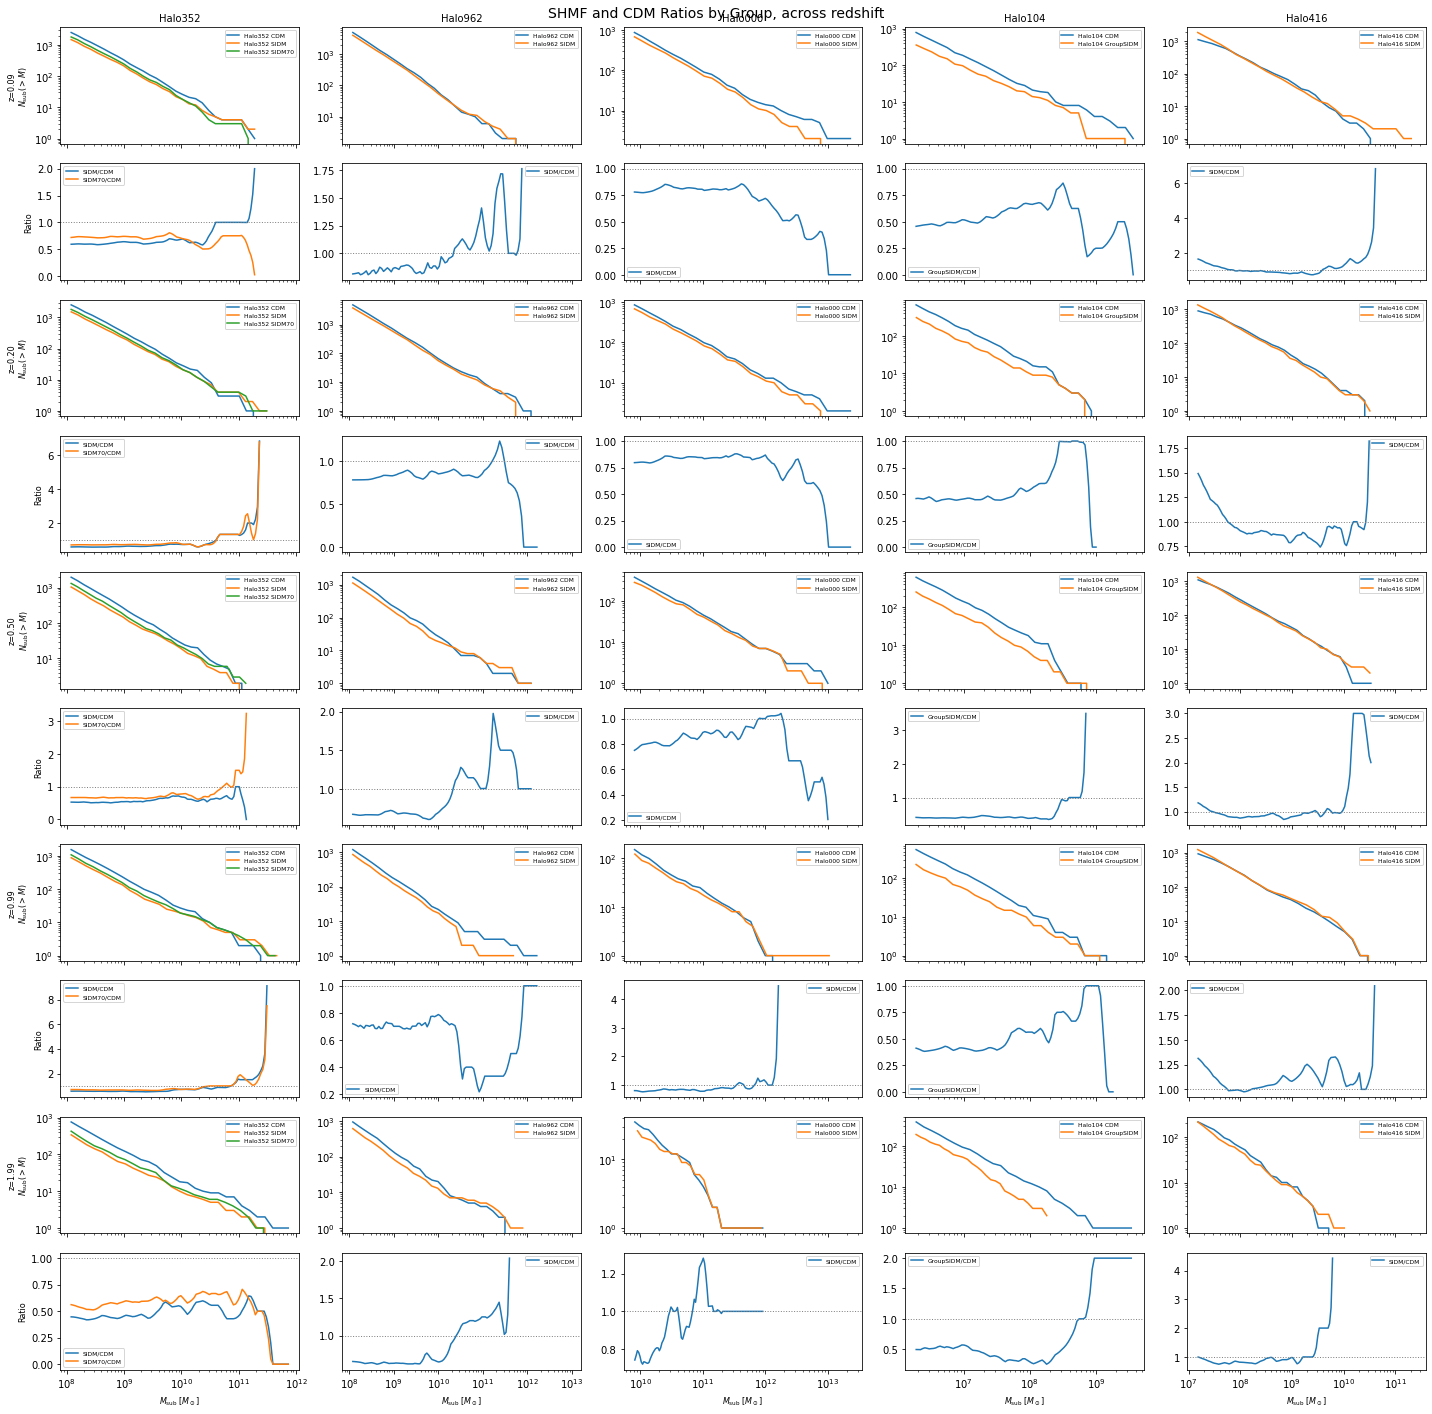

In [6]:
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]
n_groups = len(list_of_halos)
n_z = len(list_of_z)

fig, axes = plt.subplots(n_z * 2, n_groups, figsize=(4 * n_groups, 4 * n_z), sharex='col')

for iz, target_z in enumerate(list_of_z):
    row_top = iz * 2
    row_bot = iz * 2 + 1

    for igroup, ihalo in enumerate(list_of_halos):
        ax_top, ax_bot = axes[row_top, igroup], axes[row_bot, igroup]
        results = {}

        for label, hlist_dir, particle_mass in ihalo:
            lookup = build_redshift_lookup(hlist_dir)
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

            results[label] = (bins, N)
            ax_top.plot(bins[:-1], N, label=label)

        ax_top.set_xscale('log')
        ax_top.set_yscale('log')
        ax_top.legend(fontsize=6)
        group_name = ihalo[0][0].rsplit(' ', 1)[0]
        if iz == 0:
            ax_top.set_title(group_name, fontsize=10)
        if igroup == 0:
            ax_top.set_ylabel(f"z={actual_z:.2f}\n" + r"$N_{\rm sub}(>M)$", fontsize=8)

        cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
        if cdm_label is not None and len(results) > 1:
            cdm_bins, cdm_N = results[cdm_label]
            common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
            cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
            for label, (bins, N) in results.items():
                if label == cdm_label:
                    continue
                N_interp = np.interp(common_mass, bins[:-1], N)
                ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
            ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
            ax_bot.legend(fontsize=6)
        else:
            ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

        ax_bot.set_xscale('log')
        if iz == n_z - 1:
            ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
        if igroup == 0:
            ax_bot.set_ylabel("Ratio", fontsize=8)

fig.suptitle("SHMF and CDM Ratios by Group, across redshift", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
target_z = 0.0
n_groups = len(list_of_halos)

list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]


# plot of 3 subplots: one for cdm, one for sidm, one for evolving ratios
fig, axes = plt.subplots(1,3,figsize = (6,7))
axes.flatten()

#fig, axes = plt.subplots(2, n_groups, figsize=(4 * n_groups, 8), sharex='col')
#for igroup, ihalo in enumerate(list_of_halos):
#    ax_top, ax_bot = axes[0, igroup], axes[1, igroup]
#    results = {}

for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
    lookup = build_redshift_lookup(hlist_dir)
    actual_z, hlist_path = find_closest_hlist(target_z, lookup)
    bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)

    results[label] = (bins, N)
    axes[i_model].plot(bins[:-1],N,label=label)



    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.legend(fontsize=6)

    
group_name = ihalo[0][0].rsplit(' ', 1)[0]
ax_top.set_title(group_name, fontsize=10)
if igroup == 0:
        ax_top.set_ylabel(r"$N_{\rm sub}(>M)$")

    cdm_label = next((lbl for lbl in results if 'CDM' in lbl), None)
    if cdm_label is not None and len(results) > 1:
        cdm_bins, cdm_N = results[cdm_label]
        common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
        cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
        for label, (bins, N) in results.items():
            if label == cdm_label:
                continue
            N_interp = np.interp(common_mass, bins[:-1], N)
            ax_bot.plot(common_mass, N_interp / cdm_N_interp, label=f"{label.split(' ')[-1]}/CDM")
        ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ax_bot.legend(fontsize=6)
    else:
        ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

    ax_bot.set_xscale('log')
    ax_bot.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
    if igroup == 0:
        ax_bot.set_ylabel("Ratio")

fig.suptitle("SHMF and CDM Ratios by Group (z=0)", fontsize=14)
plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re

'''GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists', 4e5]]
'''

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???


def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host




def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

/scratch/rlai3/job_53000976/ipykernel_2276113/2529531345.py:46: RuntimeWarning: divide by zero encountered in divide
  axes[2].plot(common_mass, other_N_interp / cdm_N_interp, color=color, label=f"z={cdm_actual_z:.2f}")


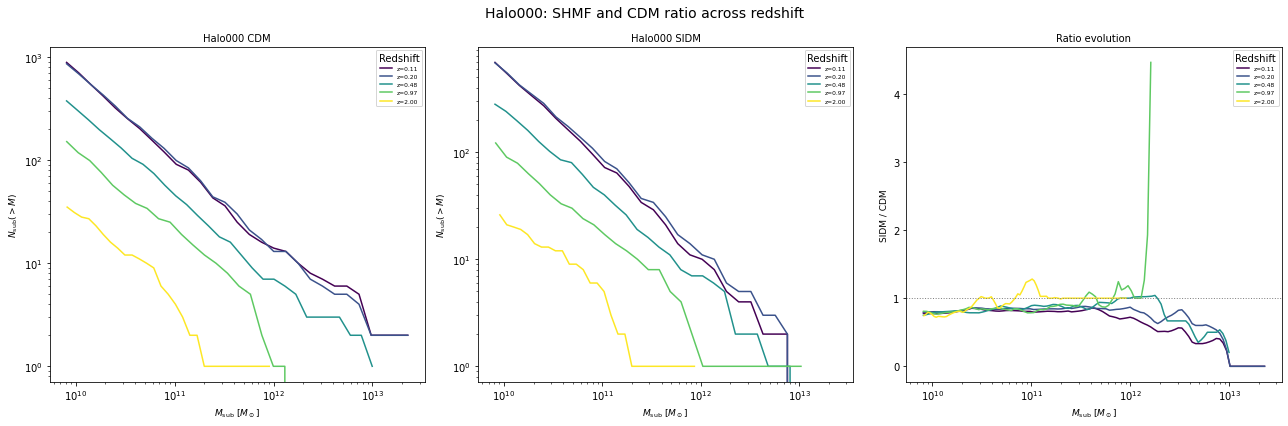

In [8]:
target_z = 0.0
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

Halo000 = [
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists', 2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = plt.get_cmap("viridis")

# --- panels 0 & 1: SHMF evolution for each model ---
model_curves = {}  # label -> {z: (bins, N)}

for i_model, (label, hlist_dir, particle_mass) in enumerate(Halo000):
    lookup = build_redshift_lookup(hlist_dir)
    model_curves[label] = {}

    for i_z, target_z in enumerate(list_of_z):
        actual_z, hlist_path = find_closest_hlist(target_z, lookup)
        bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)
        model_curves[label][target_z] = (bins, N, actual_z)

        color = cmap(i_z / max(len(list_of_z) - 1, 1))
        axes[i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

    axes[i_model].set_xscale('log')
    axes[i_model].set_yscale('log')
    axes[i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=9)
    axes[i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=9)
    axes[i_model].set_title(label, fontsize=10)
    axes[i_model].legend(fontsize=6, title="Redshift")

# --- panel 2: SIDM/CDM ratio evolution, colored by redshift ---
cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
other_label = next((lbl for lbl in model_curves if lbl != cdm_label), None)

for i_z, target_z in enumerate(list_of_z):
    cdm_bins, cdm_N, cdm_actual_z = model_curves[cdm_label][target_z]
    other_bins, other_N, _ = model_curves[other_label][target_z]

    common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
    cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
    other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

    color = cmap(i_z / max(len(list_of_z) - 1, 1))
    axes[2].plot(common_mass, other_N_interp / cdm_N_interp, color=color, label=f"z={cdm_actual_z:.2f}")

axes[2].axhline(1.0, color='gray', linestyle=':', linewidth=1)
axes[2].set_xscale('log')
axes[2].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=9)
axes[2].set_ylabel(f"{other_label.split(' ')[-1]} / CDM", fontsize=9)
axes[2].set_title("Ratio evolution", fontsize=10)
axes[2].legend(fontsize=6, title="Redshift")

fig.suptitle("Halo000: SHMF and CDM ratio across redshift", fontsize=14)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

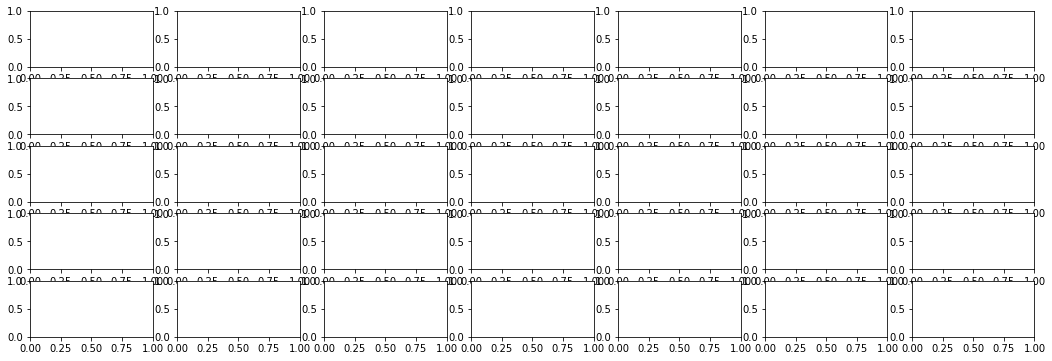

In [3]:
Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???



target_z = 0.0
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

'''Halo000 = [
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists', 2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]]'''


fig, axes = plt.subplots(len(list_of_halos), len(list_of_halos)+2, figsize=(18, 6))
cmap = plt.get_cmap("viridis")

for i_halo in list_of_halos: 

    # --- panels 0 & 1: SHMF evolution for each model ---
    model_curves = {}  # label -> {z: (bins, N)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(Halo000):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, N, actual_z)

            color = cmap(i_z / max(len(list_of_z) - 1, 1))
            axes[i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

        axes[i_model].set_xscale('log')
        axes[i_model].set_yscale('log')
        axes[i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=9)
        axes[i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=9)
        axes[i_model].set_title(label, fontsize=10)
        axes[i_model].legend(fontsize=6, title="Redshift")

    # --- panel 2: SIDM/CDM ratio evolution, colored by redshift ---
    cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
    other_label = next((lbl for lbl in model_curves if lbl != cdm_label), None)

    for i_z, target_z in enumerate(list_of_z):
        cdm_bins, cdm_N, cdm_actual_z = model_curves[cdm_label][target_z]
        other_bins, other_N, _ = model_curves[other_label][target_z]

        common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
        cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
        other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

        color = cmap(i_z / max(len(list_of_z) - 1, 1))
        axes[2].plot(common_mass, other_N_interp / cdm_N_interp, color=color, label=f"z={cdm_actual_z:.2f}")

    axes[2].axhline(1.0, color='gray', linestyle=':', linewidth=1)
    axes[2].set_xscale('log')
    axes[2].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=9)
    axes[2].set_ylabel(f"{other_label.split(' ')[-1]} / CDM", fontsize=9)
    axes[2].set_title("Ratio evolution", fontsize=10)
    axes[2].legend(fontsize=6, title="Redshift")

    fig.suptitle("Halo000: SHMF and CDM ratio across redshift", fontsize=14)
    plt.tight_layout()
    plt.show()

/scratch/rlai3/job_52832718/ipykernel_2380048/2867961330.py:58: RuntimeWarning: divide by zero encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
/scratch/rlai3/job_52832718/ipykernel_2380048/2867961330.py:58: RuntimeWarning: invalid value encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,


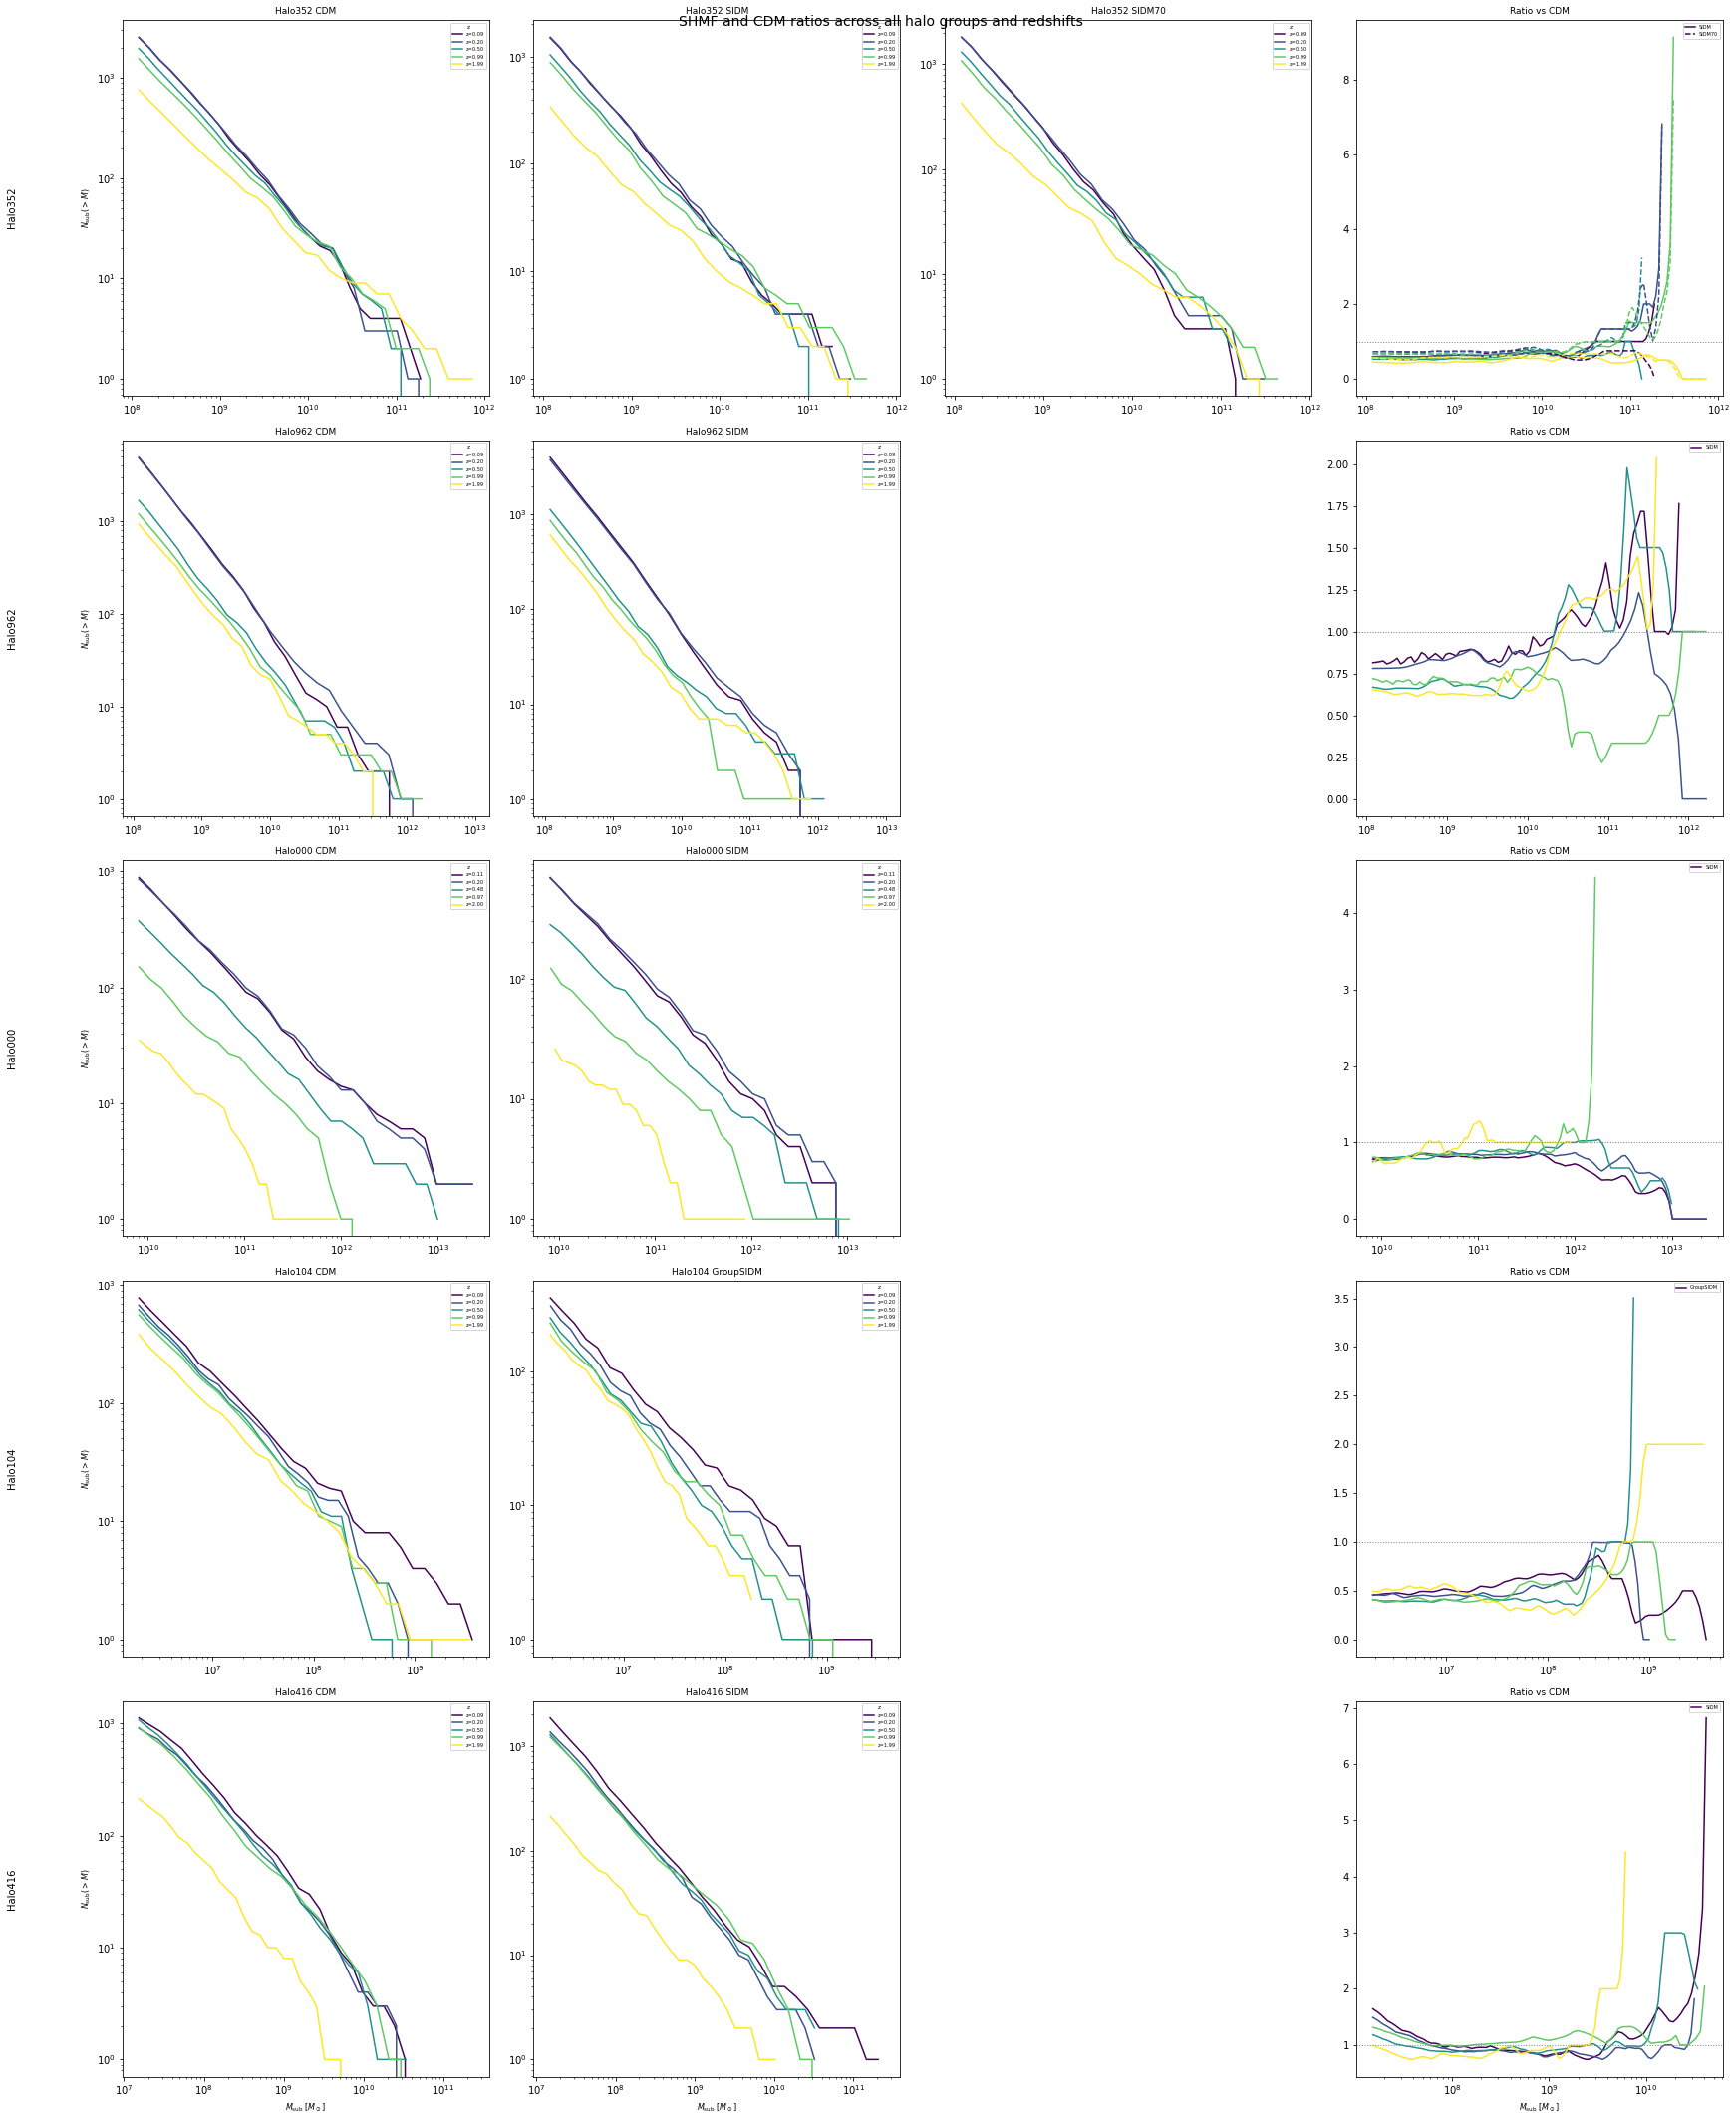

In [5]:
list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

n_groups = len(list_of_halos)
max_models = max(len(h) for h in list_of_halos)
ncols = max_models + 1  # +1 for the ratio panel

fig, axes = plt.subplots(n_groups, ncols, figsize=(6 * ncols, 6 * n_groups))
cmap = plt.get_cmap("viridis")
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

for igroup, ihalo in enumerate(list_of_halos):
    model_curves = {}  # label -> {target_z: (bins, N, actual_z)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host = get_shmf(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, N, actual_z)

            color = cmap(i_z / max(len(list_of_z) - 1, 1))
            axes[igroup, i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

        axes[igroup, i_model].set_xscale('log')
        axes[igroup, i_model].set_yscale('log')
        axes[igroup, i_model].set_title(label, fontsize=9)
        if igroup == n_groups - 1:
            axes[igroup, i_model].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)
        if i_model == 0:
            axes[igroup, i_model].set_ylabel(r"$N_{\rm sub}(>M)$", fontsize=8)
        axes[igroup, i_model].legend(fontsize=5, title="z", title_fontsize=6)

    # hide unused model columns for groups with fewer models
    for empty_col in range(len(ihalo), max_models):
        axes[igroup, empty_col].axis('off')

    # --- ratio panel (last column): all non-CDM models vs CDM ---
    ratio_ax = axes[igroup, -1]
    cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
    other_labels = [lbl for lbl in model_curves if lbl != cdm_label]

    if cdm_label is not None:
        for i_other, other_label in enumerate(other_labels):
            ls = linestyles[i_other % len(linestyles)]
            for i_z, target_z in enumerate(list_of_z):
                cdm_bins, cdm_N, actual_z = model_curves[cdm_label][target_z]
                other_bins, other_N, _ = model_curves[other_label][target_z]

                common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
                cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
                other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

                color = cmap(i_z / max(len(list_of_z) - 1, 1))
                label = f"{other_label.split(' ')[-1]}, z={actual_z:.2f}" if i_z == 0 else None
                ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
                              label=f"{other_label.split(' ')[-1]}" if i_z == 0 else None)

        ratio_ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ratio_ax.legend(fontsize=5)
    else:
        ratio_ax.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ratio_ax.transAxes, fontsize=8)

    ratio_ax.set_xscale('log')
    ratio_ax.set_title("Ratio vs CDM", fontsize=9)
    if igroup == n_groups - 1:
        ratio_ax.set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]", fontsize=8)

    # row label (halo group name) on the far left
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    axes[igroup, 0].annotate(group_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                              fontsize=10, rotation=90, ha='center', va='center')

fig.suptitle("SHMF and CDM ratios across all halo groups and redshifts", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
'''
import numpy as np
import matplotlib.pyplot as plt
from helpers.SimulationAnalysis import readHlist, getDistance
'''
#particle_mass = 4e5
#mass_cut = 300 * particle_mass
#h_hubble = 0.7

def radial_distribution(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )
    #print("Number of subhalos: " + str(n_subs))
    # print(np.max(n_subs))
    
    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    #assert n.sum() == n_subs, (
    #    f"Histogram lost points: sum(n)={n.sum()} but n_subs={n_subs}. "
    #    "Check for dists outside [bins[0], bins[-1]] due to float edge effects."
    #)

    #print("maximum number of subhalos: " + str(np.max(n)))
    return bins, n, host_rvir_mpc, n_subs



In [11]:
# %config InlineBackend.print_figure_kwargs = {'facecolor': 'white'}
Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

for label, hlist_path, particle_mass in Halo352: 
    bins, n, host_rvir_mpc, n_subs = radial_distribution(hlist_path, particle_mass)
    plt.plot(bins[:-1],n, label = label)
    plt.show()

IsADirectoryError: [Errno 21] Is a directory: '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

/scratch/rlai3/job_53035019/ipykernel_3448977/3774906980.py:97: RuntimeWarning: divide by zero encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
/scratch/rlai3/job_53035019/ipykernel_3448977/3774906980.py:97: RuntimeWarning: invalid value encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,


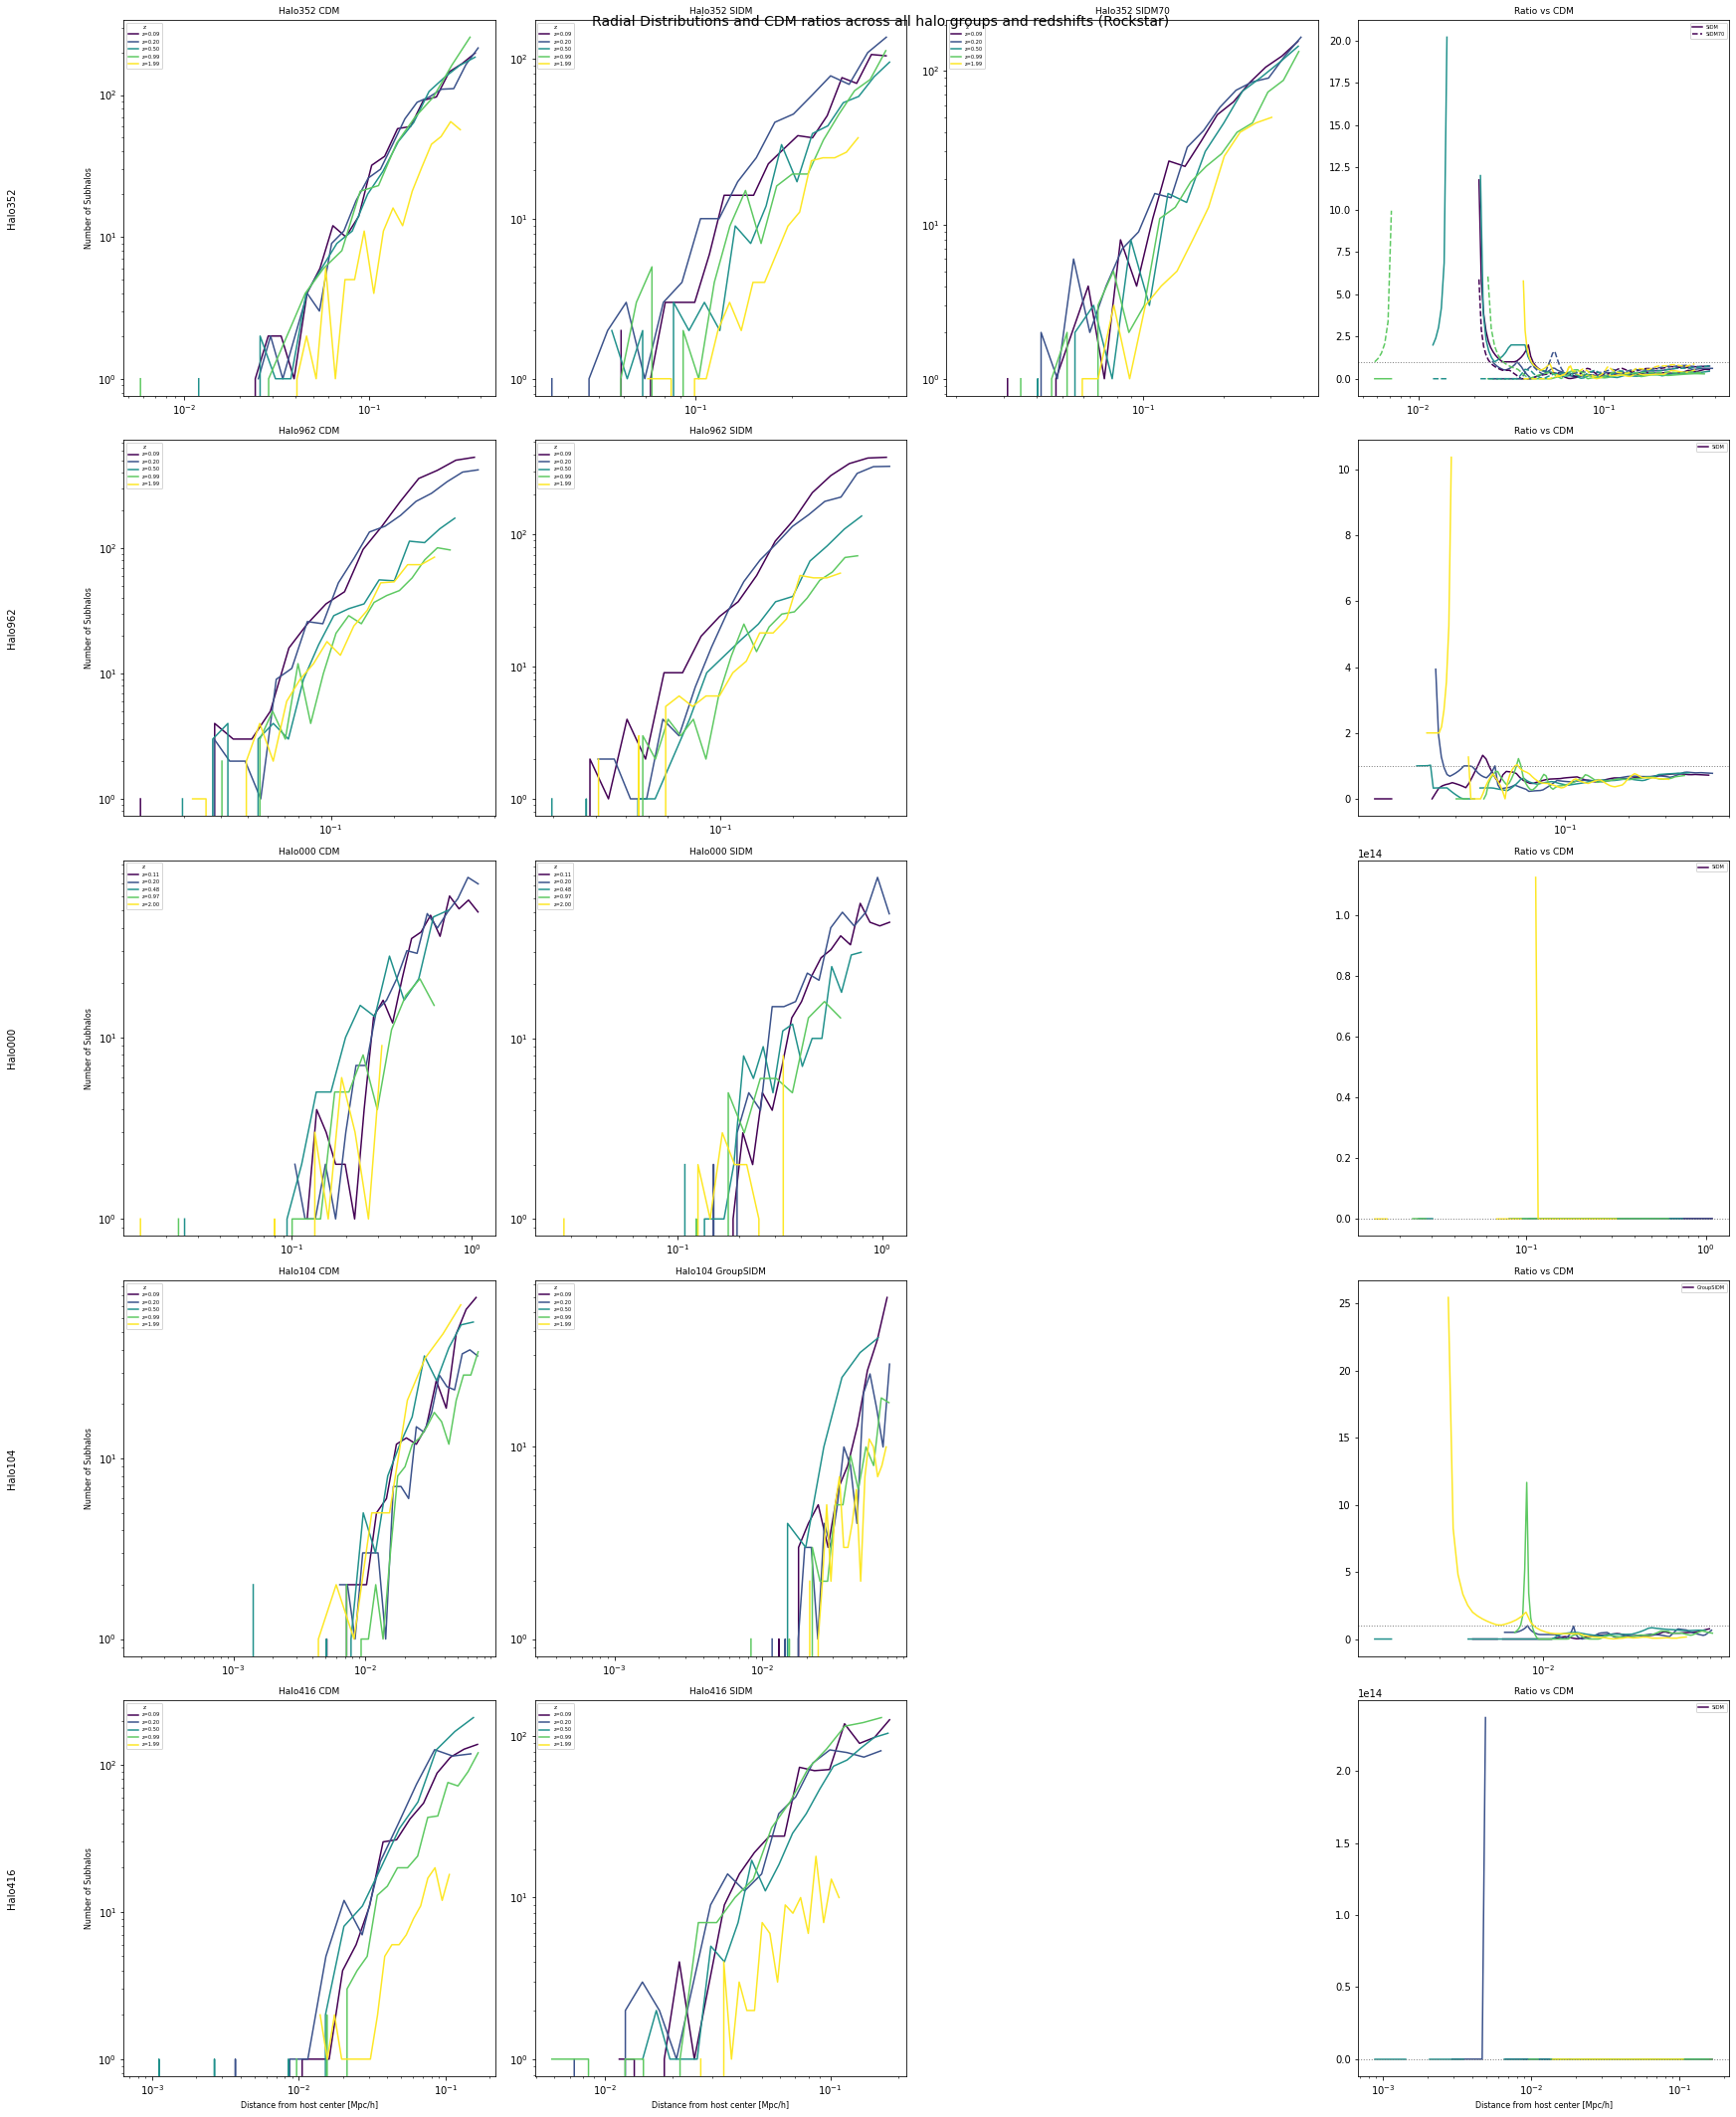

In [12]:
list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

n_groups = len(list_of_halos)
max_models = max(len(h) for h in list_of_halos)
ncols = max_models + 1  # +1 for the ratio panel

fig, axes = plt.subplots(n_groups, ncols, figsize=(6 * ncols, 6 * n_groups))
cmap = plt.get_cmap("viridis")
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

def radial_distribution(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    # print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )
    #print("Number of subhalos: " + str(n_subs))
    # print(np.max(n_subs))
    
    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    #assert n.sum() == n_subs, (
    #    f"Histogram lost points: sum(n)={n.sum()} but n_subs={n_subs}. "
    #    "Check for dists outside [bins[0], bins[-1]] due to float edge effects."
    #)

    #print("maximum number of subhalos: " + str(np.max(n)))
    return bins, n, host_rvir_mpc, n_subs


for igroup, ihalo in enumerate(list_of_halos):
    model_curves = {}  # label -> {target_z: (bins, N, actual_z)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, n, host_rvir_mpc, n_sub = radial_distribution(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, n, actual_z)

            color = cmap(i_z / max(len(list_of_z) - 1, 1))
            axes[igroup, i_model].plot(bins[:-1], n, color=color, label=f"z={actual_z:.2f}")

        axes[igroup, i_model].set_xscale('log')
        axes[igroup, i_model].set_yscale('log')
        axes[igroup, i_model].set_title(label, fontsize=9)
        if igroup == n_groups - 1:
            axes[igroup, i_model].set_xlabel(r"Distance from host center [Mpc/h]", fontsize=8) # "Distance from host center [Mpc/h]"
        if i_model == 0:
            axes[igroup, i_model].set_ylabel(r"Number of Subhalos", fontsize=8)
        axes[igroup, i_model].legend(fontsize=5, title="z", title_fontsize=6)

    # hide unused model columns for groups with fewer models
    for empty_col in range(len(ihalo), max_models):
        axes[igroup, empty_col].axis('off')

    # --- ratio panel (last column): all non-CDM models vs CDM ---
    ratio_ax = axes[igroup, -1]
    cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
    other_labels = [lbl for lbl in model_curves if lbl != cdm_label]

    if cdm_label is not None:
        for i_other, other_label in enumerate(other_labels):
            ls = linestyles[i_other % len(linestyles)]
            for i_z, target_z in enumerate(list_of_z):
                cdm_bins, cdm_N, actual_z = model_curves[cdm_label][target_z]
                other_bins, other_N, _ = model_curves[other_label][target_z]

                common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
                cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
                other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

                color = cmap(i_z / max(len(list_of_z) - 1, 1))
                label = f"{other_label.split(' ')[-1]}, z={actual_z:.2f}" if i_z == 0 else None
                ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
                              label=f"{other_label.split(' ')[-1]}" if i_z == 0 else None)

        ratio_ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ratio_ax.legend(fontsize=5)
    else:
        ratio_ax.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ratio_ax.transAxes, fontsize=8)

    ratio_ax.set_xscale('log')
    ratio_ax.set_title("Ratio vs CDM", fontsize=9)
    if igroup == n_groups - 1:
        ratio_ax.set_xlabel(r"Distance from host center [Mpc/h]", fontsize=8)

    # row label (halo group name) on the far left
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    axes[igroup, 0].annotate(group_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                              fontsize=10, rotation=90, ha='center', va='center')

fig.suptitle("Radial Distributions and CDM ratios across all halo groups and redshifts (Rockstar)", fontsize=14)
plt.tight_layout()
plt.show()

In [2]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re

'''GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists', 4e5]]
'''

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] # what happened to Halo004???


def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host




def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

In [3]:
def get_vmax_function(hlist_path, particle_mass, n_bins=30):
    """Load a catalog, find its largest host, and return Vmax function curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    vmax_subs = subs['vmax'][within_rvir & mass_ok]
    vmax_subs_half = subs['vmax'][within_half_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(vmax_subs_half.min()), np.log10(vmax_subs_half.max()), n_bins)
    n_half, _ = np.histogram(vmax_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host



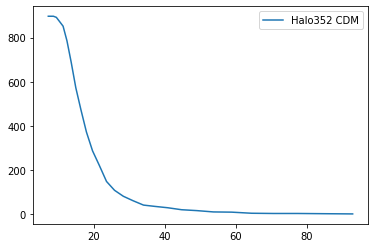

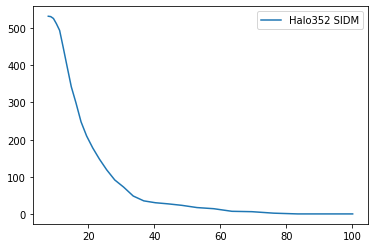

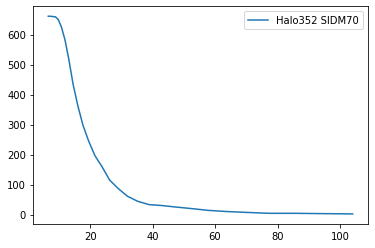

In [5]:
'''Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/hlist_1.00000.list', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists/hlist_1.00000.list', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists/hlist_1.00000.list',4e5]]

for label, hlist_path, particle_mass in Halo352: 
    bins, N, bins_half, N_half, host = get_vmax_function(hlist_path, particle_mass)
    plt.plot(bins[:-1],N, label = label)
    plt.legend()
    plt.show()'''

/scratch/rlai3/job_53330905/ipykernel_3960829/3153285891.py:135: RuntimeWarning: divide by zero encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
/scratch/rlai3/job_53330905/ipykernel_3960829/3153285891.py:135: RuntimeWarning: invalid value encountered in divide
  ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,


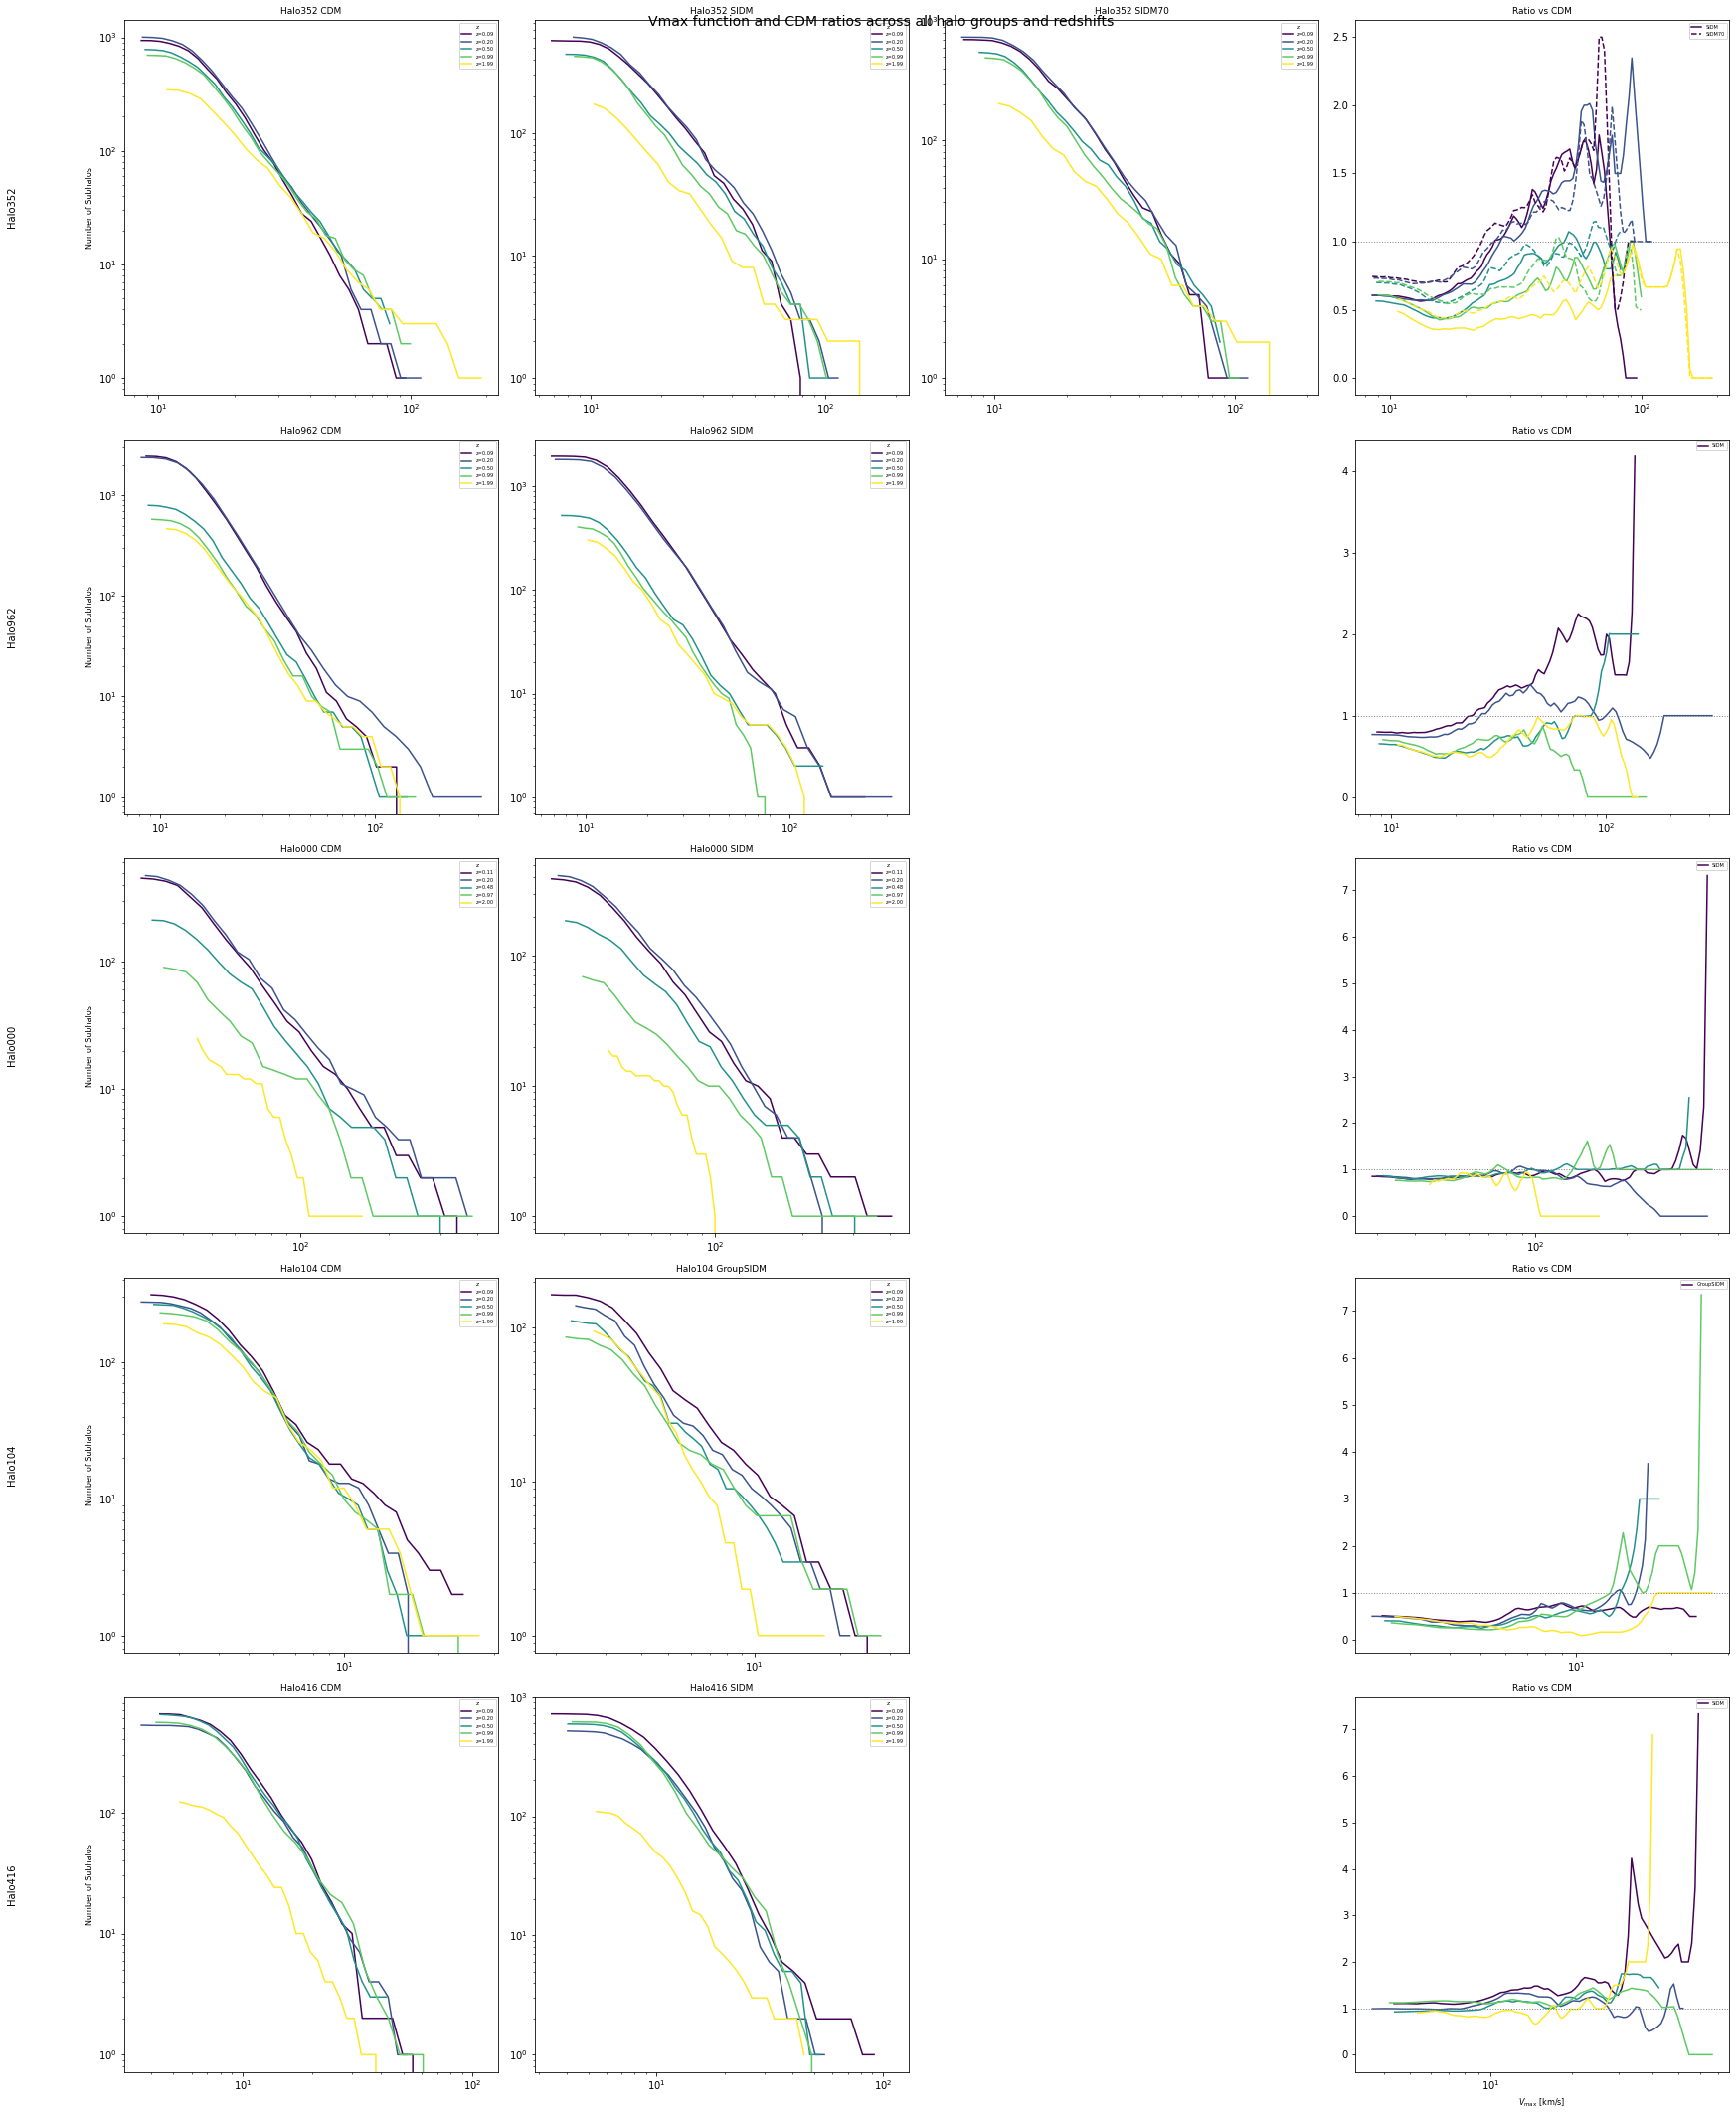

In [3]:

list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

n_groups = len(list_of_halos)
max_models = max(len(h) for h in list_of_halos)
ncols = max_models + 1  # +1 for the ratio panel

fig, axes = plt.subplots(n_groups, ncols, figsize=(6 * ncols, 6 * n_groups))
cmap = plt.get_cmap("viridis")
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

'''def radial_distribution(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    # print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )
    #print("Number of subhalos: " + str(n_subs))
    # print(np.max(n_subs))
    
    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    #assert n.sum() == n_subs, (
    #    f"Histogram lost points: sum(n)={n.sum()} but n_subs={n_subs}. "
    #    "Check for dists outside [bins[0], bins[-1]] due to float edge effects."
    #)

    #print("maximum number of subhalos: " + str(np.max(n)))
    return bins, n, host_rvir_mpc, n_subs
'''

def get_vmax_function(hlist_path, particle_mass, n_bins=30):
    """Load a catalog, find its largest host, and return Vmax function curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    vmax_subs = subs['vmax'][within_rvir & mass_ok]
    vmax_subs_half = subs['vmax'][within_half_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(vmax_subs_half.min()), np.log10(vmax_subs_half.max()), n_bins)
    n_half, _ = np.histogram(vmax_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host



for igroup, ihalo in enumerate(list_of_halos):
    model_curves = {}  # label -> {target_z: (bins, N, actual_z)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host= get_vmax_function(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, N, actual_z)

            color = cmap(i_z / max(len(list_of_z) - 1, 1))
            axes[igroup, i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

        axes[igroup, i_model].set_xscale('log')
        axes[igroup, i_model].set_yscale('log')
        axes[igroup, i_model].set_title(label, fontsize=9)
        if igroup == n_groups - 1:
            axes[igroup, i_model].set_xlabel(r"", fontsize=8) # "Distance from host center [Mpc/h]"
        if i_model == 0:
            axes[igroup, i_model].set_ylabel(r"Number of Subhalos", fontsize=8)
        axes[igroup, i_model].legend(fontsize=5, title="z", title_fontsize=6)

    # hide unused model columns for groups with fewer models
    for empty_col in range(len(ihalo), max_models):
        axes[igroup, empty_col].axis('off')

    # --- ratio panel (last column): all non-CDM models vs CDM ---
    ratio_ax = axes[igroup, -1]
    cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
    other_labels = [lbl for lbl in model_curves if lbl != cdm_label]

    if cdm_label is not None:
        for i_other, other_label in enumerate(other_labels):
            ls = linestyles[i_other % len(linestyles)]
            for i_z, target_z in enumerate(list_of_z):
                cdm_bins, cdm_N, actual_z = model_curves[cdm_label][target_z]
                other_bins, other_N, _ = model_curves[other_label][target_z]

                common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
                cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
                other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

                color = cmap(i_z / max(len(list_of_z) - 1, 1))
                label = f"{other_label.split(' ')[-1]}, z={actual_z:.2f}" if i_z == 0 else None
                ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
                              label=f"{other_label.split(' ')[-1]}" if i_z == 0 else None)

        ratio_ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ratio_ax.legend(fontsize=5)
    else:
        ratio_ax.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ratio_ax.transAxes, fontsize=8)

    ratio_ax.set_xscale('log')
    ratio_ax.set_title("Ratio vs CDM", fontsize=9)
    if igroup == n_groups - 1:
        ratio_ax.set_xlabel(r"$V_{\rm max}$ [km/s]", fontsize=8)

    # row label (halo group name) on the far left
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    axes[igroup, 0].annotate(group_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                              fontsize=10, rotation=90, ha='center', va='center')

fig.suptitle("Vmax function and CDM ratios across all halo groups and redshifts", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# mass accretion history using rockstar

#for each halo, iterate through all snapshots

'''

list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

n_groups = len(list_of_halos)
max_models = max(len(h) for h in list_of_halos)
ncols = max_models + 1  # +1 for the ratio panel

fig, axes = plt.subplots(n_groups, ncols, figsize=(6 * ncols, 6 * n_groups))
cmap = plt.get_cmap("viridis")
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

def radial_distribution(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    # print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )
    #print("Number of subhalos: " + str(n_subs))
    # print(np.max(n_subs))
    
    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    #assert n.sum() == n_subs, (
    #    f"Histogram lost points: sum(n)={n.sum()} but n_subs={n_subs}. "
    #    "Check for dists outside [bins[0], bins[-1]] due to float edge effects."
    #)

    #print("maximum number of subhalos: " + str(np.max(n)))
    return bins, n, host_rvir_mpc, n_subs




for igroup, ihalo in enumerate(list_of_halos):
    model_curves = {}  # label -> {target_z: (bins, N, actual_z)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, n, host_rvir_mpc, n_sub = radial_distribution(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, n, actual_z)


'''


list_of_halos = [Halo352] # Halo962, Halo000, Halo104, Halo416]
Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

def MAH_rockstar(halo_path, particle_mass):
    h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
    mass_cut = 300 * particle_mass
    h_hubble = 0.7
    
    for model in halo:
            z_list = []
            host_mass_list = []
    
        for label, hlist_path, particle_mass in model:
            
    
            for snapshot in halo_path: 
        # find corresponding z, append to z_list
        
        # h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
        # mass = h['mvir']
        # host_mass_list.append(mass)
        
    plt.plot(z_list, host_mass_list)
    
    

    
    
    

In [ ]:
def get_mah(hlist_dir, particle_mass):
    """Track the largest host halo (at the lowest-z snapshot) back through
    earlier snapshots and return its mass vs redshift."""
    h_hubble = 0.7
    mass_cut = 300 * particle_mass

    lookup = build_redshift_lookup(hlist_dir)  # sorted low-z -> high-z

    z_list = []
    host_mass_list = []
    cur = None

    for z, hlist_path in lookup:
        h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
        hosts = h[h['upid'] == -1]
        hosts = hosts[hosts['mvir'] > mass_cut]
        if len(hosts) == 0:
            continue

        if cur is None:
            cur = hosts[hosts['mvir'].argmax()]
        else:
            dists = getDistance(cur, hosts)
            cur = hosts[dists.argmin()]

        z_list.append(z)
        host_mass_list.append(cur['mvir'] / h_hubble)

    return np.array(z_list), np.array(host_mass_list)


#for halo_group in list_of_halos:
halo_group = Halo352
plt.figure()
for label, hlist_dir, particle_mass in halo_group:
    z_arr, mvir_arr = get_mah(hlist_dir, particle_mass)
    plt.plot(z_arr, mvir_arr, label=label)

plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$M_{vir}$ [$M_\odot$]')
plt.legend()
plt.title(halo_group[0][0].split()[0])  # e.g. "Halo352"
plt.show()

In [6]:

# first import symfind_addconcerto
from symlib_addconcerto import get_host_directory

# def MAH_symfind(hlist_path, particle_mass)

ModuleNotFoundError: No module named 'symlib_addconcerto'

In [4]:
'''import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance


import numpy as np
import matplotlib.pyplot as plt
import os
import re'''

sys.path.append('Users/roxannelai/Downloads/symphony-main/symlib_addconcerto')
import symlib_addconcerto

In [5]:
import sys
import scipy
import numpy as np
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
import symlib_addconcerto

In [9]:
pip install scipy --user

     |████████████████████████████████| 34.5 MB 19.6 MB/s eta 0:00:01
You should consider upgrading via the '/cm/shared/apps/spack/0.17.3/cpu/b/opt/spack/linux-rocky8-zen2/gcc-10.2.0/python-3.8.12-7zdjza7xxfccxr5syuaomd2fpvp2x35i/bin/python3.8 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install symlib --user

     |████████████████████████████████| 56 kB 578 kB/s  eta 0:00:01
     |████████████████████████████████| 236 kB 43.6 MB/s eta 0:00:01
You should consider upgrading via the '/cm/shared/apps/spack/0.17.3/cpu/b/opt/spack/linux-rocky8-zen2/gcc-10.2.0/python-3.8.12-7zdjza7xxfccxr5syuaomd2fpvp2x35i/bin/python3.8 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [15]:
Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists/hlist_1.00000.list', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists/hlist_1.00000.list', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists/hlist_1.00000.list',4e5]]

symlib_addconcerto.get_host_directory('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/','/cdm_8k/rockstar/hlists/hlist_1.00000.list')


TypeError: get_host_directory() missing 1 required positional argument: 'halo_name'

In [7]:
sim_dir_example = symlib_addconcerto.get_host_directory(
    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar',  # base_dir
    'Halo352',   # suite_name slot
    'cdm_8k'     # halo_name slot
)

scale_factors = symlib_addconcerto.scale_factors(sim_dir_example)
n_snaps = len(scale_factors)

ValueError: The halo in /expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k does not belong to a recognized suite.

In [14]:
# try out symfind on the concerto 

import symlib_addconcerto

In [2]:
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
suite = "ConcertoGroupHR"

total_hosts = symlib_addconcerto.n_hosts(suite)

# Load scale factors (same across halos in suite)
sim_dir_example = symlib_addconcerto.get_host_directory(base_dir, suite, 0)
scale_factors = symlib_addconcerto.scale_factors(sim_dir_example)
n_snaps = len(scale_factors)

ValueError: Unrecognized suite name, 'ConcertoGroupHR'

In [16]:
import importlib
import symlib_addconcerto
importlib.reload(symlib_addconcerto)

<module 'symlib_addconcerto' from '/expanse/lustre/projects/ddp469/rlai3/symlib_addconcerto/__init__.py'>

In [1]:
import importlib
import symlib_addconcerto.util
importlib.reload(symlib_addconcerto.util)
import symlib_addconcerto
importlib.reload(symlib_addconcerto)

<module 'symlib_addconcerto' from '/expanse/lustre/projects/ddp469/rlai3/symlib_addconcerto/__init__.py'>

In [3]:
import symlib_addconcerto
print('ConcertoGroupHR' in symlib_addconcerto.DEFAULT_HALO_NAMES)
print(symlib_addconcerto.__file__)

AttributeError: module 'symlib_addconcerto' has no attribute 'DEFAULT_HALO_NAMES'

In [7]:
import symlib_addconcerto1.util
print('ConcertoGroupHR' in symlib_addconcerto.util.DEFAULT_HALO_NAMES)
print(symlib_addconcerto1.util.__file__)

False
/expanse/lustre/projects/ddp469/rlai3/symlib_addconcerto1/util.py


In [8]:
import importlib
import symlib_addconcerto1.util
importlib.reload(symlib_addconcerto1.util)
print('ConcertoGroupHR' in symlib_addconcerto1.util.DEFAULT_HALO_NAMES)

True


In [10]:
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
suite = "ConcertoGroupHR"

total_hosts = symlib_addconcerto1.n_hosts(suite)

# Load scale factors (same across halos in suite)
sim_dir_example = symlib_addconcerto1.get_host_directory(base_dir, suite, 0)
scale_factors = symlib_addconcerto1.scale_factors(sim_dir_example)
n_snaps = len(scale_factors)
print(n_snaps)

236


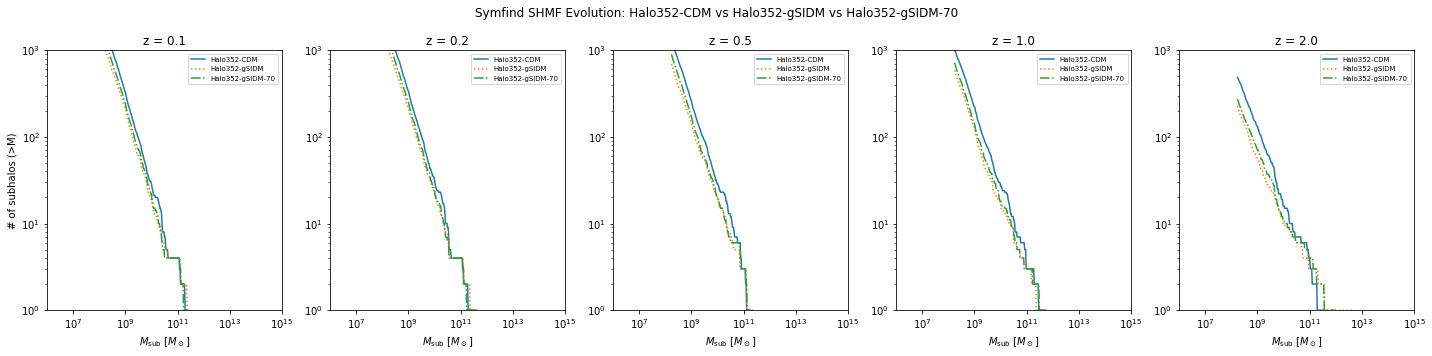

In [14]:
import numpy as np
import matplotlib.pyplot as plt
#import sys
#sys.path.append('/Users/roxannelai/Downloads/symphony-main')
#import symlib_addconcerto

#base_dir = "/Users/roxannelai/SymphonySuitesData"
#suite = "ConcertoGroupHR"
# halo_name_list = ["Halo352SIDM", "Halo352SIDM70", "Halo352CDM"]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
suite = "ConcertoGroupHR"
halo_list = ["Halo352-CDM","Halo352-gSIDM","Halo352-gSIDM-70"]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
linestyle_list = ['solid', 'dotted', 'dashdot']

def shmf_overlay_redshifts(base_dir, suite, halo_list, redshifts):
    fig, ax = plt.subplots(1, len(redshifts), figsize=(4 * len(redshifts), 5))

    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    for z_index, target_z in enumerate(redshifts):
        for i_halo, halo_name in enumerate(halo_list):
            linestyle = linestyle_list[i_halo % len(linestyle_list)]

            sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
            scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
            target_a = 1 / (1 + target_z)
            snap_index = np.argmin(np.abs(scale_factors - target_a))

            h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
            r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
            host_rvir = h["rvir"][0, snap_index]
            ok = h["ok"][:, snap_index] & (r < host_rvir)

            sub_masses = hist["mpeak"][ok][1:]
            sub_masses = sub_masses[sub_masses > mass_cut]

            n_vir, _ = np.histogram(sub_masses, bins=bins)
            N_vir = np.cumsum(n_vir[::-1])[::-1]

            ax[z_index].plot(left_bins, N_vir, ls=linestyle, label=halo_name)

        ax[z_index].set_xlim(1e6, 1e15)
        ax[z_index].set_ylim(1e0, 1e3)
        ax[z_index].set_xscale("log")
        ax[z_index].set_yscale("log")
        ax[z_index].set_title(f"z = {target_z}")
        ax[z_index].set_xlabel(r"$M_{\rm sub}$ [$M_\odot$]")
        if z_index == 0:
            ax[z_index].set_ylabel("# of subhalos (>M)")
        ax[z_index].legend(fontsize=7)

    fig.suptitle("Symfind SHMF Evolution: " + " vs ".join(halo_list))
    plt.tight_layout()
    plt.show()

shmf_overlay_redshifts(base_dir, suite, halo_list, redshifts)

In [5]:
# Create Symfind subhalo mass function and Rockstar subhalo mass function

import symlib_addconcerto1
    
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir
    

    
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



# First try for halo352 CDM
rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
    Halo352[1][1], Halo352[1][2], target_z=redshifts[0]
)
halo_name = halo_list[0]
symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, redshifts[0])

fig = plt.figure()
plt.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
plt.plot(symfind_bins, symfind_N, label="Symfind")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
plt.ylabel(r'$N(>M)$')
plt.title(f"Halo352 SHMF Rockstar vs Symfind z={target_z}")
plt.legend()
plt.show()



NameError: name 'halo_list' is not defined

In [2]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re

'''GroupHalo352 = [
    ['Group Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Group Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists', 4e5]]
'''

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 


def get_shmf(hlist_path, particle_mass):
    """Load a catalog, find its largest host, and return SHMF curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    # particle_mass = hlist_path[2]
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)

    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs_half = subs['mpeak'][within_half_rvir] / h_hubble

    mass_subs = mass_subs[mass_subs > mass_cut]
    mass_subs_half = mass_subs_half[mass_subs_half > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(mass_subs_half.min()), np.log10(mass_subs_half.max()), 30)
    n_half, _ = np.histogram(mass_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host


import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re

list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

In [3]:
import symlib_addconcerto1

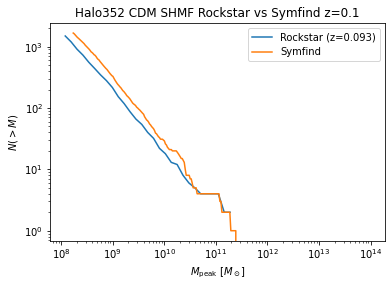

In [6]:
import symlib_addconcerto1
    
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)


    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]
    

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir
    

    
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np
import matplotlib.pyplot as plt
import os
import re

Halo352 = [
    ['Halo352 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]


list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
suite = "ConcertoGroupHR"
halo_list = ["Halo352-CDM","Halo352-gSIDM","Halo352-gSIDM-70"]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
linestyle_list = ['solid', 'dotted', 'dashdot']

target_z=redshifts[0]

# First try for halo352 CDM
rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
    Halo352[1][1], Halo352[1][2], target_z
)
halo_name = halo_list[0]
symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, redshifts[0])

fig = plt.figure()
plt.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
plt.plot(symfind_bins, symfind_N, label="Symfind")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
plt.ylabel(r'$N(>M)$')
plt.title(f"Halo352 CDM SHMF Rockstar vs Symfind z={target_z}")
plt.legend()
plt.show()


In [3]:
# loop it for all halo352 models

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
suite_list = ["ConcertoGroupHR"]
# halo_list = ["Halo352-CDM","Halo352-gSIDM","Halo352-gSIDM-70"] #used for symfind
halo_list = [ #used for rockstar
    ['Halo352-CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ['Halo352-gSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ['Halo352-SIDM-70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]


redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
linestyle_list = ['solid', 'dotted', 'dashdot']

target_z=redshifts[0]

for i_suite, suite_name in enumerate(suite_list):
    
    for i in range(0,3):

    rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
    Halo352[i][1], Halo352[i][2], target_z
    )
    halo_name = halo_list[i]
    symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, redshifts[0])

    fig = plt.figure()
    plt.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
    plt.plot(symfind_bins, symfind_N, label="Symfind")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
    plt.ylabel(r'$N(>M)$')
    plt.title(f"{halo_name} SHMF Rockstar vs Symfind z={target_z}")
    plt.legend()
    plt.show()



IndentationError: expected an indented block (1151706287.py, line 21)

In [7]:
suite_list = ["ConcertoGroupHR", "ConcertoLClusterHR", "ConcertoLMCHR", "ConcertoMW004HR","ConcertoMW416HR"]

suite_list_dictionary= {
    "ConcertoGroupHR":["Halo352-CDM","Halo352-gSIDM","Halo352-gSIDM-70", "Halo962-CDM", "Halo962-gSIDM-70"],
    "ConcertoLClusterHR":["Halo000-CDM", "Halo000-gSIDM"],
    "ConcertoLMCHR": ["Halo104-CDM", "Halo104-gSIDM"],
    "ConcertoMW004HR": ["Halo004-CDM","Halo004-gSIDM", "Halo004-mwSIDM"],
    "ConcertoMW416HR": ["Halo416-CDM","Halo416-mwSIDM"]
}
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
models_list = suite_list_dictionary.get(suite_list[i])

for i_halo in halo_list:
    models_list = suite_list_dictionary.get(halo_list[i])
    for i_model in models_list:
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, redshifts[0])
        plt.plot(symfind_bins,symfind_N)
        plt.show()
        




Halo352 = [
    ["ConcertoGroupHR","Halo352-CDM", '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5],
    ["ConcertoGroupHR","Halo352-gSIDM", '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
    ["ConcertoGroupHR","Halo352-gSIDM-70, '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]]

Halo000=[
    ['Halo000 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',2.7e7],
    ['Halo000 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists',2.7e7]]

Halo104 = [
    ['Halo104 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',6.3e3],
    ['Halo104 GroupSIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists',6.3e3]]

Halo416 = [
    ['Halo416 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',5e4],
    ['Halo416 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',5e4]]
    #['Halo416 SIDM70', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_70_16k/rockstar/hlists',5e4]]

Halo962=[
    ['Halo962 CDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',4e5],
    ['Halo962 SIDM', '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',4e5]]

list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
linestyle_list = ['solid', 'dotted', 'dashdot']


     
target_z=redshifts[0]
     


for ihalo in list_of_halos:
     
     symfind_suite = ihalo[0]
     symfind_halo=ihalo[1]
     hlist_path=ihalo[2]
    
    
    for imodel in ihalo:

        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
        Halo352[i][1], Halo352[i][2], target_z
        )
        halo_name = halo_list[i]
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, redshifts[0])

        fig = plt.figure()
        plt.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        plt.plot(symfind_bins, symfind_N, label="Symfind")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        plt.ylabel(r'$N(>M)$')
        plt.title(f"{halo_name} SHMF Rockstar vs Symfind z={target_z}")
        plt.legend()
        plt.show()



TypeError: 'NoneType' object is not iterable

In [2]:
halo_list = [
    # suite,              symfind_halo_name,   rockstar_hlist_dir,                                                                          particle_mass
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
    ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
    ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
    ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
    ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
    ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
    ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]
]]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_list:
    fig,ax = plt.subplot(1,3)
    for i,(suite, halo_name, hlist_dir, particle_mass) in enumerate(halo_models):
        ax = ax[i]
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        fig,ax = plt.subplot(1,3)
        ax = ax.flatten()
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF Rockstar vs Symfind, z={target_z}")
    plt.legend()
    plt.show()

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 432x288 with 0 Axes>

In [8]:
print(type(halo_list))
print(len(halo_list))
print(halo_list[0])

<class 'list'>
3
Halo352-CDM


ValueError: not enough values to unpack (expected 4, got 1)

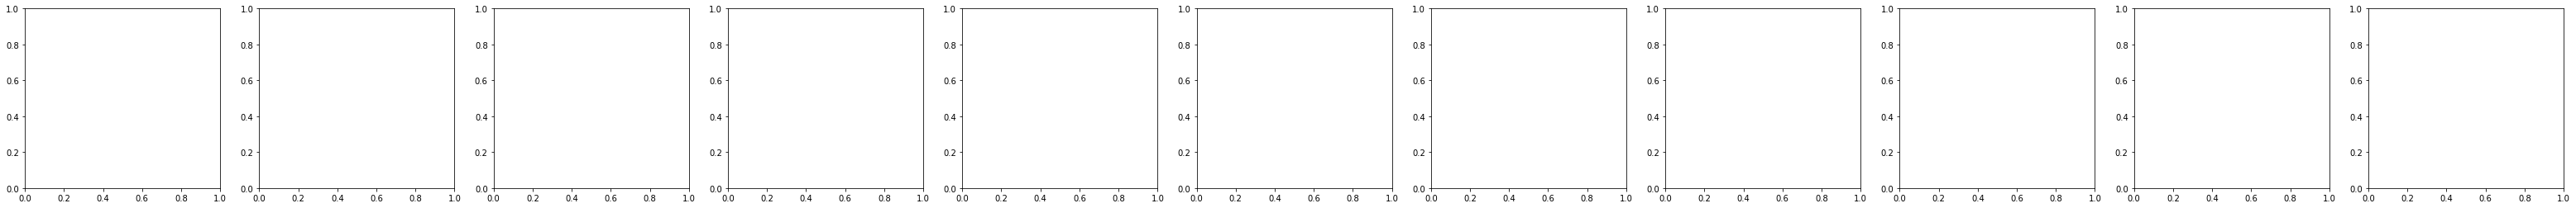

In [7]:
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_list:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]  # so indexing axes[i] works even for a single-variant group

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name}, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

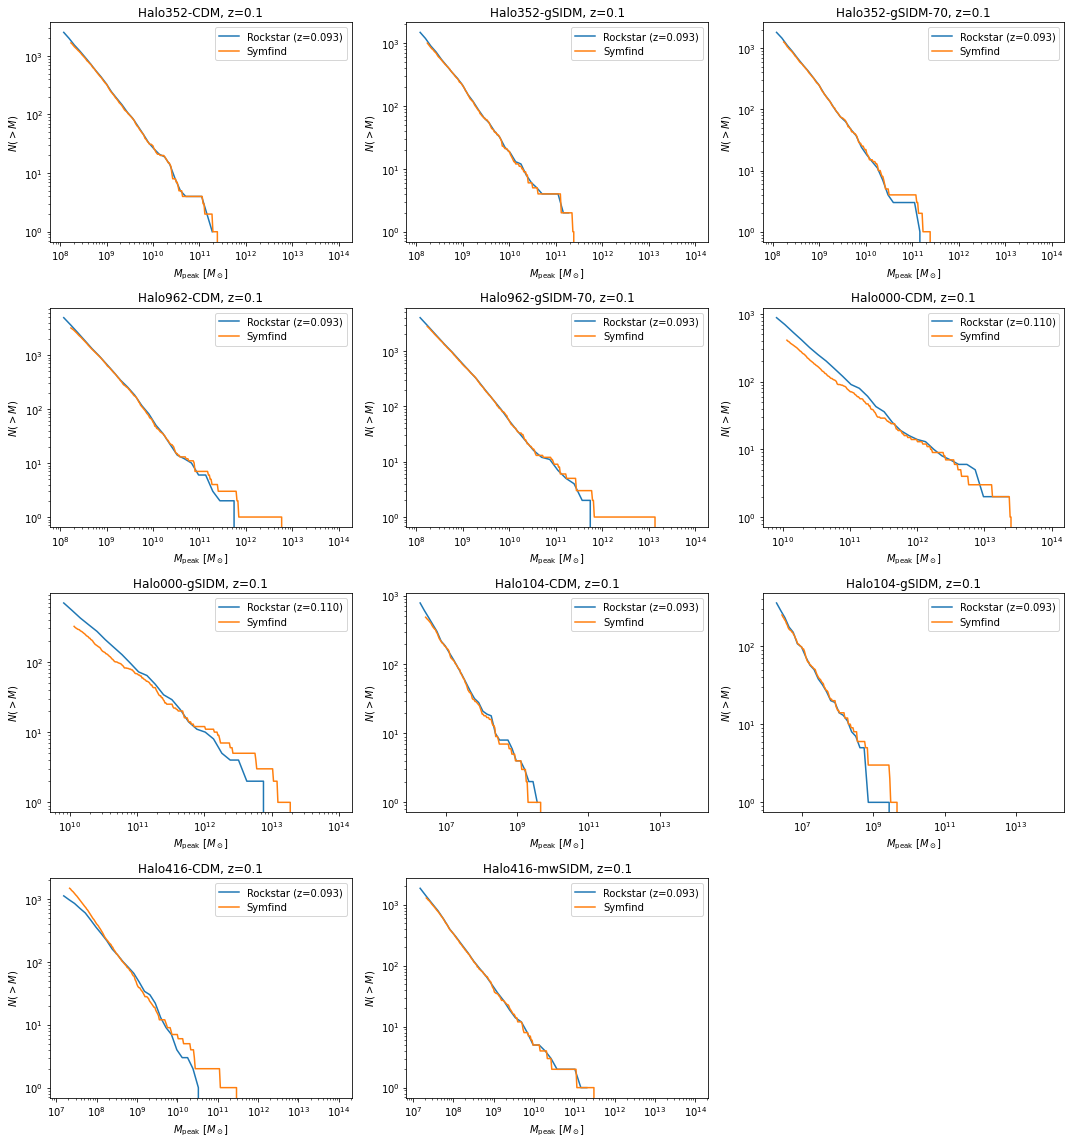

In [6]:
import math

n = len(halo_models)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo_models):
    fig,ax = 
    rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
        hlist_dir, particle_mass, target_z
    )
    symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

    ax = axes[i]
    ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
    ax.plot(symfind_bins, symfind_N, label="Symfind")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
    ax.set_ylabel(r'$N(>M)$')
    ax.set_title(f"{halo_name}, z={target_z}")
    ax.legend()

# hide any unused subplot slots (e.g. 11 halos in a 4x3 grid leaves 1 empty)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

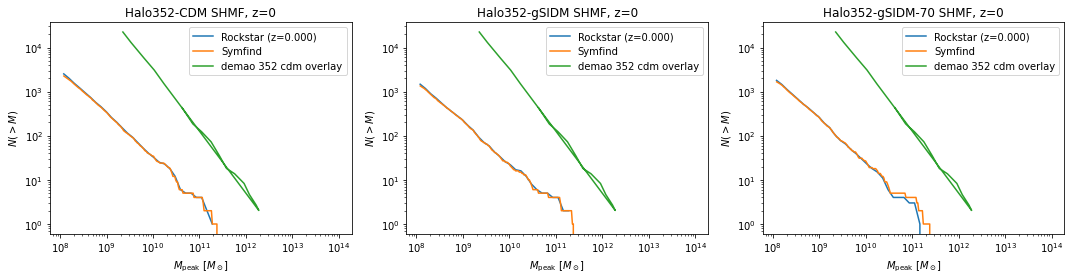

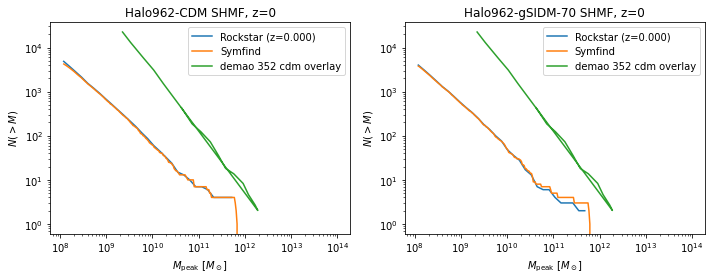

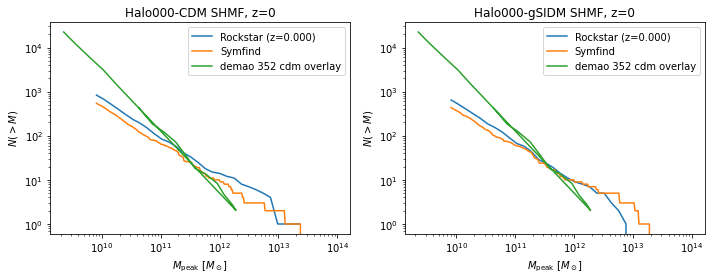

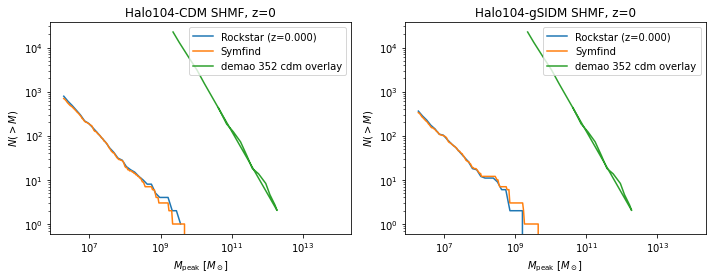

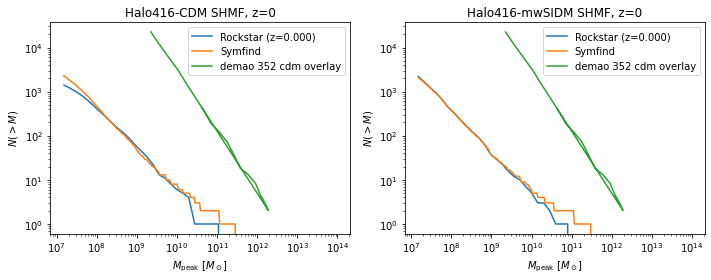

In [7]:

    
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)


    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]
    

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir
    


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0,0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.plot(demao_bins,demao_n,label="demao 352 cdm overlay")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [6]:
demao_bins = [42389633841.91460,
    72230877738.4055,
    111599602000.1460,
    178187458850.49400,
    270070154601.38900,
    382864774153.4910,
    572493519689.437,
    914208405518.1360,
    1191970698615.3400,
    1662943402672.2200,
    1898968350141.690,
    17223757856.680300,
    10621774559.675900,
    6436469407.97493,
    3356600765.207850,
    2249140436.499000]

demao_n=[431.5972725081580,
    185.51815089151300,
    123.07014291326100,
    72.91207848564620,
    35.05302468700780,
    18.160614975386000,
    13.747900338422100,
    8.30047892062671,
    4.633263413116780,
    2.688510965025470,
    2.0277468406551700,
    1514.9756542554200,
    3089.289839604240,
    5729.429824115510,
    13058.159814376300,
    22483.099546911800]


In [ ]:

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'



def symfind_vmax(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)


    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    max_velocities = sub_masses["mvir"]
    
    n_vir, _ = np.histogram(max_velocities, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir

def rockstar_vmax(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    vmax_subs = mass_subs['vmax'][within_rvir & mass_ok]
    vmax_subs_half = mass_subs['vmax'][within_half_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    #bins_half = np.logspace(np.log10(vmax_subs_half.min()), np.log10(vmax_subs_half.max()), n_bins)
    #n_half, _ = np.histogram(vmax_subs_half, bins=bins_half)
    #N_half = np.cumsum(n_half[::-1])[::-1]


    return bins[:-1], N, host, z_found


    
for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

IsADirectoryError: [Errno 21] Is a directory: '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

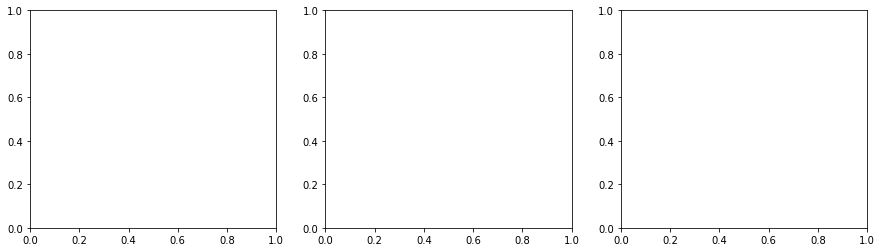

In [12]:
# yay now do velocity mass functions
'''
def rockstar_vmax_function(hlist_path, particle_mass, n_bins=30):
    """Load a catalog, find its largest host, and return Vmax function curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    vmax_subs = subs['vmax'][within_rvir & mass_ok]
    vmax_subs_half = subs['vmax'][within_half_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(vmax_subs_half.min()), np.log10(vmax_subs_half.max()), n_bins)
    n_half, _ = np.histogram(vmax_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins[:-1], N, bins_half, N_half, host


def symfind_vmax_function(base_dir,suite,halo_name,target_z): #how to make velocity mass function w symfind??
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)

    # apply filters for subhalos
    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]
    
    # find max velocities of remaining subhalos
    max_velocities = sub_masses["mvir"]
    
    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir'''
    
for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax_function(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_vmax_function(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

In [2]:
import symlib_addconcerto1


def symfind_vmax(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)
    # ok = h[:, snap_index] & (r < host_rvir)
    
    #ok = r < host_rvir
    #keep = ok
    #keep[0] = False  # drop the host itself

    keep = ok #& (hist["mpeak"] > mass_cut)
    keep[0] = False  # drop the host itself

    v_subs = h["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(v_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N


def rockstar_vmax(hlist_dir, particle_mass, target_z, n_bins=300):
    """Load the snapshot closest to target_z, find the largest host, and
    return a cumulative Vmax function for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_ok = subs['mpeak'] / h_hubble > mass_cut
    vmax_subs = subs['vmax'][within_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

target_z = 0

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, target_z)
        print(np.min(symfind_bins))
        # print(symfind_N)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
        ax.set_ylabel(r'$N(>V_{\rm max})$')
        ax.set_title(f"{halo_name} V_max Function, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

2.1099999138365244
1.2799999880303712
1.4500000340328938


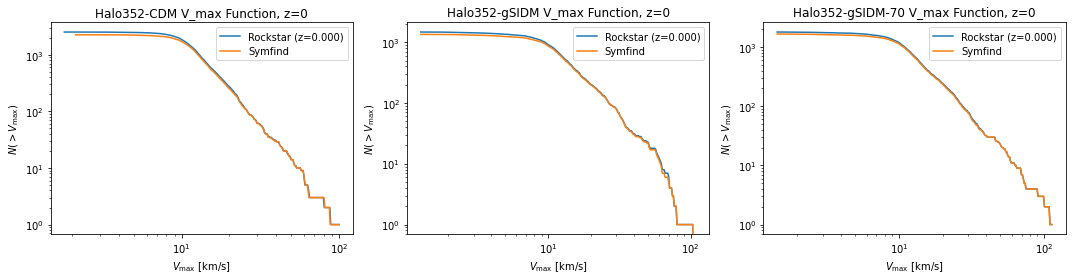

2.1800000898158016
1.5399999708435128


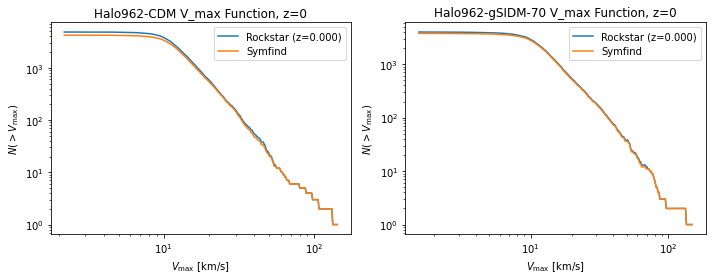

7.23000021077751
6.899999633797009


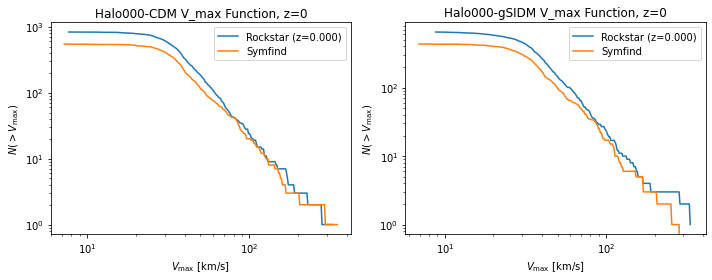

0.739999993299195
0.4999999835123525


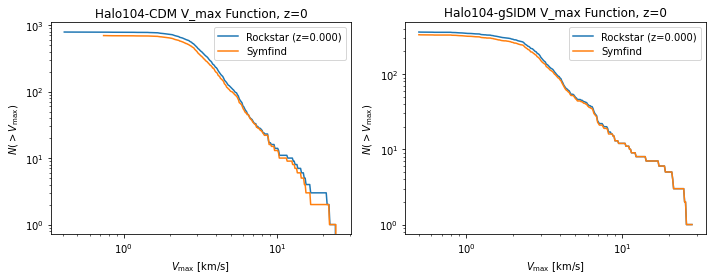

1.2300000254697323
0.7300000148300613


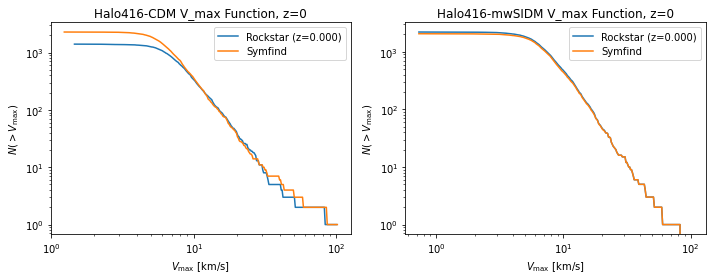

In [19]:

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

target_z = 0

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, target_z)
        print(np.min(symfind_bins))
        # print(symfind_N)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
        ax.set_ylabel(r'$N(>V_{\rm max})$')
        ax.set_title(f"{halo_name} V_max Function, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [5]:

def rockstar_radial_dist(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    # print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    return bins, n, host_rvir_mpc, n_subs   
                        

                        
def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    sub_rvirs = h["rvir"][:,snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)
    # ok = h[:, snap_index] & (r < host_rvir)
    
    ok = r < host_rvir
    keep = ok
    keep[0] = False  # drop the host itself

    # keep = ok #& (hist["mpeak"] > mass_cut)
    # keep[0] = False  # drop the host itself

    v_subs = h["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")
                         
    #plot subs_rvirs

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(subs_rvirs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N

    
    
    
    
    
    
    
    

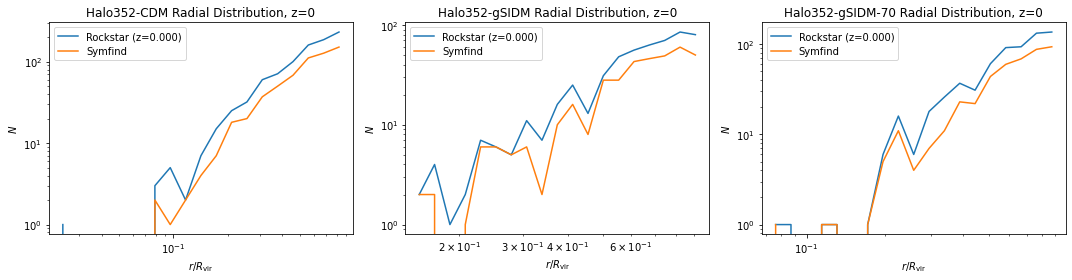

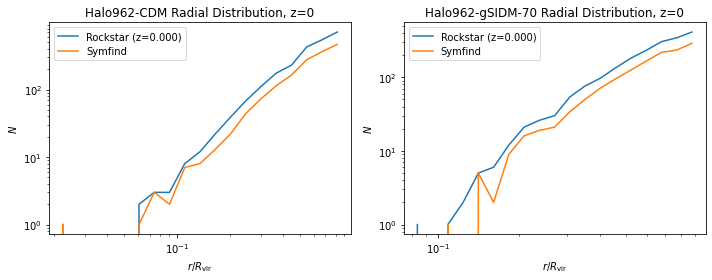

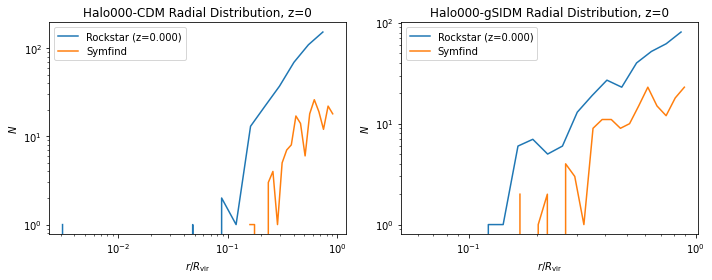

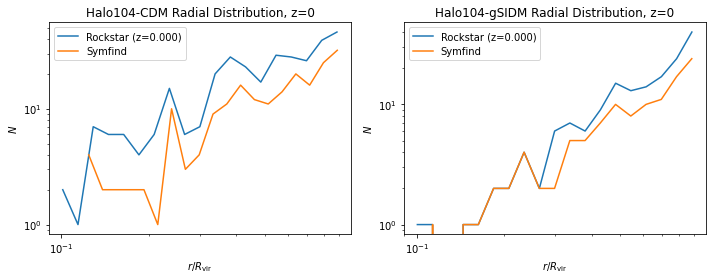

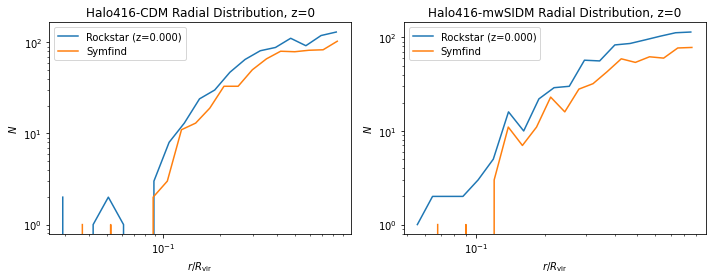

In [4]:
import symlib_addconcerto1

def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found    
        
    
    #bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    #n, _ = np.histogram(r_over_rvir, bins=bins)
    #return bins, n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)

    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))  # physical kpc, host-centered
    host_rvir = h["rvir"][0, snap_index]                     # physical kpc, same snapshot

    ok = h["ok"][:, snap_index]
    mass_ok = h["mvir"][:, snap_index] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

target_z = 0
'''
for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_radial_dist(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_radial_dist(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$r / R_{\rm vir}$')
        ax.set_ylabel(r'$N$')
        ax.set_title(f"{halo_name} Radial Distribution, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()
'''    
    
for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host_rvir, rockstar_nsubs, rockstar_z = rockstar_radial_dist(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
            base_dir, suite, halo_name, target_z
        )

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$r / R_{\rm vir}$')
        ax.set_ylabel(r'$N$')
        ax.set_title(f"{halo_name} Radial Distribution, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()




In [7]:
plt.plot(rockstar_bins[:-1], rockstar_n, label="Rockstar")
plt.plot(symfind_bins[:-1], symfind_n, label="Symfind")
plt.xlabel(r'$r / R_{\rm vir}$')
plt.ylabel('N')

NameError: name 'rockstar_n' is not defined

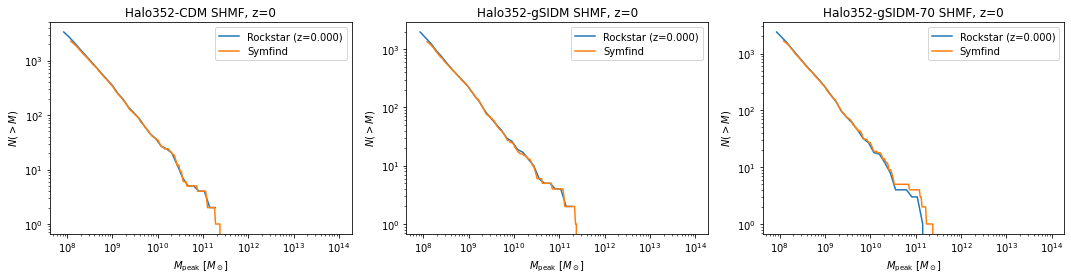

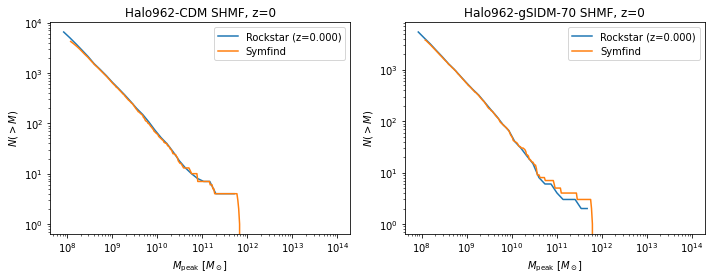

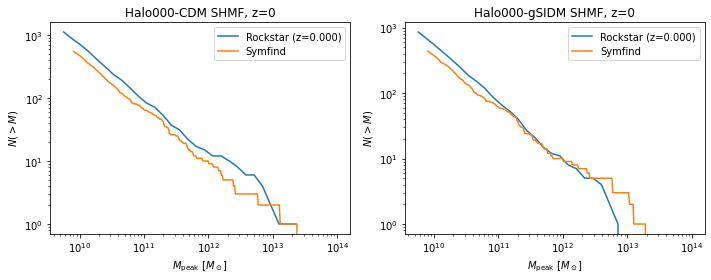

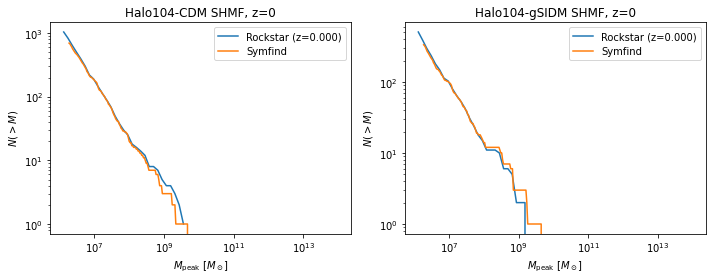

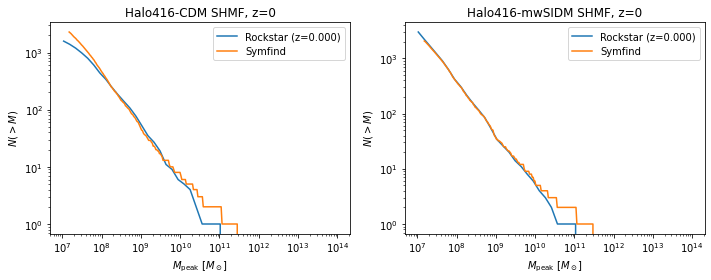

In [5]:
# figure out why my shmf isnt matching demao
# demao's figures have groupcdm shifted down a little but here it's the same line almost

def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)


    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]
    

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir
    


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      2.81981e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     2.81981e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  2.81981e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      2.81981e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  2.81981e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    (2.7e7) *0.7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', (2.7e7)*0.7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     (6.3e3) *0.7],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', (6.3e3) *0.7]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      (5e4) *0.7],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    (5e4) *0.7]],
]

'''
parameter_table["ConcertoGroupHR"]["mp"] = 2.81981e5
parameter_table["ConcertoLClusterHR"]["mp"] = 2.7e7 *0.7
parameter_table["ConcertoLMCHR"]["mp"] = 6.3e3 *0.7
parameter_table["ConcertoMW004HR"]["mp"] = 5e4 *0.7
parameter_table["ConcertoMW416HR"]["mp"] = 5e4*0.7
'''



base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0,0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        # ax.plot(demao_bins,demao_n,label="demao 352 cdm overlay")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [6]:
for suite, halo_name, hlist_dir, particle_mass in [row for group in halo_groups for row in group]:
    params = symlib_addconcerto1.simulation_parameters(suite)
    symfind_mp = params["mp"] / params["h100"]
    print(f"{halo_name}: your particle_mass={particle_mass:.4g}  symlib mp={symfind_mp:.4g}  ratio={particle_mass/symfind_mp:.3f}")

Halo352-CDM: your particle_mass=2.82e+05  symlib mp=4.028e+05  ratio=0.700
Halo352-gSIDM: your particle_mass=2.82e+05  symlib mp=4.028e+05  ratio=0.700
Halo352-gSIDM-70: your particle_mass=2.82e+05  symlib mp=4.028e+05  ratio=0.700
Halo962-CDM: your particle_mass=2.82e+05  symlib mp=4.028e+05  ratio=0.700
Halo962-gSIDM-70: your particle_mass=2.82e+05  symlib mp=4.028e+05  ratio=0.700
Halo000-CDM: your particle_mass=1.89e+07  symlib mp=2.7e+07  ratio=0.700
Halo000-gSIDM: your particle_mass=1.89e+07  symlib mp=2.7e+07  ratio=0.700
Halo104-CDM: your particle_mass=4410  symlib mp=6300  ratio=0.700
Halo104-gSIDM: your particle_mass=4410  symlib mp=6300  ratio=0.700
Halo416-CDM: your particle_mass=3.5e+04  symlib mp=5e+04  ratio=0.700
Halo416-mwSIDM: your particle_mass=3.5e+04  symlib mp=5e+04  ratio=0.700


In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

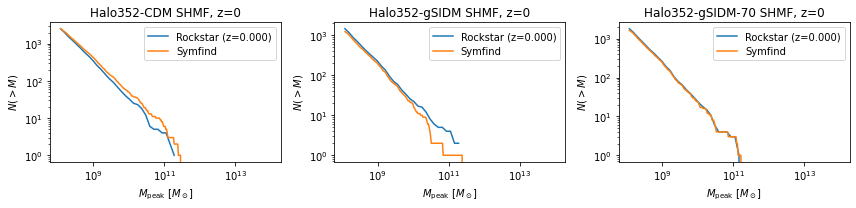

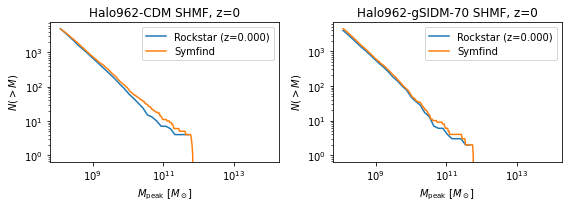

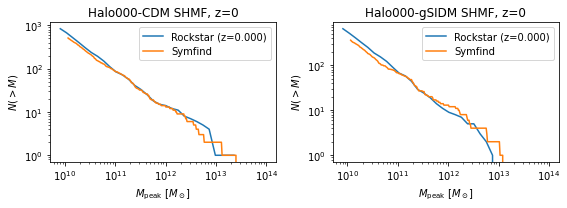

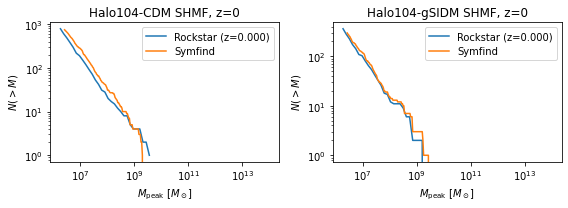

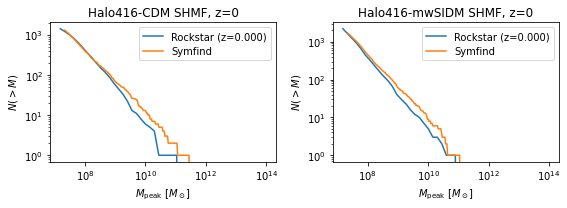

In [2]:
# figure out why my shmf isnt matching demao
# demao's figures have groupcdm shifted down a little but here it's the same line almost
'''
def symfind_shmf(base_dir, suite, halo_name, target_z, particle_mass):
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    host_rvir = h["rvir"][0, snap_index]
    ok = h["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]
    return bins[:-1], N_vir
'''

# symfind code dr nadler gave me 
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5], #2.81981e5
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
]

'''
parameter_table["ConcertoGroupHR"]["mp"] = 2.81981e5
parameter_table["ConcertoLClusterHR"]["mp"] = 2.7e7 *0.7
parameter_table["ConcertoLMCHR"]["mp"] = 6.3e3 *0.7
parameter_table["ConcertoMW004HR"]["mp"] = 5e4 *0.7
parameter_table["ConcertoMW416HR"]["mp"] = 5e4*0.7
'''



base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0,0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 3))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        # symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        # ax.plot(demao_bins,demao_n,label="demao 352 cdm overlay")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [3]:
for suite, halo_name, hlist_dir, particle_mass in [row for group in halo_groups for row in group]:
    params = symlib_addconcerto1.simulation_parameters(suite)
    symfind_mp = params["mp"] / params["h100"]
    print(f"{halo_name}: your particle_mass={particle_mass:.4g}  symlib mp={symfind_mp:.4g}  ratio={particle_mass/symfind_mp:.3f}")

Halo352-CDM: your particle_mass=4e+05  symlib mp=4.028e+05  ratio=0.993
Halo352-gSIDM: your particle_mass=4e+05  symlib mp=4.028e+05  ratio=0.993
Halo352-gSIDM-70: your particle_mass=4e+05  symlib mp=4.028e+05  ratio=0.993
Halo962-CDM: your particle_mass=4e+05  symlib mp=4.028e+05  ratio=0.993
Halo962-gSIDM-70: your particle_mass=4e+05  symlib mp=4.028e+05  ratio=0.993
Halo000-CDM: your particle_mass=2.7e+07  symlib mp=2.7e+07  ratio=1.000
Halo000-gSIDM: your particle_mass=2.7e+07  symlib mp=2.7e+07  ratio=1.000
Halo104-CDM: your particle_mass=6300  symlib mp=6300  ratio=1.000
Halo104-gSIDM: your particle_mass=6300  symlib mp=6300  ratio=1.000
Halo416-CDM: your particle_mass=5e+04  symlib mp=5e+04  ratio=1.000
Halo416-mwSIDM: your particle_mass=5e+04  symlib mp=5e+04  ratio=1.000


In [5]:
h, hist = symlib_addconcerto1.read_subhalos(
    symlib_addconcerto1.get_host_directory(base_dir, "ConcertoGroupHR", "Halo352-CDM")
)
print("n subhalos tracked by symfind:", h.shape[0])

hlist_lookup = build_redshift_lookup('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists')
_, path0 = find_closest_hlist(0, hlist_lookup)
hr = readHlist(path0, ['id','mvir','upid'])
print("n halos (all, incl. host) in rockstar hlist:", len(hr))
print("n host-only rockstar halos:", (hr['upid']==-1).sum())

n subhalos tracked by symfind: 4776
n halos (all, incl. host) in rockstar hlist: 468953
n host-only rockstar halos: 393632


In [6]:
suite, halo_name, hlist_dir, particle_mass = halo_groups[0][0]  # Halo352-CDM

lookup = build_redshift_lookup(hlist_dir)
z_found, hlist_path = find_closest_hlist(0, lookup)
h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'x', 'y', 'z'])
host_mask_all = h['upid'] == -1
largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
rockstar_host = h[h['id'] == largest_halo_id][0]
print("rockstar host: mvir=%.3e  pos=(%.3f, %.3f, %.3f)" %
      (rockstar_host['mvir'], rockstar_host['x'], rockstar_host['y'], rockstar_host['z']))

sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
sh, shist = symlib_addconcerto1.read_subhalos(sim_dir)
print("symfind host rvir (kpc):", sh['rvir'][0, -1])  # snap_index for z=0, last snapshot typically

rockstar host: mvir=8.958e+12  pos=(62.065, 61.194, 64.043)
symfind host rvir (kpc): 609.5008


In [7]:
suite, halo_name, hlist_dir, particle_mass = halo_groups[0][0]  # Halo352-CDM
target_z = 0

# --- rockstar raw population ---
lookup = build_redshift_lookup(hlist_dir)
z_found, hlist_path = find_closest_hlist(target_z, lookup)
h_r = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
host_mask_all = h_r['upid'] == -1
largest_id = h_r['id'][host_mask_all][h_r['mvir'][host_mask_all].argmax()]
rhost = h_r[h_r['id'] == largest_id][0]
rsubs = h_r[h_r['upid'] == largest_id]
rdists = getDistance(rhost, rsubs)
r_within = rdists < (rhost['rvir']/1000.0)
r_masses = rsubs['mpeak'][r_within] / 0.7
r_masses_cut = r_masses[r_masses > 300*particle_mass]

print("ROCKSTAR: n total subs (upid==host):", len(rsubs))
print("ROCKSTAR: n within rvir:", r_within.sum())
print("ROCKSTAR: n within rvir + mass cut:", len(r_masses_cut))
print("ROCKSTAR: mass min/max:", r_masses_cut.min(), r_masses_cut.max())

# --- symfind raw population ---
sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
sf = symlib_addconcerto1.scale_factors(sim_dir)
snap_index = np.argmin(np.abs(sf - 1/(1+target_z)))
h_s, hist_s = symlib_addconcerto1.read_subhalos(sim_dir)
r_s = np.sqrt(np.sum(h_s["x"][:, snap_index]**2, axis=1))
host_rvir = h_s["rvir"][0, snap_index]
ok = h_s["ok"][:, snap_index]

print("SYMFIND: n total tracked:", h_s.shape[0])
print("SYMFIND: n ok at this snapshot:", ok.sum(), "  frac:", ok.sum()/h_s.shape[0])
s_within = ok & (r_s < host_rvir)
s_within[0] = False
print("SYMFIND: n ok + within rvir:", s_within.sum())
s_masses = hist_s["mpeak"][s_within]
s_masses_cut = s_masses[s_masses > 300*particle_mass]
print("SYMFIND: n ok + within rvir + mass cut:", len(s_masses_cut))
print("SYMFIND: mass min/max:", s_masses_cut.min(), s_masses_cut.max())


ROCKSTAR: n total subs (upid==host): 15561
ROCKSTAR: n within rvir: 15561
ROCKSTAR: n within rvir + mass cut: 2528
ROCKSTAR: mass min/max: 120042856.0 245857140000.0
SYMFIND: n total tracked: 4776
SYMFIND: n ok at this snapshot: 3234   frac: 0.6771356783919598
SYMFIND: n ok + within rvir: 2261
SYMFIND: n ok + within rvir + mass cut: 2261
SYMFIND: mass min/max: 121257144.0 245857140000.0


/scratch/rlai3/job_53578301/ipykernel_1900525/2482321351.py:12: RuntimeWarning: divide by zero encountered in divide
  ratio = f_s(np.log10(common_mass)) / f_r(np.log10(common_mass))


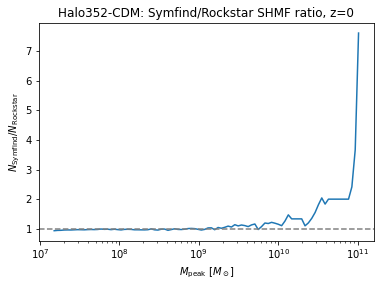

In [9]:
# match Symfind and Rockstar onto a common mass grid, then take the ratio
from scipy.interpolate import interp1d

f_r = interp1d(np.log10(rockstar_bins), rockstar_N, bounds_error=False, fill_value=np.nan)
f_s = interp1d(np.log10(symfind_bins), symfind_N, bounds_error=False, fill_value=np.nan)

common_mass = np.logspace(
    max(np.log10(rockstar_bins.min()), np.log10(symfind_bins.min())),
    min(np.log10(rockstar_bins.max()), np.log10(symfind_bins.max())),
    100
)
ratio = f_s(np.log10(common_mass)) / f_r(np.log10(common_mass))

plt.plot(common_mass, ratio)
plt.axhline(1.0, color='gray', linestyle='--')
plt.xscale('log')
plt.xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
plt.ylabel(r'$N_{\rm Symfind} / N_{\rm Rockstar}$')
plt.title('Halo352-CDM: Symfind/Rockstar SHMF ratio, z=0')
plt.show()

In [2]:
print(scale_factors[-1], np.argmin(np.abs(scale_factors - 1.0)), len(scale_factors)-1)

NameError: name 'scale_factors' is not defined

In [3]:
# ok what if i just did mass accretion histories right now

import symlib_addconcerto1 # added concerto group and halo352 into util, renamed it 

# base_dir = "/Users/roxannelai/SymphonySuitesData"
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
# suite_list = ["ConcertoGroup","SymphonyLCluster", "SymphonyMilkyWay", "SymphonyLMC", "SymphonyGroup", "SymphonyCluster", "MWest"]
# color_list = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:purple", "tab:pink","black"]
'''
halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5], #2.81981e5
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists', 4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists', 2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists', 6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists', 5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists', 5e4]]
]
'''


halo = ["ConcertoGroupHR", "Halo352-CDM", '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5]

for ih, model, hlist_path, particle_mass in halo: 

    # Create plot
    fig, ax = plt.subplots(figsize=(8,6))

    for suite, color in zip(suite_list, color_list):
        total_hosts = symlib_addconcerto.n_hosts(suite)

        # Load scale factors (same across halos in suite)
        sim_dir_example = symlib_addconcerto1.get_host_directory(base_dir, model, 0)
        scale_factors = symlib_addconcerto.scale_factors(sim_dir_example)
        n_snaps = len(scale_factors)

        # Preload all host data
        host_data = []
        for j in range(total_hosts):
            sim_dir = symlib_addconcerto.get_host_directory(base_dir, model, j)
            r, _ = symlib_addconcerto.read_rockstar(sim_dir)
            host_data.append(r[0])  # only host, not subhalos

        n_snaps_common = min(len(r_host) for r_host in host_data)
        a_common = scale_factors[:n_snaps_common]
    
        # Plot individual hosts (semi-transparent)
        for r_host in host_data:
            n_snaps_host = len(r_host)
            masses = [r_host[snap]["m"] if r_host[snap]["ok"] else np.nan for snap in range(n_snaps_common)]
            ax.plot(a_common, masses, color=color, alpha=0.15, linewidth=1)

        # Compute and plot average host mass
        average_masses = []
    
    
        for snap in range(n_snaps_common):
            valid_masses = [r_host[snap]["m"] for r_host in host_data if r_host[snap]["ok"]]
            # avg = np.mean(valid_masses) if len(valid_masses) > 0 else np.nan
            average_masses.append(np.mean(valid_masses) if valid_masses else np.nan)

        ax.plot(a_common, average_masses, color=color, linewidth=2.5, label=suite)

    # Final plot settings
    ax.set_yscale("log")
    ax.set_xlabel("Scale Factor a(t)")
    ax.set_ylabel("Host Halo Mass [Msun]")
    ax.set_title("Host Mass Accretion Histories by Suite (Symfind)")
    ax.legend(title="Suite")
    plt.tight_layout()
    plt.show()

ValueError: too many values to unpack (expected 4)

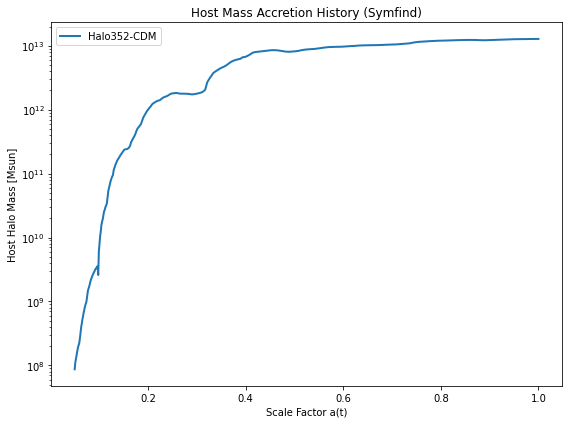

In [7]:
import symlib_addconcerto1



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5], #2.81981e5
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists', 4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists', 2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists', 6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists', 5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists', 5e4]]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

for ihalo in halo_group:
    
    for halo in ihalo:
        suite, halo_name, hlist_path, particle_mass = halo
    
    
halo = ["ConcertoGroupHR", "Halo352-CDM", '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5]
suite, halo_name, hlist_path, particle_mass = halo

sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
scale_factors = symlib_addconcerto1.scale_factors(sim_dir)

h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
host_mvir = h["mvir"][0]   # index 0 = host, all snapshots
host_ok = h["ok"][0]

masses = np.where(host_ok, host_mvir, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(scale_factors, masses, linewidth=2, label=halo_name)
ax.set_yscale("log")
ax.set_xlabel("Scale Factor a(t)")
ax.set_ylabel("Host Halo Mass [Msun]")
ax.set_title("Host Mass Accretion History (Symfind)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
import symlib_addconcerto1

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

# halo = ["ConcertoGroupHR", "Halo352-CDM", '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5]



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', 4e5], #2.81981e5
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists', 4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists', 4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists', 2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists', 6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists', 5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists', 5e4]]

    
for halo_list in halo_groups:
    fig, ax = plt.subplots(figsize=(8,6))

    for model in halo_list:
        # fig, ax = plt.subplots(figsize=(8,6))
        suite, halo_name, hlist_path, particle_mass = model
        sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
        scale_factors = symlib_addconcerto1.scale_factors(sim_dir)

        h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
        host_mvir = h["mvir"][0]   # index 0 = host, all snapshots
        host_ok = h["ok"][0]

        masses = np.where(host_ok, host_mvir, np.nan)

        # fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(scale_factors, masses, linewidth=2, label=halo_name, alpha=0.55)
        ax.set_yscale("log")
        ax.set_xlabel("Scale Factor a(t)")
        ax.set_ylabel("Host Halo Mass [Msun]")
        ax.set_title("Host Mass Accretion History (Symfind)")
    plt.legend()
    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax (2720781263.py, line 23)

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

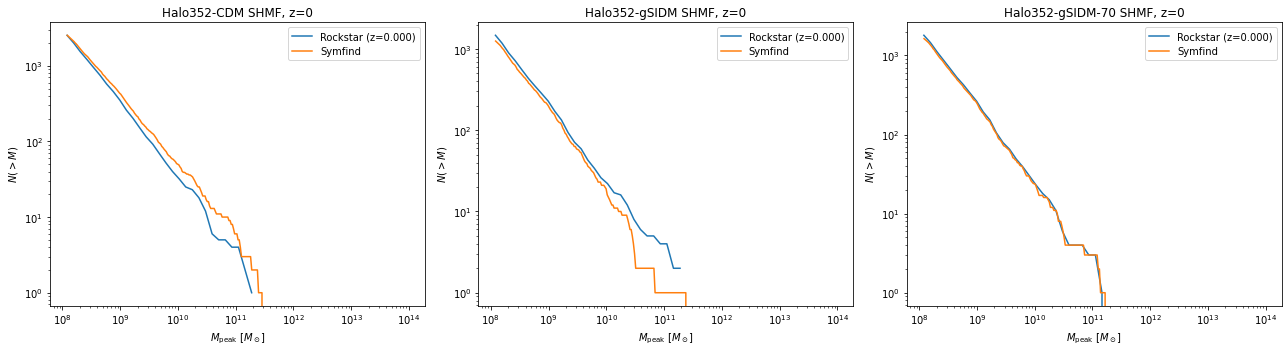

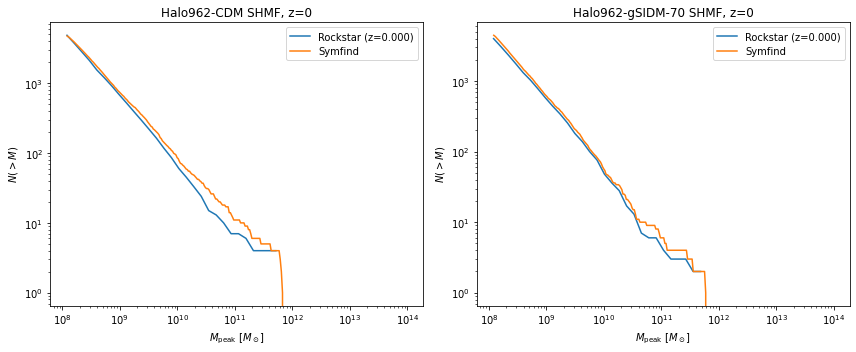

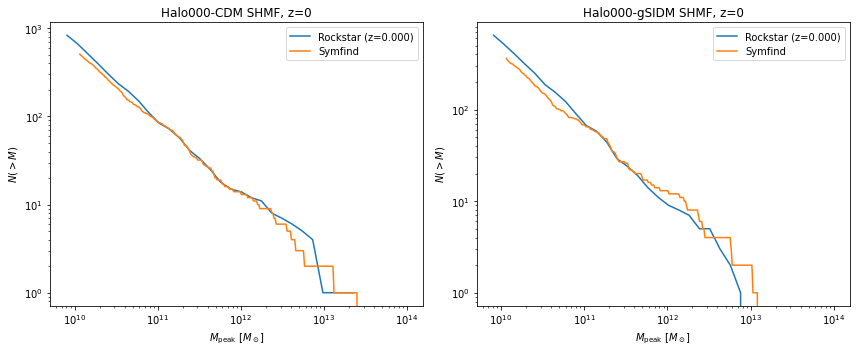

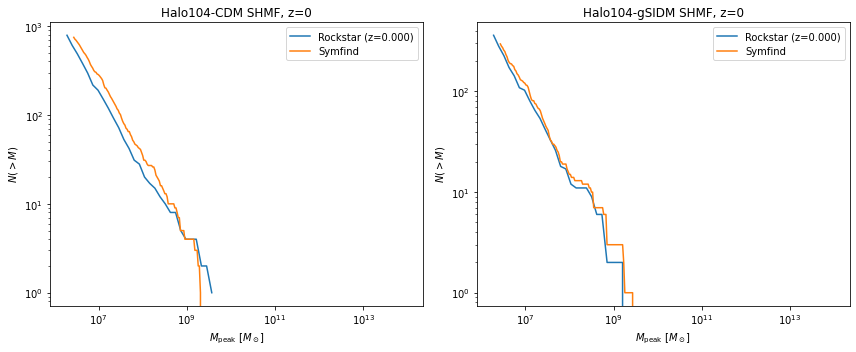

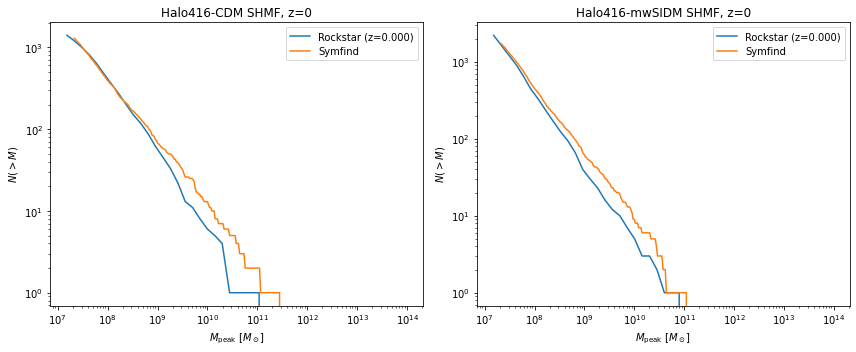

In [5]:
# symfind code dr nadler gave me 
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5], #2.81981e5
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7 ]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
]

'''
parameter_table["ConcertoGroupHR"]["mp"] = 2.81981e5
parameter_table["ConcertoLClusterHR"]["mp"] = 2.7e7 *0.7
parameter_table["ConcertoLMCHR"]["mp"] = 6.3e3 *0.7
parameter_table["ConcertoMW004HR"]["mp"] = 5e4 *0.7
parameter_table["ConcertoMW416HR"]["mp"] = 5e4*0.7
'''



base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
redshifts = [0,0.1, 0.2, 0.5, 1.0, 2.0]
target_z = redshifts[0]

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
            hlist_dir, particle_mass, target_z
        )
        # symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)
        symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, target_z)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        # ax.plot(demao_bins,demao_n,label="demao 352 cdm overlay")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
        ax.set_ylabel(r'$N(>M)$')
        ax.set_title(f"{halo_name} SHMF, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

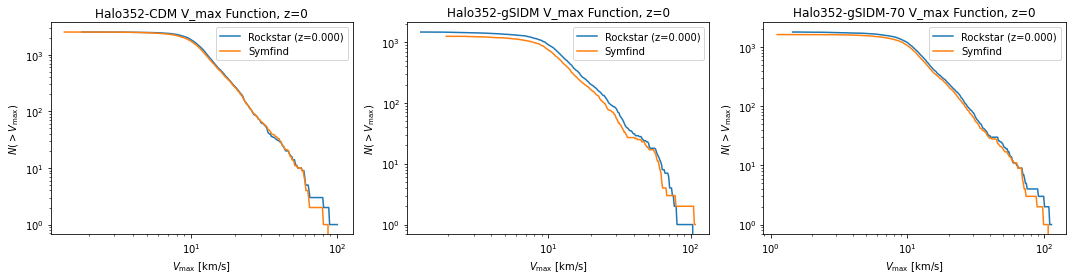

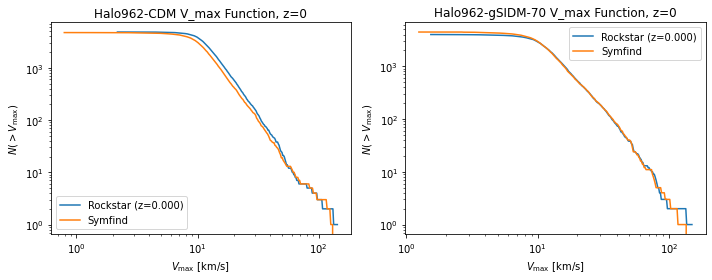

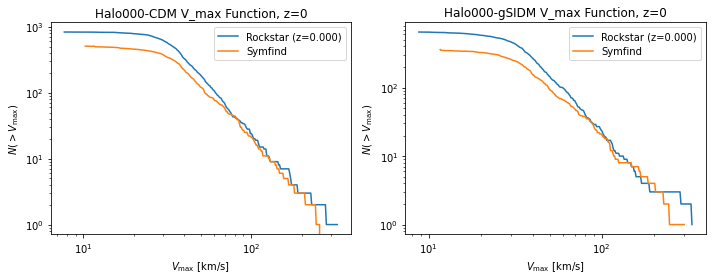

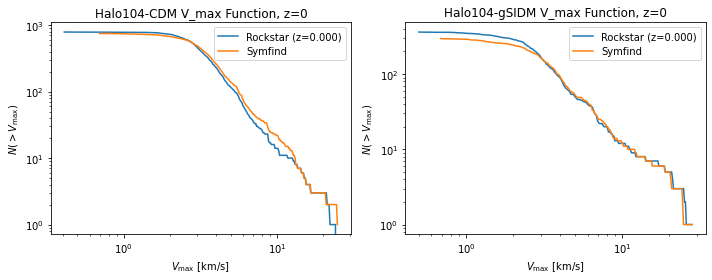

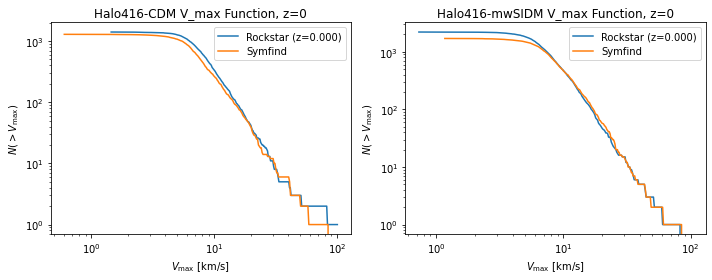

In [4]:
import symlib_addconcerto1
'''
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir


def symfind_vmax(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")
    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))
    ok = h["ok"][:, snap_index] & (r < host_rvir)
    # ok = h[:, snap_index] & (r < host_rvir)
    
    #ok = r < host_rvir
    #keep = ok
    #keep[0] = False  # drop the host itself

    keep = ok & (sf_hist["mpeak"] > mass_cut)
    keep[0] = False  # drop the host itself

    v_subs = h["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(v_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N
'''

def symfind_vmax(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    keep = ok & (sf_hist["mpeak"] > mass_cut)
    keep[0] = False  # drop the host itself

    v_subs = sf["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(v_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N



def rockstar_vmax(hlist_dir, particle_mass, target_z, n_bins=300):
    """Load the snapshot closest to target_z, find the largest host, and
    return a cumulative Vmax function for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_ok = subs['mpeak'] / h_hubble > mass_cut
    vmax_subs = subs['vmax'][within_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

target_z = 0

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
            hlist_dir, particle_mass, target_z
        )
        symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, target_z)
        # print(np.min(symfind_bins))
        # print(symfind_N)

        ax = axes[i]
        ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={rockstar_z:.3f})")
        ax.plot(symfind_bins, symfind_N, label="Symfind")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
        ax.set_ylabel(r'$N(>V_{\rm max})$')
        ax.set_title(f"{halo_name} V_max Function, z={target_z}")
        ax.legend()

    plt.tight_layout()
    plt.show()

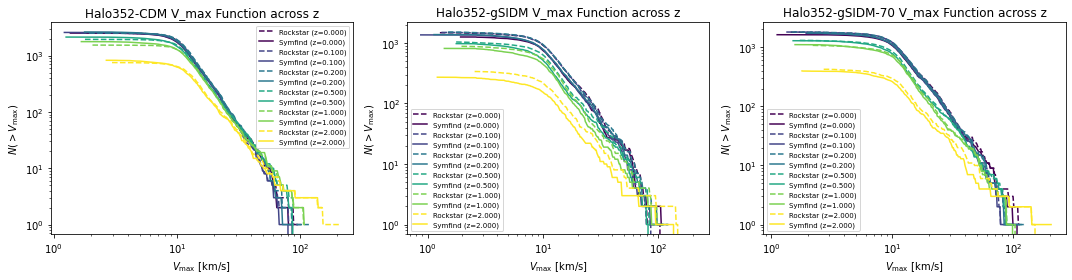

In [3]:
# for halo 352, do across redshifts

def symfind_vmax(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    keep = ok & (sf_hist["mpeak"] > mass_cut)
    keep[0] = False  # drop the host itself

    v_subs = sf["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(v_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N



def rockstar_vmax(hlist_dir, particle_mass, target_z, n_bins=300):
    """Load the snapshot closest to target_z, find the largest host, and
    return a cumulative Vmax function for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_ok = subs['mpeak'] / h_hubble > mass_cut
    vmax_subs = subs['vmax'][within_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]]] #,
'''
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]
'''
base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
list_of_z = [0,0.1, 0.2, 0.5, 1.0, 2.0]

# fig, ax = plt.subplots(1,3)
'''
for halo in halo_groups:
    
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        
        for iz in list_of_z: 
            rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, iz)
            # print(np.min(symfind_bins))
            # print(symfind_N)

            ax = axes[i]
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})",ls = "dashed")
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})")
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
            ax.set_ylabel(r'$N(>V_{\rm max})$')
            ax.set_title(f"{halo_name} V_max Function across z")
            ax.legend()

        plt.tight_layout()
        plt.show()


for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz in list_of_z:
            rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, iz)

            ax = axes[i]
            color = cmap(iz / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})",color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
            ax.set_ylabel(r'$N(>V_{\rm max})$')
            ax.set_title(f"{halo_name} V_max Function across z")

        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

'''


cmap = plt.cm.viridis

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, iz)

            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
            ax.set_ylabel(r'$N(>V_{\rm max})$')
            ax.set_title(f"{halo_name} V_max Function across z")

        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))


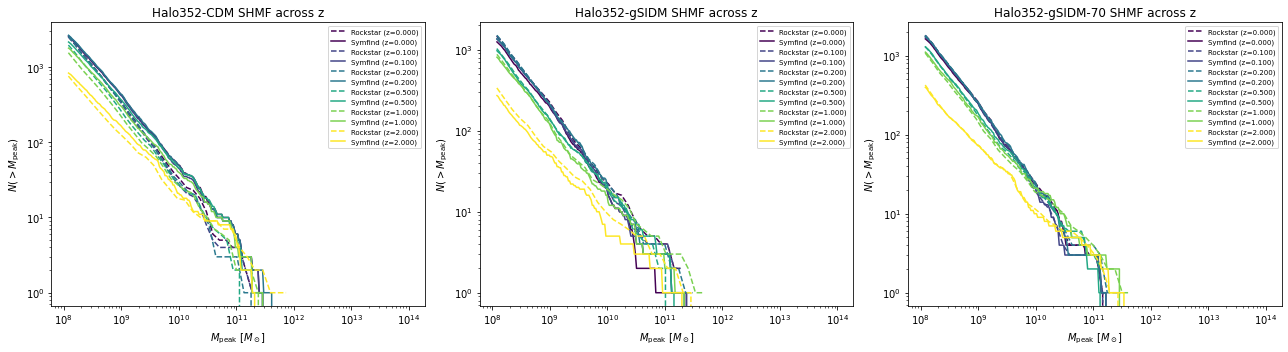

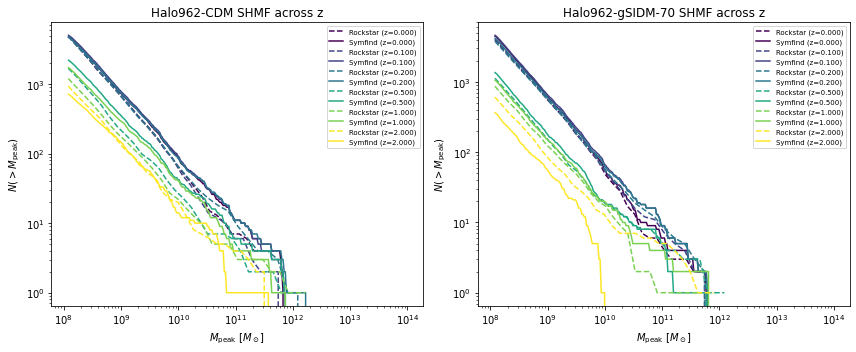

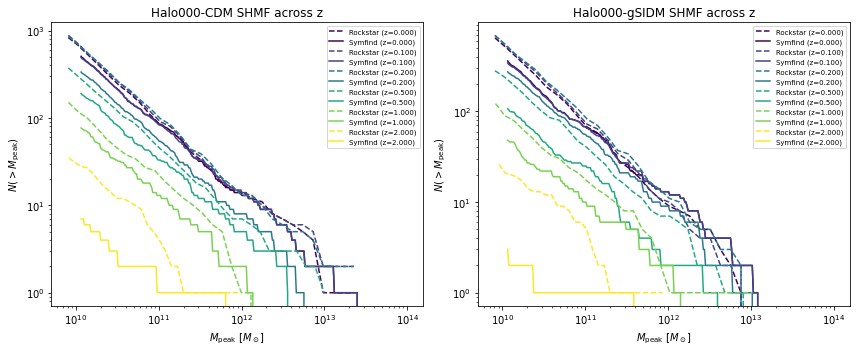

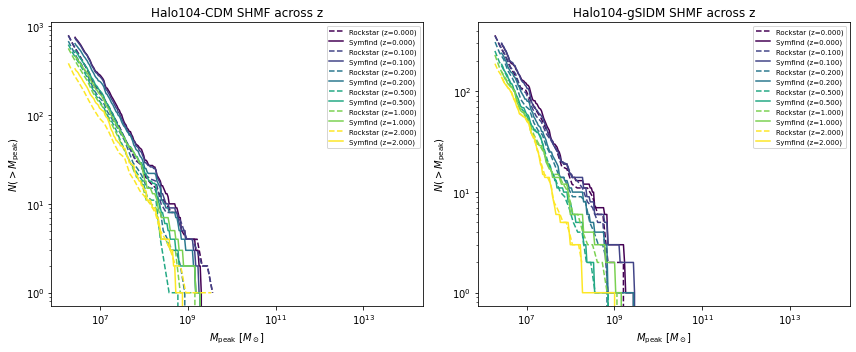

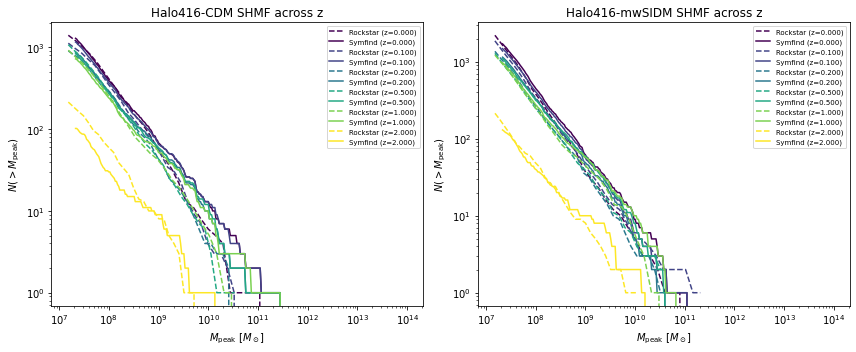

In [2]:

import symlib_addconcerto1
   

# symfind code dr nadler gave me 

# def rockstar_shmf(hlist_dir, particle_mass, target_z):
def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir


def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_shmf(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_shmf(base_dir, suite, halo_name, iz)

            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$M_{\rm peak}$ [$M_\odot$]')
            ax.set_ylabel(r'$N(>M_{\rm peak})$')
            ax.set_title(f"{halo_name} SHMF across z")

        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

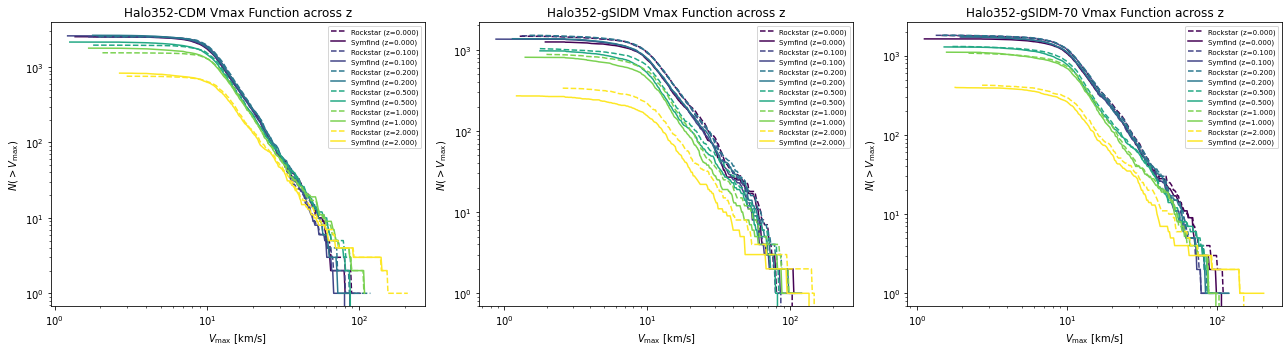

In [ ]:
def symfind_vmax(base_dir, suite, halo_name, target_z, n_bins=300):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    keep = ok & (sf_hist["mpeak"] > mass_cut)
    keep[0] = False  # drop the host itself

    v_subs = sf["vmax"][:, snap_index][keep]

    if len(v_subs) == 0:
        raise ValueError(f"No subhalos survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(v_subs.min()), np.log10(v_subs.max()), n_bins)
    n, _ = np.histogram(v_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N



def rockstar_vmax(hlist_dir, particle_mass, target_z, n_bins=300):
    """Load the snapshot closest to target_z, find the largest host, and
    return a cumulative Vmax function for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_ok = subs['mpeak'] / h_hubble > mass_cut
    vmax_subs = subs['vmax'][within_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found



halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'

cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

'''
for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_vmax, rockstar_z = rockstar_shmf(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, iz)

            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$V_{\rm max}$ [km/s]') #r'$M_{\rm peak}$ [$M_\odot$]')
            ax.set_ylabel(r'$N(>M_{\rm peak})$')
            ax.set_title(f"{halo_name} Vmax Function across z")

        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()
'''

for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, rockstar_z = rockstar_vmax(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_vmax(base_dir, suite, halo_name, iz)
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$V_{\rm max}$ [km/s]')
            ax.set_ylabel(r'$N(>V_{\rm max})$')
            ax.set_title(f"{halo_name} Vmax Function across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


TypeError: 'numpy.void' object is not callable

ValueError: too many values to unpack (expected 2)

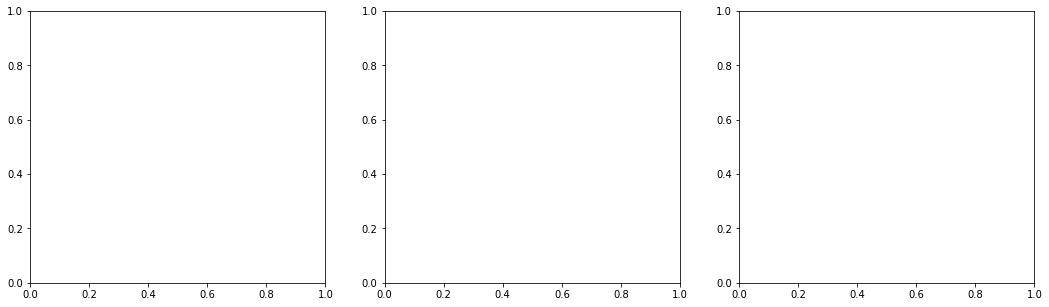

In [6]:
import symlib_addconcerto1

def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found    
        
    
    #bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    #n, _ = np.histogram(r_over_rvir, bins=bins)
    #return bins, n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)

    r = np.sqrt(np.sum(h["x"][:, snap_index] ** 2, axis=1))  # physical kpc, host-centered
    host_rvir = h["rvir"][0, snap_index]                     # physical kpc, same snapshot

    ok = h["ok"][:, snap_index]
    mass_ok = h["mvir"][:, snap_index] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]


for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N = symfind_radial_dist(base_dir, suite, halo_name, iz)
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$ "Distance from host center [Mpc/h]"')
            ax.set_ylabel(r'$Number of Subhalos)$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


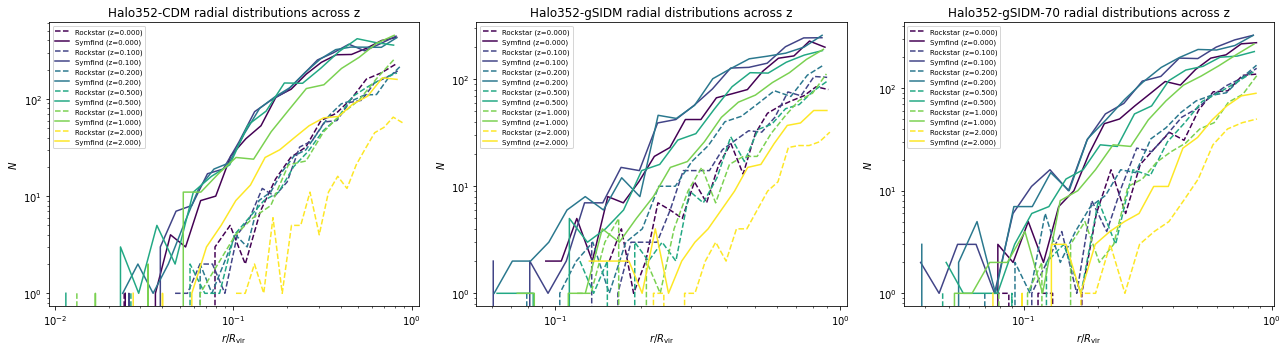

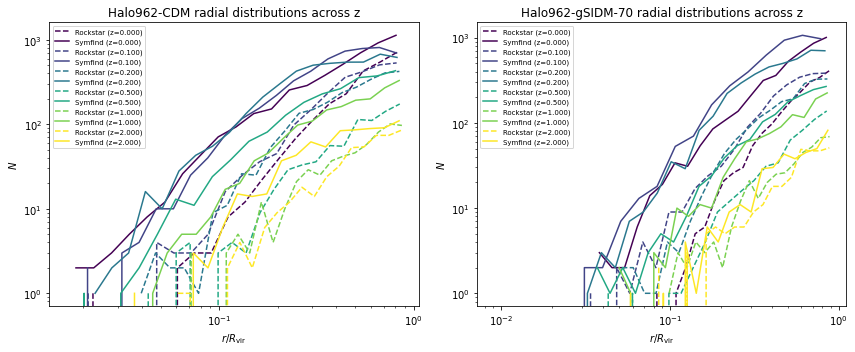

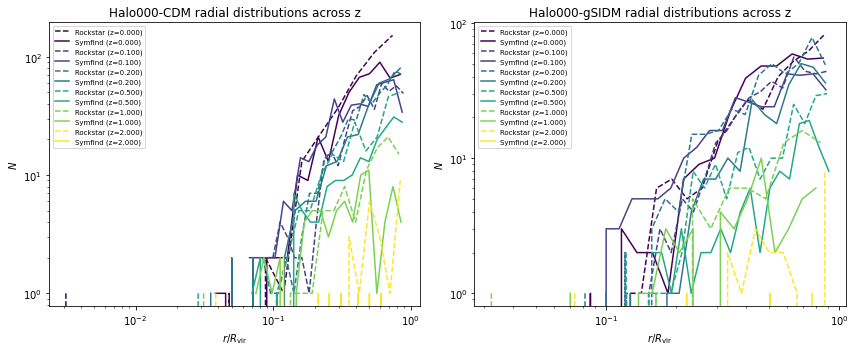

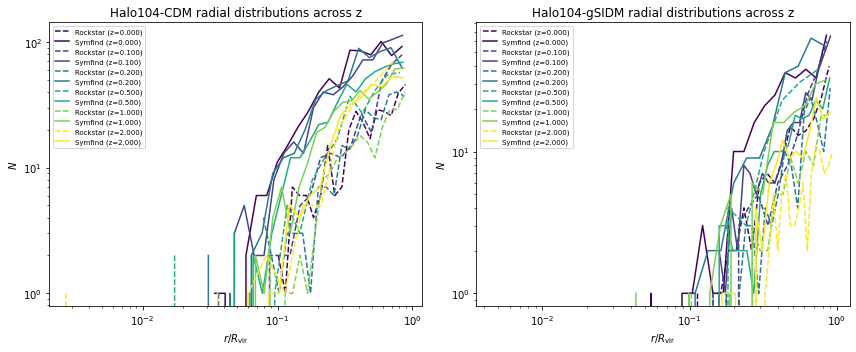

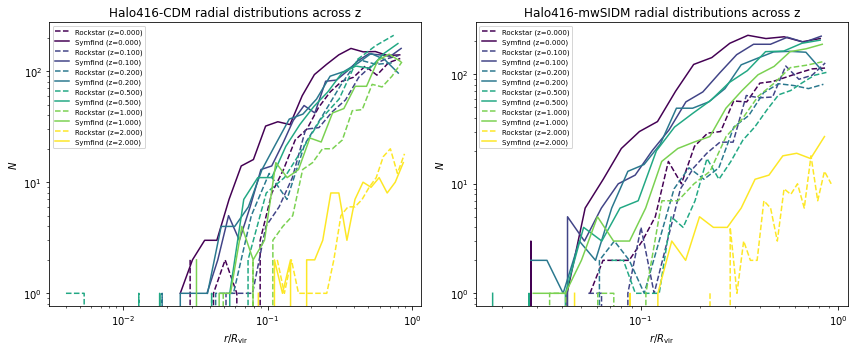

In [2]:

import symlib_addconcerto1

def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found    
        

def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs

    
'''    
    
def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]   # host property, taken from Rockstar-derived catalog

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))  # physical kpc, host-centered
    ok = sf["ok"][:, snap_index]
    mass_ok = sf["mpeak"][:, snap_index] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs
'''


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()




In [10]:
def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs

In [ ]:
bins, n, host_rvor, nsubs = symfind_radial_dist(base_dir, suite, halo

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

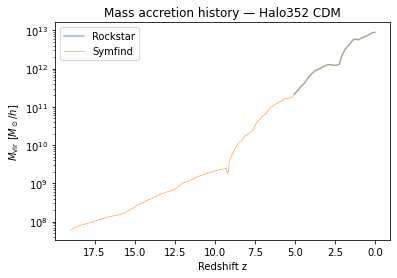

In [4]:
#
'''
def MAH_rockstar(hlist_dir, particle_mass, list_of_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    for target_z in list_of_z:
    
    
        lookup = build_redshift_lookup(hlist_dir)
        z_found, hlist_path = find_closest_hlist(target_z, lookup)

        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
        host = h[h['id'] == largest_halo_id][0]
        host_rvir_mpc = host['rvir'] / 1000.0

        subs = h[h['upid'] == largest_halo_id]
        dists = getDistance(host, subs, box_size=125)

        sub_mass = subs['mvir'] / h_hubble
        mass_ok = sub_mass > mass_cut

        r_over_rvir = dists[mass_ok] / host_rvir_mpc
        r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]

        n_subs = len(r_over_rvir)
        if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir.min()), np.log10(r_over_rvir.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    
    # return list of z and list of host mass that i can plot as the mass accretion histories
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found 
    
''' 
    
def MAH_rockstar(hlist_dir, list_of_z,h_hubble=0.7):
    """For each target redshift, find the largest host halo and record its
    virial mass, returning arrays for plotting M_vir(z)."""
    lookup = build_redshift_lookup(hlist_dir)

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
        host = h[h['id'] == largest_halo_id][0]

        z_list.append(z_found)
        mvir_list.append(host['mvir'])

    return np.array(z_list), np.array(mvir_list)

'''
def MAH_symfind(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
        total_hosts = symlib_addconcerto.n_hosts(suite)

    # Load scale factors (same across halos in suite)
    sim_dir_example = symlib_addconcerto.get_host_directory(base_dir, suite, 0)
    scale_factors = symlib_addconcerto.scale_factors(sim_dir_example)
    n_snaps = len(scale_factors)

    # Preload all host data
    host_data = []
    for j in range(total_hosts):
        sim_dir = symlib_addconcerto.get_host_directory(base_dir, suite, j)
        r, _ = symlib_addconcerto.read_rockstar(sim_dir)
        host_data.append(r[0])  # only host, not subhalos

    n_snaps_common = min(len(r_host) for r_host in host_data)
    a_common = scale_factors[:n_snaps_common]
    
    # Plot individual hosts (semi-transparent)
    for r_host in host_data:
        n_snaps_host = len(r_host)
        masses = [r_host[snap]["m"] if r_host[snap]["ok"] else np.nan for snap in range(n_snaps_common)]
        ax.plot(a_common, masses, color=color, alpha=0.15, linewidth=1)

    # Compute and plot average host mass
    average_masses = []
    
    
    for snap in range(n_snaps_common):
        valid_masses = [r_host[snap]["m"] for r_host in host_data if r_host[snap]["ok"]]
        # avg = np.mean(valid_masses) if len(valid_masses) > 0 else np.nan
        average_masses.append(np.mean(valid_masses) if valid_masses else np.nan)

    ### ax.plot(a_common, average_masses, color=color, linewidth=2.5, label=suite)
    # return list of z and list of host mass that i can plot as the mass accretion histories


def MAH_symfind(base_dir, suite, halo_name):
    """Return (redshift, host_mass) arrays for a single named halo's
    mass accretion history, using symlib/Symfind data."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)

    r, _ = symlib_addconcerto1.read_rockstar(sim_dir)
    r_host = r[0]  # host halo only, not subhalos

    n_snaps = len(r_host)
    masses = np.array([r_host[snap]["m"] if r_host[snap]["ok"] else np.nan
                        for snap in range(n_snaps)])
    a = scale_factors[:n_snaps]
    z = 1.0 / a - 1.0

    return z, masses
'''

def MAH_symfind(base_dir, suite, halo_name, h_hubble=0.7):
    """Return (redshift, host_mvir) arrays in Msun/h, matching Rockstar's convention."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    r, _ = symlib_addconcerto1.read_rockstar(sim_dir)
    r_host = r[0]  # host halo only

    n_snaps = len(r_host)
    # use the actual Mvir field name once confirmed via r.dtype.names
    mvir_msun = np.array([r_host[snap]["m"] if r_host[snap]["ok"] else np.nan
                           for snap in range(n_snaps)])

    # convert physical Msun -> Msun/h to match Rockstar hlist convention
    mvir_msun_over_h = mvir_msun * h_hubble

    a = scale_factors[:n_snaps]
    z = 1.0 / a - 1.0

    return z, mvir_msun_over_h

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
# list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

list_of_z = np.linspace(0, 5, 30)  # finer grid for a smooth MAH curve
# '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

#rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352CDM/cdm_8k/rockstar/hlists', list_of_z)
#symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")

rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', list_of_z)
symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")


plt.plot(rockstar_z_arr, rockstar_mvir_arr, label = "Rockstar", lw=1.5,alpha=0.5)
plt.plot(symfind_z_arr, symfind_mvir_arr, label = "Symfind",lw=0.5)
plt.yscale('log')
plt.gca().invert_xaxis()  # convention: higher z (past) on the left, z=0 (today) on the right
plt.xlabel('Redshift z')
plt.ylabel(r'$M_{\rm vir}$ [$M_\odot/h$]')
plt.title('Mass accretion history — Halo352 CDM')
plt.legend()
plt.show()


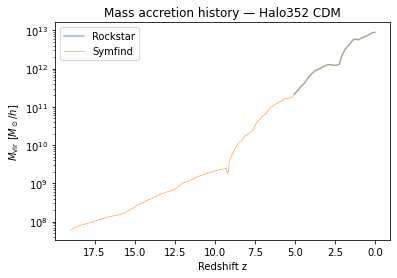

In [2]:
'''   
def MAH_rockstar(hlist_dir, list_of_z,h_hubble=0.7):
    """For each target redshift, find the largest host halo and record its
    virial mass, returning arrays for plotting M_vir(z)."""
    lookup = build_redshift_lookup(hlist_dir)

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
        host = h[h['id'] == largest_halo_id][0]

        z_list.append(z_found)
        mvir_list.append(host['mvir'])

    return np.array(z_list), np.array(mvir_list)
'''


def MAH_rockstar(hlist_dir, list_of_z, h_hubble=0.7):
    """Track a single host halo's Mvir across cosmic time by following its
    Tree_root_ID and main-branch (mmp) flag through the merger tree."""
    lookup = build_redshift_lookup(hlist_dir)

    # Step 1: identify the host at z=0 and get its Tree_root_ID
    z0_actual, z0_path = find_closest_hlist(0.0, lookup)
    h0 = readHlist(z0_path, ['id', 'mvir', 'upid', 'Tree_root_ID'])
    host_mask = h0['upid'] == -1
    host_id_z0 = h0['id'][host_mask][h0['mvir'][host_mask].argmax()]
    tree_root_id = h0['Tree_root_ID'][h0['id'] == host_id_z0][0]

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'Tree_root_ID', 'mmp?'])

        # same tree, main branch progenitor only
        same_tree = h['Tree_root_ID'] == tree_root_id
        main_branch = same_tree & (h['mmp?'] == 1) & (h['upid'] == -1)

        if not np.any(main_branch):
            z_list.append(z_found)
            mvir_list.append(np.nan)
            continue

        z_list.append(z_found)
        mvir_list.append(h['mvir'][main_branch][0])

    return np.array(z_list), np.array(mvir_list)

def MAH_symfind(base_dir, suite, halo_name, h_hubble=0.7):
    """Return (redshift, host_mvir) arrays in Msun/h, matching Rockstar's convention."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    r, _ = symlib_addconcerto1.read_rockstar(sim_dir)
    r_host = r[0]  # host halo only

    n_snaps = len(r_host)
    # use the actual Mvir field name once confirmed via r.dtype.names
    mvir_msun = np.array([r_host[snap]["m"] if r_host[snap]["ok"] else np.nan
                           for snap in range(n_snaps)])

    # convert physical Msun -> Msun/h to match Rockstar hlist convention
    mvir_msun_over_h = mvir_msun * h_hubble

    a = scale_factors[:n_snaps]
    z = 1.0 / a - 1.0

    return z, mvir_msun_over_h

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
# list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

list_of_z = np.linspace(0, 5, 30)  # finer grid for a smooth MAH curve
# '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

#rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352CDM/cdm_8k/rockstar/hlists', list_of_z)
#symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")

rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', list_of_z)
symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")


plt.plot(rockstar_z_arr, rockstar_mvir_arr, label = "Rockstar", lw=1.5,alpha=0.5)
plt.plot(symfind_z_arr, symfind_mvir_arr, label = "Symfind",lw=0.5)
plt.yscale('log')
plt.gca().invert_xaxis()  # convention: higher z (past) on the left, z=0 (today) on the right
plt.xlabel('Redshift z')
plt.ylabel(r'$M_{\rm vir}$ [$M_\odot/h$]')
plt.title('Mass accretion history — Halo352 CDM')
plt.legend()
plt.show()


In [7]:

def MAH_rockstar(base_dir, suite, halo_name, h_hubble=0.7): #hlist_dir, list_of_z, h_hubble=0.7):
    """Track a single host halo's Mvir across cosmic time by following its
    Tree_root_ID and main-branch (mmp) flag through the merger tree."""
    # try using read_rockstar
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    r, _ = symlib_addconcerto1.read_rockstar(sim_dir)
    r_host = r[0]  # host halo only

    n_snaps = len(r_host)
    # use the actual Mvir field name once confirmed via r.dtype.names
    mvir_msun = np.array([r_host[snap]["mpeak"] if r_host[snap]["ok"] else np.nan
                           for snap in range(n_snaps)])

    # convert physical Msun -> Msun/h to match Rockstar hlist convention
    mvir_msun_over_h = mvir_msun * h_hubble

    a = scale_factors[:n_snaps]
    z = 1.0 / a - 1.0

    return z, mvir_msun_over_h

def MAH_symfind(base_dir, suite, halo_name, h_hubble=0.7):
    """Return (redshift, host_mvir) arrays in Msun/h, matching Rockstar's convention."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    r, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    r_host = r[0]  # host halo only

    n_snaps = len(r_host)
    # use the actual Mvir field name once confirmed via r.dtype.names
    mvir_msun = np.array([r_host[snap]["mpeak"] if r_host[snap]["ok"] else np.nan
                           for snap in range(n_snaps)])

    # convert physical Msun -> Msun/h to match Rockstar hlist convention
    mvir_msun_over_h = mvir_msun * h_hubble

    a = scale_factors[:n_snaps]
    z = 1.0 / a - 1.0

    return z, mvir_msun_over_h

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
# list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

list_of_z = np.linspace(0, 5, 30)  # finer grid for a smooth MAH curve
# '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists'

#rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352CDM/cdm_8k/rockstar/hlists', list_of_z)
#symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")

rockstar_z_arr, rockstar_mvir_arr = MAH_rockstar(base_dir, "ConcertoGroupHR", "Halo352-CDM") #('/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists', list_of_z)
symfind_z_arr, symfind_mvir_arr = MAH_symfind(base_dir, "ConcertoGroupHR", "Halo352-CDM")


plt.plot(rockstar_z_arr, rockstar_mvir_arr, label = "Rockstar", lw=1.5,alpha=0.5)
plt.plot(symfind_z_arr, symfind_mvir_arr, label = "Symfind",lw=0.5)
plt.yscale('log')
plt.gca().invert_xaxis()  # convention: higher z (past) on the left, z=0 (today) on the right
plt.xlabel('Redshift z')
plt.ylabel(r'$M_{\rm vir}$ [$M_\odot/h$]')
plt.title('Mass accretion history — Halo352 CDM')
plt.legend()
plt.show()


ValueError: no field of name mpeak

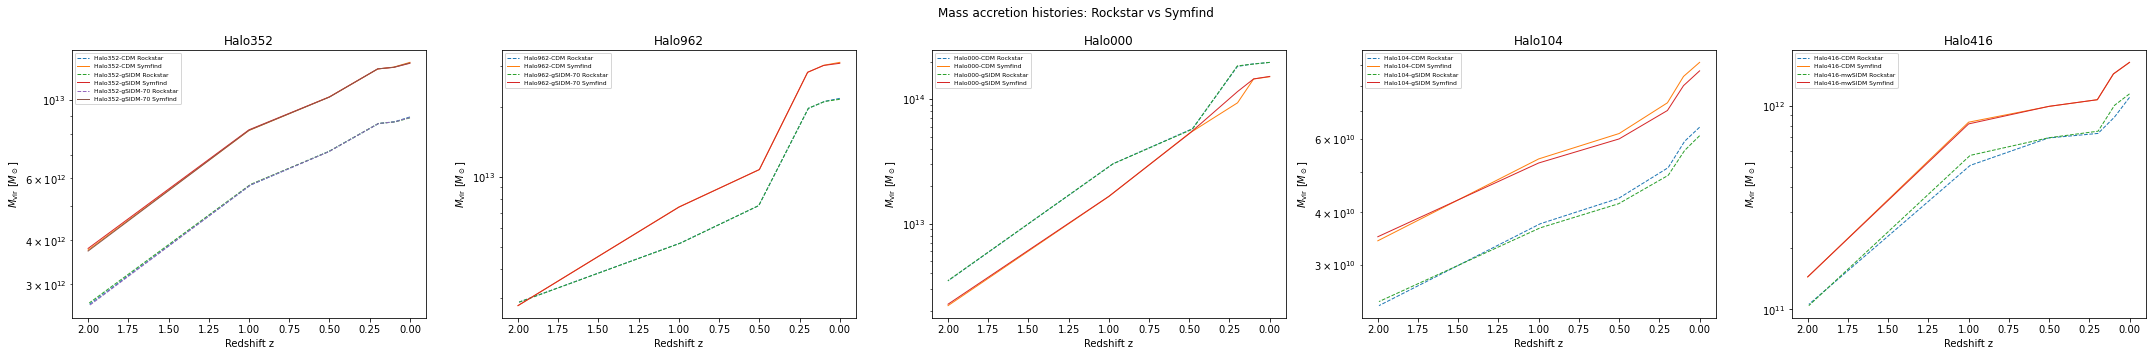

In [3]:
def rockstar_MAH(hlist_dir, list_of_z):
    """For each target redshift, find the largest host halo (same method as
    rockstar_shmf) and record its Mvir, returning (z, mvir) arrays."""
    lookup = build_redshift_lookup(hlist_dir)

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
        host = h[h['id'] == largest_halo_id][0]

        z_list.append(z_found)
        mvir_list.append(host['mvir'])

    return np.array(z_list), np.array(mvir_list)


def symfind_MAH(base_dir, suite, halo_name, list_of_z):
    """For each target redshift, get the tree-tracked host's Mvir from the
    same read_subhalos call used in symfind_shmf, returning (z, mvir) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    # h, _ = symlib_addconcerto1.read_symfind(sim_dir)

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        z_list.append(target_z)
        mvir_list.append(h["mvir"][0, snap_index])

    return np.array(z_list), np.array(mvir_list)




halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
#list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]


'''
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig.ax = plt.subplots(1,len(halo_groups))
ax = ax.flatten()

for ih,halo in enumerate(halo_groups):
    ax = ax[ih]
    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, rmvir = rockstar_MAH(hlist_dir, list_of_z)
        sz, smvir = symfind_MAH(base_dir, suite, halo_name, list_of_z)

        plt.plot(rz, rmvir, ls='dashed', label=f"{halo_name} Rockstar",lw=0.5)
        plt.plot(sz, smvir, label=f"{halo_name} Symfind",lw=0.5)

    ax.set_yscale('log')
    plt.gca().invert_xaxis()
    ax.set_xlabel('Redshift z')
    ax.set_ylabel(r'$M_{\rm vir}$ [$M_\odot$]')
    plt.legend(fontsize=6)
    plt.title(f"{suite}")
plt.suptitle('Mass accretion histories: Rockstar vs Symfind')
plt.show()
'''

list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(halo_groups), figsize=(6 * len(halo_groups), 5))
axes = axes.flatten()

for ih, halo in enumerate(halo_groups):
    cur_ax = axes[ih]

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, rmvir = rockstar_MAH(hlist_dir, list_of_z)
        sz, smvir = symfind_MAH(base_dir, suite, halo_name, list_of_z)

        cur_ax.plot(rz, rmvir, ls='dashed', label=f"{halo_name} Rockstar", lw=1.0)
        cur_ax.plot(sz, smvir, label=f"{halo_name} Symfind", lw=1.0)

    cur_ax.set_yscale('log')
    cur_ax.invert_xaxis()
    cur_ax.set_xlabel('Redshift z')
    cur_ax.set_ylabel(r'$M_{\rm vir}$ [$M_\odot$]')
    cur_ax.legend(fontsize=6)

    group_name = halo[0][1].rsplit('-', 1)[0]  # e.g. "Halo352" from "Halo352-CDM"
    cur_ax.set_title(group_name)

fig.suptitle('Mass accretion histories: Rockstar vs Symfind')
plt.tight_layout()
plt.show()


In [ ]:
# yay now do nsub evolution history; track number of subhalos over redshift

def rockstar_nsub_evol(hlist_dir, list_of_z):

    lookup = build_redshift_lookup(hlist_dir)

    z_list = []
    mvir_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
        host = h[h['id'] == largest_halo_id][0]

        z_list.append(z_found)
        mvir_list.append(host['mvir'])

    return np.array(z_list), np.array(mvir_list)


def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z):

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    # h, _ = symlib_addconcerto1.read_symfind(sim_dir)

    z_list = []
    # mvir_list = []
    nsub_list = []

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        z_list.append(target_z)
        mvir_list.append(h["mvir"][0, snap_index])
        

    return np.array(z_list), np.array(mvir_list)




halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
#list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]


'''
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig.ax = plt.subplots(1,len(halo_groups))
ax = ax.flatten()

for ih,halo in enumerate(halo_groups):
    ax = ax[ih]
    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, rmvir = rockstar_MAH(hlist_dir, list_of_z)
        sz, smvir = symfind_MAH(base_dir, suite, halo_name, list_of_z)

        plt.plot(rz, rmvir, ls='dashed', label=f"{halo_name} Rockstar",lw=0.5)
        plt.plot(sz, smvir, label=f"{halo_name} Symfind",lw=0.5)

    ax.set_yscale('log')
    plt.gca().invert_xaxis()
    ax.set_xlabel('Redshift z')
    ax.set_ylabel(r'$M_{\rm vir}$ [$M_\odot$]')
    plt.legend(fontsize=6)
    plt.title(f"{suite}")
plt.suptitle('Mass accretion histories: Rockstar vs Symfind')
plt.show()
'''

list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(halo_groups), figsize=(6 * len(halo_groups), 5))
axes = axes.flatten()

for ih, halo in enumerate(halo_groups):
    cur_ax = axes[ih]

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, rmvir = rockstar_MAH(hlist_dir, list_of_z)
        sz, smvir = symfind_MAH(base_dir, suite, halo_name, list_of_z)

        cur_ax.plot(rz, rmvir, ls='dashed', label=f"{halo_name} Rockstar", lw=1.0)
        cur_ax.plot(sz, smvir, label=f"{halo_name} Symfind", lw=1.0)

    cur_ax.set_yscale('log')
    cur_ax.invert_xaxis()
    cur_ax.set_xlabel('Redshift z')
    cur_ax.set_ylabel(r'$M_{\rm vir}$ [$M_\odot$]')
    cur_ax.legend(fontsize=6)

    group_name = halo[0][1].rsplit('-', 1)[0]  # e.g. "Halo352" from "Halo352-CDM"
    cur_ax.set_title(group_name)

fig.suptitle('Mass accretion histories: Rockstar vs Symfind')
plt.tight_layout()
plt.show()


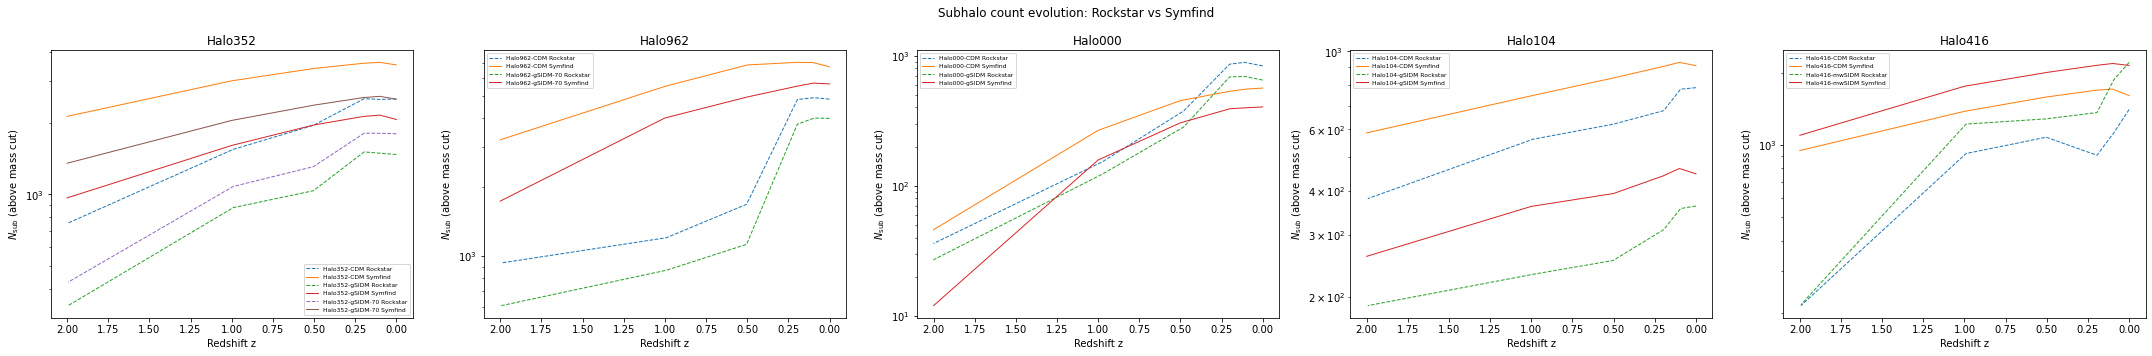

In [2]:
def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    """For each target redshift, count subhalos belonging to the largest host
    (above a mass cut), returning (z, n_sub) arrays."""
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)

        z_list.append(z_found)
        nsub_list.append(n_sub)

    return np.array(z_list), np.array(nsub_list)



def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    """For each target redshift, count Symfind-tracked subhalos above a mass
    cut, returning (z, n_sub) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]  # skip index 0 (the host itself)
        n_sub = np.sum(sub_masses > mass_cut)

        z_list.append(target_z)
        nsub_list.append(n_sub)

    return np.array(z_list), np.array(nsub_list)

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(halo_groups), figsize=(6 * len(halo_groups), 5))
axes = axes.flatten()

for ih, halo in enumerate(halo_groups):
    cur_ax = axes[ih]

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, r_nsub = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)
        sz, s_nsub = symfind_nsub_evol(base_dir, suite, halo_name, list_of_z)

        cur_ax.plot(rz, r_nsub, ls='dashed', label=f"{halo_name} Rockstar", lw=1.0)
        cur_ax.plot(sz, s_nsub, label=f"{halo_name} Symfind", lw=1.0)

    cur_ax.set_yscale('log')
    cur_ax.invert_xaxis()
    cur_ax.set_xlabel('Redshift z')
    cur_ax.set_ylabel(r'$N_{\rm sub}$ (above mass cut)')
    cur_ax.legend(fontsize=6)

    group_name = halo[0][1].rsplit('-', 1)[0]
    cur_ax.set_title(group_name)

fig.suptitle('Subhalo count evolution: Rockstar vs Symfind')
plt.tight_layout()
plt.show()

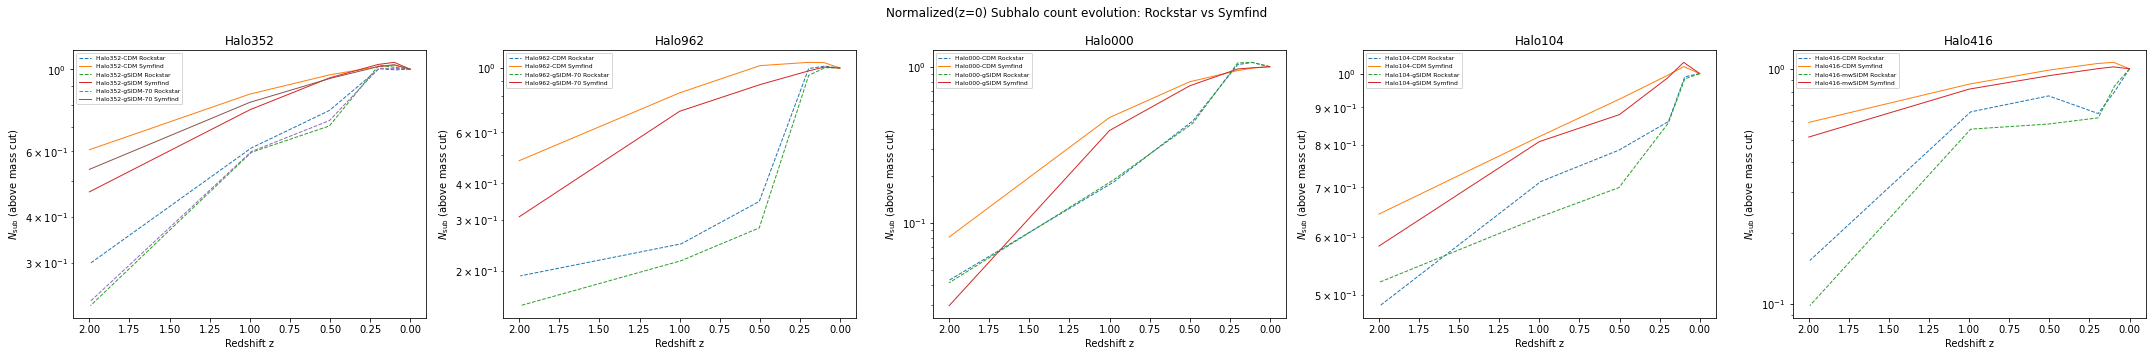

In [2]:

# yipee now normalize it to nsub at z=0 

def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    """For each target redshift, count subhalos belonging to the largest host
    (above a mass cut), returning (z, n_sub) arrays."""
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)
        
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(z_found)
        nsub_list.append(n_sub)
        
    nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list_normalized)

    # return np.array(z_list), np.array(nsub_list)



def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    """For each target redshift, count Symfind-tracked subhalos above a mass
    cut, returning (z, n_sub) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []
    
    

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]  # skip index 0 (the host itself)
        n_sub = np.sum(sub_masses > mass_cut)
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(target_z)
        nsub_list.append(n_sub)
        
        
    nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list_normalized)

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(halo_groups), figsize=(6 * len(halo_groups), 5))
axes = axes.flatten()

for ih, halo in enumerate(halo_groups):
    cur_ax = axes[ih]

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, r_nsub = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)
        sz, s_nsub = symfind_nsub_evol(base_dir, suite, halo_name, list_of_z)

        cur_ax.plot(rz, r_nsub, ls='dashed', label=f"{halo_name} Rockstar", lw=1.0)
        cur_ax.plot(sz, s_nsub, label=f"{halo_name} Symfind", lw=1.0)

    cur_ax.set_yscale('log')
    cur_ax.invert_xaxis()
    cur_ax.set_xlabel('Redshift z')
    cur_ax.set_ylabel(r'$N_{\rm sub}$ (above mass cut)')
    cur_ax.legend(fontsize=6)

    group_name = halo[0][1].rsplit('-', 1)[0]
    cur_ax.set_title(group_name)

fig.suptitle('Normalized(z=0) Subhalo count evolution: Rockstar vs Symfind')
plt.tight_layout()
plt.show()

In [5]:
'''list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416]
list_of_z = [0.1, 0.2, 0.5, 1.0, 2.0]

n_groups = len(list_of_halos)
max_models = max(len(h) for h in list_of_halos)
ncols = max_models + 1  # +1 for the ratio panel

fig, axes = plt.subplots(n_groups, ncols, figsize=(6 * ncols, 6 * n_groups))
cmap = plt.get_cmap("viridis")
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

def radial_distribution(hlist_path, particle_mass, n_rvir_max=1, n_bins=20):
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])
    mass_cut = 300 * particle_mass
    h_hubble=0.7
    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs,box_size=125) # try instead calculating distances by hand, take x y z coordinates and take root of sum of squares 
    sub_mass = subs['mvir'] / h_hubble # cut current number of particles, not peak number of particles 

    mass_ok = sub_mass > mass_cut
    dists = dists[mass_ok]
    dists = dists[dists < n_rvir_max * host_rvir_mpc]
    # print(n_rvir_max)

    n_subs = len(dists)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )
    #print("Number of subhalos: " + str(n_subs))
    # print(np.max(n_subs))
    
    bins = np.logspace(np.log10(dists.min()), np.log10(dists.max()), n_bins)
    n, _ = np.histogram(dists, bins=bins)

    #assert n.sum() == n_subs, (
    #    f"Histogram lost points: sum(n)={n.sum()} but n_subs={n_subs}. "
    #    "Check for dists outside [bins[0], bins[-1]] due to float edge effects."
    #)

    #print("maximum number of subhalos: " + str(np.max(n)))
    return bins, n, host_rvir_mpc, n_subs


def get_vmax_function(hlist_path, particle_mass, n_bins=30):
    """Load a catalog, find its largest host, and return Vmax function curves
    for r<Rvir and r<0.5*Rvir."""
    h = readHlist(hlist_path, ['id', 'mvir', 'upid', 'rvir', 'x', 'y', 'z', 'vmax'])
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc
    within_half_rvir = dists < (0.5 * host_rvir_mpc)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    vmax_subs = subs['vmax'][within_rvir & mass_ok]
    vmax_subs_half = subs['vmax'][within_half_rvir & mass_ok]

    if len(vmax_subs) == 0:
        raise ValueError(f"No subhalos survive Rvir + mass cuts for {hlist_path}")

    bins = np.logspace(np.log10(vmax_subs.min()), np.log10(vmax_subs.max()), n_bins)
    n, _ = np.histogram(vmax_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    bins_half = np.logspace(np.log10(vmax_subs_half.min()), np.log10(vmax_subs_half.max()), n_bins)
    n_half, _ = np.histogram(vmax_subs_half, bins=bins_half)
    N_half = np.cumsum(n_half[::-1])[::-1]

    return bins, N, bins_half, N_half, host
'''





# yipee now normalize it to nsub at z=0 

def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    """For each target redshift, count subhalos belonging to the largest host
    (above a mass cut), returning (z, n_sub) arrays."""
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)
        
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(z_found)
        nsub_list.append(n_sub)
        
    # nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

    # return np.array(z_list), np.array(nsub_list)



def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    """For each target redshift, count Symfind-tracked subhalos above a mass
    cut, returning (z, n_sub) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []
    
    

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]  # skip index 0 (the host itself)
        n_sub = np.sum(sub_masses > mass_cut)
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(target_z)
        nsub_list.append(n_sub)
        
        
    #nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for igroup, ihalo in enumerate(list_of_halos):
    model_curves = {}  # label -> {target_z: (bins, N, actual_z)}

    for i_model, (label, hlist_dir, particle_mass) in enumerate(ihalo):
        lookup = build_redshift_lookup(hlist_dir)
        model_curves[label] = {}

        for i_z, target_z in enumerate(list_of_z):
            actual_z, hlist_path = find_closest_hlist(target_z, lookup)
            bins, N, bins_half, N_half, host= get_vmax_function(hlist_path, particle_mass)
            model_curves[label][target_z] = (bins, N, actual_z)

            color = cmap(i_z / max(len(list_of_z) - 1, 1))
            axes[igroup, i_model].plot(bins[:-1], N, color=color, label=f"z={actual_z:.2f}")

        axes[igroup, i_model].set_xscale('log')
        axes[igroup, i_model].set_yscale('log')
        axes[igroup, i_model].set_title(label, fontsize=9)
        if igroup == n_groups - 1:
            axes[igroup, i_model].set_xlabel(r"", fontsize=8) # "Distance from host center [Mpc/h]"
        if i_model == 0:
            axes[igroup, i_model].set_ylabel(r"Number of Subhalos", fontsize=8)
        axes[igroup, i_model].legend(fontsize=5, title="z", title_fontsize=6)

    # hide unused model columns for groups with fewer models
    for empty_col in range(len(ihalo), max_models):
        axes[igroup, empty_col].axis('off')

    # --- ratio panel (last column): all non-CDM models vs CDM ---
    ratio_ax = axes[igroup, -1]
    cdm_label = next((lbl for lbl in model_curves if 'CDM' in lbl), None)
    other_labels = [lbl for lbl in model_curves if lbl != cdm_label]

    if cdm_label is not None:
        for i_other, other_label in enumerate(other_labels):
            ls = linestyles[i_other % len(linestyles)]
            for i_z, target_z in enumerate(list_of_z):
                cdm_bins, cdm_N, actual_z = model_curves[cdm_label][target_z]
                other_bins, other_N, _ = model_curves[other_label][target_z]

                common_mass = np.logspace(np.log10(cdm_bins[0]), np.log10(cdm_bins[-2]), 100)
                cdm_N_interp = np.interp(common_mass, cdm_bins[:-1], cdm_N)
                other_N_interp = np.interp(common_mass, other_bins[:-1], other_N)

                color = cmap(i_z / max(len(list_of_z) - 1, 1))
                label = f"{other_label.split(' ')[-1]}, z={actual_z:.2f}" if i_z == 0 else None
                ratio_ax.plot(common_mass, other_N_interp / cdm_N_interp, color=color, ls=ls,
                              label=f"{other_label.split(' ')[-1]}" if i_z == 0 else None)

        ratio_ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ratio_ax.legend(fontsize=5)
    else:
        ratio_ax.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ratio_ax.transAxes, fontsize=8)

    ratio_ax.set_xscale('log')
    ratio_ax.set_title("Ratio vs CDM", fontsize=9)
    if igroup == n_groups - 1:
        ratio_ax.set_xlabel(r"$V_{\rm max}$ [km/s]", fontsize=8)

    # row label (halo group name) on the far left
    group_name = ihalo[0][0].rsplit(' ', 1)[0]
    axes[igroup, 0].annotate(group_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                              fontsize=10, rotation=90, ha='center', va='center')

fig.suptitle("Vmax function and CDM ratios across all halo groups and redshifts", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'list_of_halos' is not defined

In [1]:
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

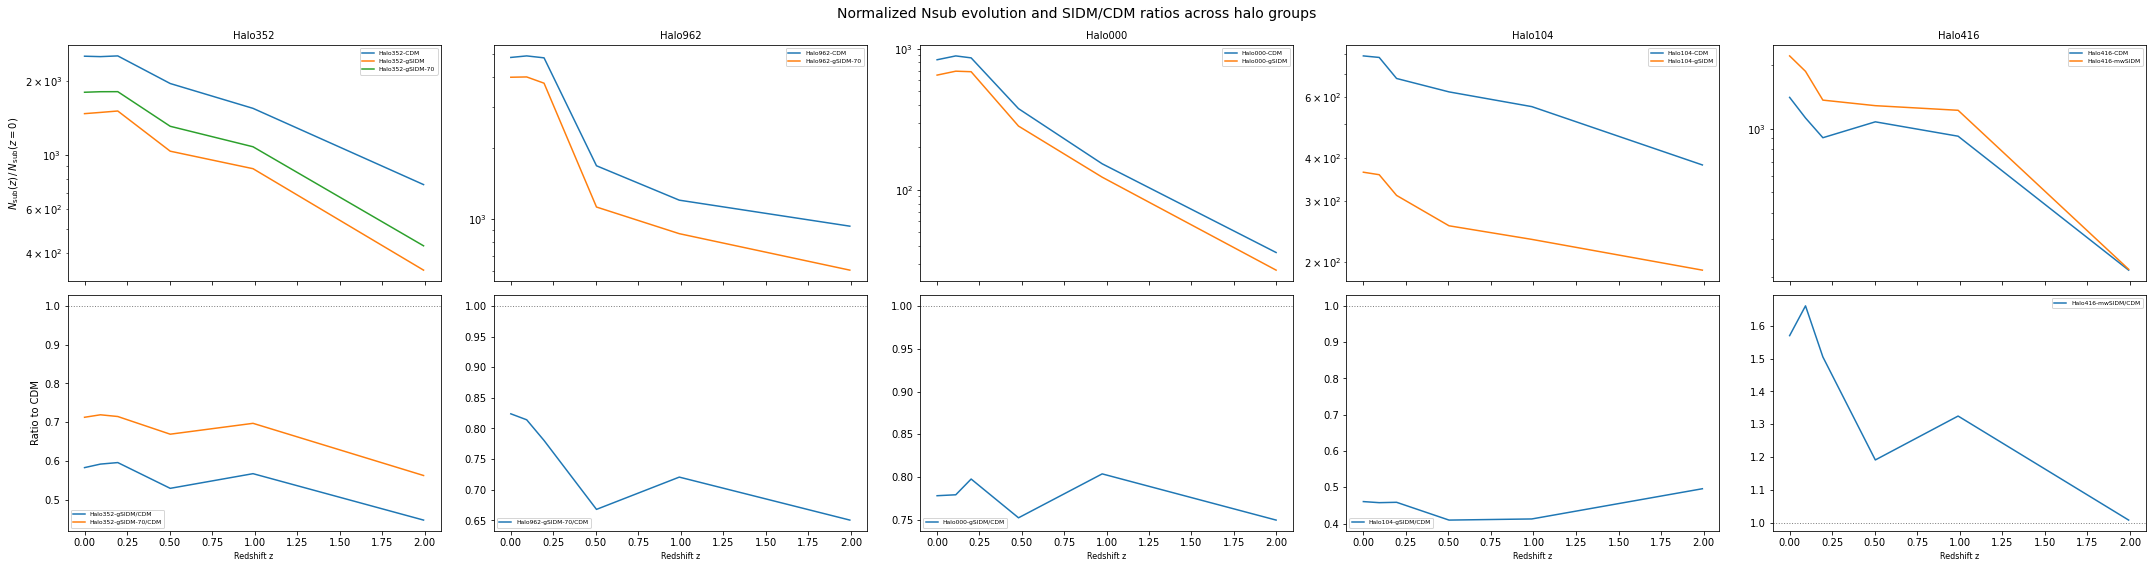

In [3]:
def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    """For each target redshift, count subhalos belonging to the largest host
    (above a mass cut), returning (z, n_sub) arrays."""
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)
        
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(z_found)
        nsub_list.append(n_sub)
        
    # nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

    # return np.array(z_list), np.array(nsub_list)



def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    """For each target redshift, count Symfind-tracked subhalos above a mass
    cut, returning (z, n_sub) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []
    
    

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]  # skip index 0 (the host itself)
        n_sub = np.sum(sub_masses > mass_cut)
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(target_z)
        nsub_list.append(n_sub)
        
        
    #nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]





#list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]
n_groups = len(halo_groups)

fig, axes = plt.subplots(2, n_groups, figsize=(6 * n_groups, 8), sharex='col')
cmap = plt.cm.viridis

for igroup, ihalo in enumerate(halo_groups):
    ax_top, ax_bot = axes[0, igroup], axes[1, igroup]

    nsub_curves = {}  # label -> (z_arr, nsub_arr)

    for suite, halo_name, hlist_dir, particle_mass in ihalo:
        rz, r_nsub = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)
        nsub_curves[halo_name] = (rz, r_nsub)
        ax_top.plot(rz, r_nsub, label=halo_name, lw=1.5)

    ax_top.set_yscale('log')
    ax_top.invert_xaxis()
    ax_top.legend(fontsize=6)
    group_name = ihalo[0][1].rsplit('-', 1)[0]
    ax_top.set_title(group_name, fontsize=10)
    if igroup == 0:
        ax_top.set_ylabel(r'$N_{\rm sub}(z) \, / \, N_{\rm sub}(z=0)$')

    # --- ratio panel: all non-CDM models vs CDM, same z grid, no interpolation needed ---
    cdm_label = next((lbl for lbl in nsub_curves if 'CDM' in lbl), None)
    other_labels = [lbl for lbl in nsub_curves if lbl != cdm_label]

    if cdm_label is not None and len(nsub_curves) > 1:
        cdm_z, cdm_nsub = nsub_curves[cdm_label]
        for other_label in other_labels:
            other_z, other_nsub = nsub_curves[other_label]
            ax_bot.plot(cdm_z, other_nsub / cdm_nsub, label=f"{other_label}/CDM", lw=1.5)
        ax_bot.axhline(1.0, color='gray', linestyle=':', linewidth=1)
        ax_bot.legend(fontsize=6)
    else:
        ax_bot.text(0.5, 0.5, "no CDM", ha='center', va='center', transform=ax_bot.transAxes, fontsize=8)

    ax_bot.invert_xaxis()
    ax_bot.set_xlabel('Redshift z', fontsize=8)
    if igroup == 0:
        ax_bot.set_ylabel('Ratio to CDM')

fig.suptitle('Normalized Nsub evolution and SIDM/CDM ratios across halo groups', fontsize=14)
plt.tight_layout()
plt.show()

TypeError: 'Axes' object is not subscriptable

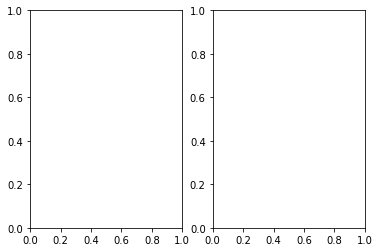

In [5]:
# Nsub(z) / Nsub(z=0) for each model (shape) -- two panels (left: all CDM, 5 lines; right: all SIDM, 6 lines)

def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    """For each target redshift, count subhalos belonging to the largest host
    (above a mass cut), returning (z, n_sub) arrays."""
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)
        
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(z_found)
        nsub_list.append(n_sub)
        
    # nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

    # return np.array(z_list), np.array(nsub_list)



def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    """For each target redshift, count Symfind-tracked subhalos above a mass
    cut, returning (z, n_sub) arrays."""
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []
    
    

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]  # skip index 0 (the host itself)
        n_sub = np.sum(sub_masses > mass_cut)
        if target_z == 0:
            nsub_z0 = n_sub

        z_list.append(target_z)
        nsub_list.append(n_sub)
        
        
    #nsub_list_normalized = nsub_list / nsub_z0

    return np.array(z_list), np.array(nsub_list) #_normalized)

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




#fig, axes = plt.subplots(1, len(halo_groups), figsize=(6 * len(halo_groups), 5))

fig, ax = plt.subplots(1,2)
axes = axes.flatten()

for ih, halo in enumerate(halo_groups):
    cur_ax = axes[ih]

    for i,(suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        rz, r_nsub = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)
        sz, s_nsub = symfind_nsub_evol(base_dir, suite, halo_name, list_of_z)
        
        if i == 0:
            cur_ax = axes[0]

        cur_ax[1].plot(rz, r_nsub, ls='dashed', label=f"{halo_name} Rockstar", lw=1.0)
        cur_ax[1].plot(sz, s_nsub, label=f"{halo_name} Symfind", lw=1.0)
        
        
            

    cur_ax.set_yscale('log')
    cur_ax.invert_xaxis()
    cur_ax.set_xlabel('Redshift z')
    cur_ax.set_ylabel(r'$N_{\rm sub}$ (above mass cut)')
    cur_ax.legend(fontsize=6)

    group_name = halo[0][1].rsplit('-', 1)[0]
    cur_ax.set_title(group_name)

fig.suptitle('Normalized(z=0) Subhalo count evolution: Rockstar vs Symfind')
plt.tight_layout()
plt.show()


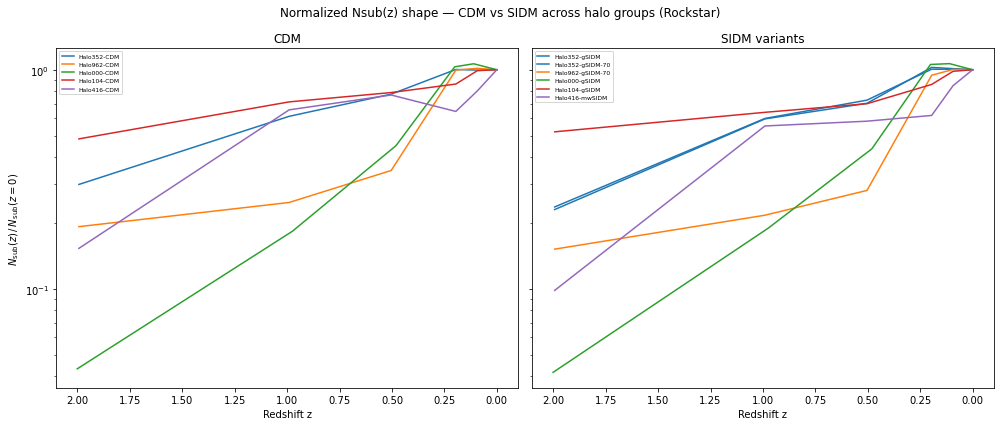

In [2]:

# for more bins, can load branch info for host halo



def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)

        z_list.append(z_found)
        nsub_list.append(n_sub)

    nsub_arr = np.array(nsub_list)
    nsub_z0 = nsub_arr[np.argmin(np.abs(np.array(z_list)))]  # value closest to z=0
    return np.array(z_list), nsub_arr / nsub_z0


def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]
        n_sub = np.sum(sub_masses > mass_cut)

        z_list.append(target_z)
        nsub_list.append(n_sub)

    nsub_arr = np.array(nsub_list)
    nsub_z0 = nsub_arr[np.argmin(np.abs(np.array(z_list)))]
    return np.array(z_list), nsub_arr / nsub_z0

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] # ADD HALO 004 TO THIS LIST

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
# list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
ax_cdm, ax_sidm = axes

cmap = plt.cm.tab10  # distinct colors per halo group, not a redshift gradient here

for igroup, halo in enumerate(halo_groups):
    color = cmap(igroup % 10)

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, r_nsub_norm = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)

        target_ax = ax_cdm if 'CDM' in halo_name else ax_sidm
        target_ax.plot(rz, r_nsub_norm, color=color, label=halo_name, lw=1.5)

ax_cdm.set_yscale('log')
ax_cdm.invert_xaxis()
ax_cdm.set_xlabel('Redshift z')
ax_cdm.set_ylabel(r'$N_{\rm sub}(z) \, / \, N_{\rm sub}(z=0)$')
ax_cdm.set_title('CDM')
ax_cdm.legend(fontsize=6)

ax_sidm.set_yscale('log')
ax_sidm.invert_xaxis()
ax_sidm.set_xlabel('Redshift z')
ax_sidm.set_title('SIDM variants')
ax_sidm.legend(fontsize=6)

fig.suptitle('Normalized Nsub(z) shape — CDM vs SIDM across halo groups (Rockstar)')
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

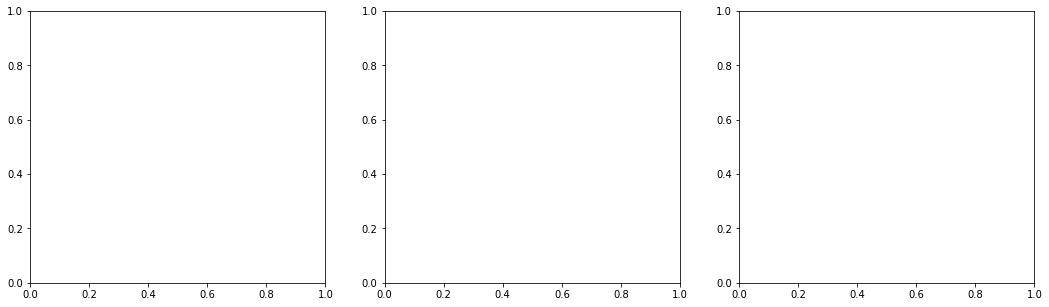

In [3]:
# Rvir / Rmax (Rmax = radius where vmax occurs) 

import symlib_addconcerto1

def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z','vmax'])
    rmax = h['vmax']['rvir'] # the radius where max velocity occurs 

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]
    
    # normalize by 
    r_over_rvir_normalized = r_over_rvir / rmax

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir_normalized.min()), np.log10(r_over_rvir_normalized.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found    
        

def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    rmax = h["rvmax"] # radius where vmax occurs 

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    r_over_rvir = r_over_rvir[r_over_rvir < n_rvir_max]
    r_over_rvir_normalized = r_over_rvir / rmax

    n_subs = len(r_over_rvir)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rvir_normalized.min()), np.log10(r_over_rvir_normalized.max()), n_bins)
    n, _ = np.histogram(r_over_rvir, bins=bins)
    return bins[:-1], n, host_rvir, n_subs


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()








/scratch/rlai3/job_53993246/ipykernel_3094158/2397503435.py:79: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)


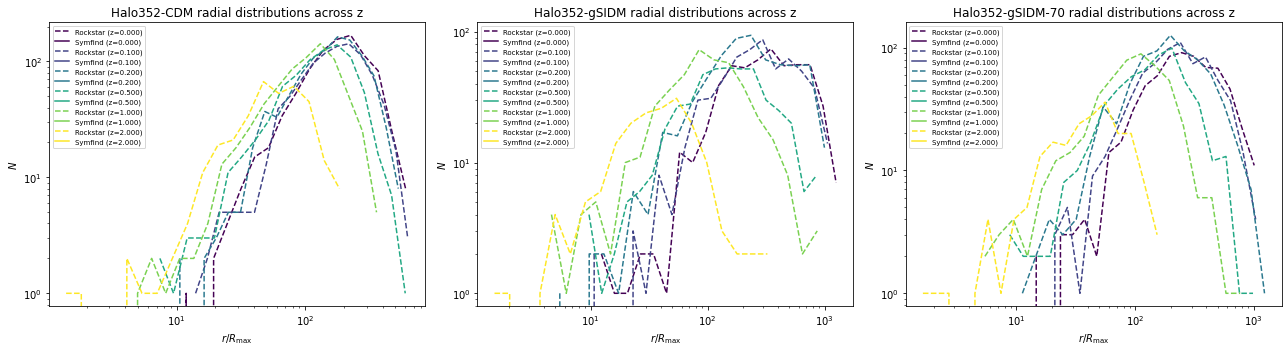

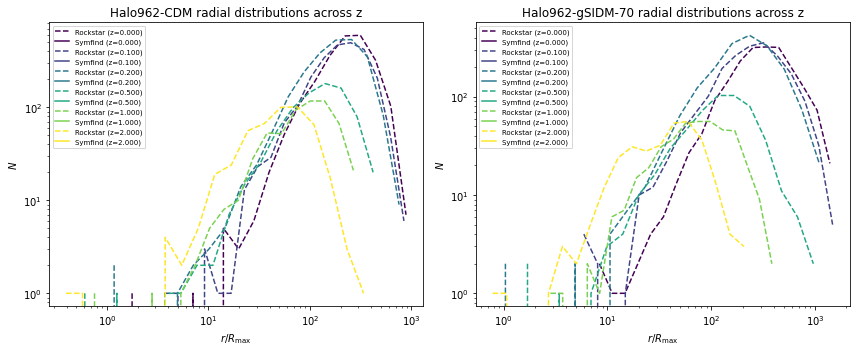

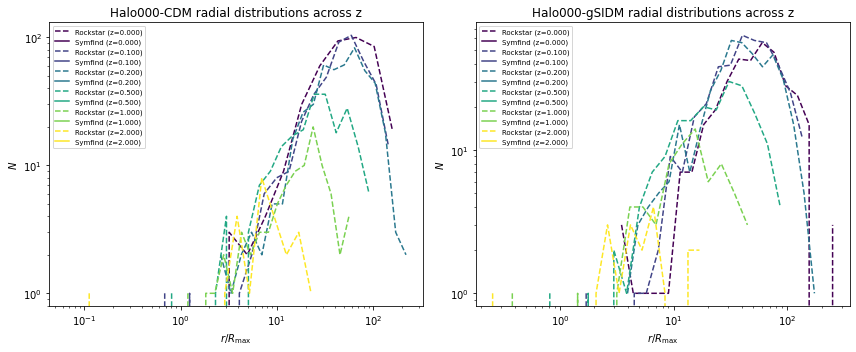

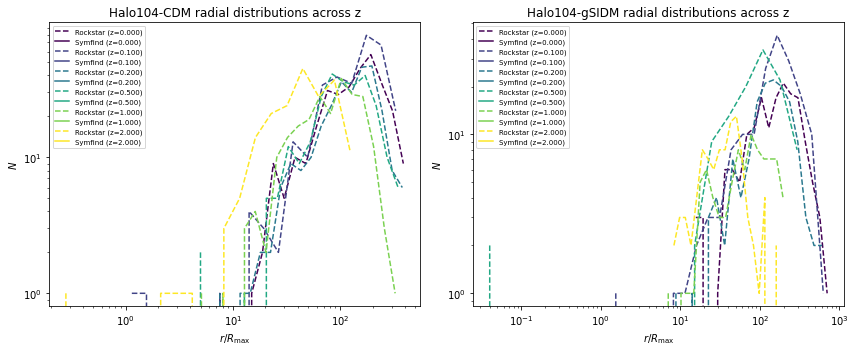

ValueError: The following field(s) are not available: rvmax.
Available fields: scale, id, desc_scale, desc_id, num_prog, pid, upid, desc_pid, phantom, sam_mvir, mvir, rvir, rs, vrms, mmp?, scale_of_last_MM, vmax, x, y, z, vx, vy, vz, Jx, Jy, Jz, Spin, Breadth_first_ID, Depth_first_ID, Tree_root_ID, Orig_halo_ID, Snap_num, Next_coprogenitor_depthfirst_ID, Last_progenitor_depthfirst_ID, Rs_Klypin, Mvir_all, M200b, M200c, M500c, M2500c, Xoff, Voff, Spin_Bullock, b_to_a, c_to_a, A[x], A[y], A[z], b_to_a(500c), c_to_a(500c), A[x](500c), A[y](500c), A[z](500c), T/|U|, Macc, Mpeak, Vacc, Vpeak, Halfmass_Scale, Acc_Rate_Inst, Acc_Rate_100Myr, Acc_Rate_Tdyn.

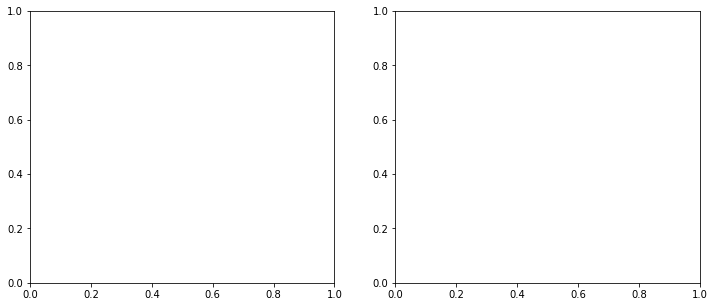

In [2]:
def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    # cap on distance still expressed relative to host Rvir, same aperture as before
    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    in_aperture = r_over_rvir < n_rvir_max

    dists_kept = dists[mass_ok][in_aperture]
    rmax_kept = subs['rvmax'][mass_ok][in_aperture] / 1000.0  # kpc/h -> Mpc/h, matches dists' units

    r_over_rmax = dists_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    rmax_all = h["rvmax"][:, snap_index]   # physical kpc, same convention as host_rvir

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    in_aperture = r_over_rvir < n_rvir_max

    r_kept = r[keep][in_aperture]
    rmax_kept = rmax_all[keep][in_aperture]

    r_over_rmax = r_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir, n_subs


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


# rvir = size of each subhalo, not distance from center of host halo
# rvir/rmax = radius of each subhalo / radius of each subhalo at vmax 
# tells us how far along in gravothermal evolution it is 
# tells us if subhalo is cored or not


In [1]:
# try to add Halo004 
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

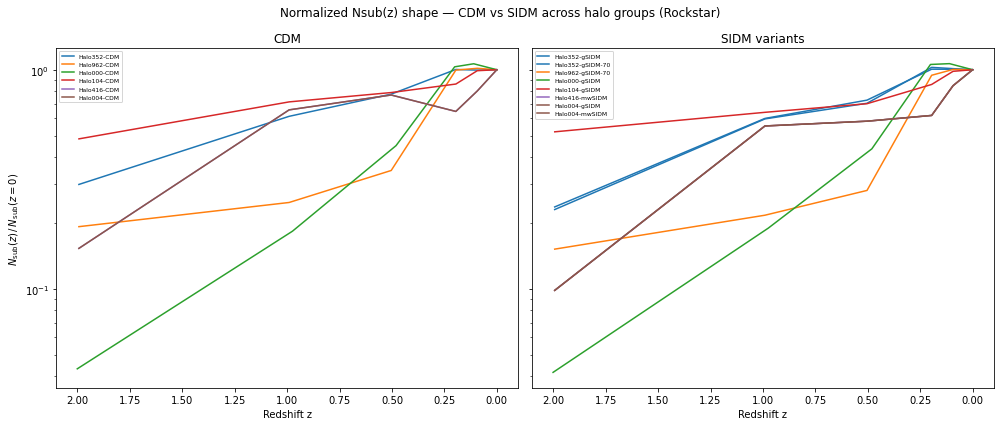

In [5]:
def rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z, mass_cut_factor=300):
    lookup = build_redshift_lookup(hlist_dir)
    mass_cut = mass_cut_factor * particle_mass
    h_hubble = 0.7

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        z_found, hlist_path = find_closest_hlist(target_z, lookup)
        h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid'])

        host_mask_all = h['upid'] == -1
        largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

        subs = h[h['upid'] == largest_halo_id]
        sub_mass = subs['mpeak'] / h_hubble
        n_sub = np.sum(sub_mass > mass_cut)

        z_list.append(z_found)
        nsub_list.append(n_sub)

    nsub_arr = np.array(nsub_list)
    nsub_z0 = nsub_arr[np.argmin(np.abs(np.array(z_list)))]  # value closest to z=0
    return np.array(z_list), nsub_arr / nsub_z0


def symfind_nsub_evol(base_dir, suite, halo_name, list_of_z, mass_cut_factor=300):
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = mass_cut_factor * particle_mass

    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    z_list = []
    nsub_list = []

    for target_z in list_of_z:
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        ok = sf["ok"][:, snap_index]
        sub_masses = sf_hist["mpeak"][ok][1:]
        n_sub = np.sum(sub_masses > mass_cut)

        z_list.append(target_z)
        nsub_list.append(n_sub)

    nsub_arr = np.array(nsub_list)
    nsub_z0 = nsub_arr[np.argmin(np.abs(np.array(z_list)))]
    return np.array(z_list), nsub_arr / nsub_z0

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 
# ADD HALO 004 TO THIS LIST

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
# list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
ax_cdm, ax_sidm = axes

cmap = plt.cm.tab10  # distinct colors per halo group, not a redshift gradient here

for igroup, halo in enumerate(halo_groups):
    color = cmap(igroup % 10)

    for suite, halo_name, hlist_dir, particle_mass in halo:
        rz, r_nsub_norm = rockstar_nsub_evol(hlist_dir, particle_mass, list_of_z)

        target_ax = ax_cdm if 'CDM' in halo_name else ax_sidm
        target_ax.plot(rz, r_nsub_norm, color=color, label=halo_name, lw=1.5)

ax_cdm.set_yscale('log')
ax_cdm.invert_xaxis()
ax_cdm.set_xlabel('Redshift z')
ax_cdm.set_ylabel(r'$N_{\rm sub}(z) \, / \, N_{\rm sub}(z=0)$')
ax_cdm.set_title('CDM')
ax_cdm.legend(fontsize=6)

ax_sidm.set_yscale('log')
ax_sidm.invert_xaxis()
ax_sidm.set_xlabel('Redshift z')
ax_sidm.set_title('SIDM variants')
ax_sidm.legend(fontsize=6)

fig.suptitle('Normalized Nsub(z) shape — CDM vs SIDM across halo groups (Rockstar)')
plt.tight_layout()
plt.show()

<ipython-input-2-6ec6d73721f3>:79: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)


KeyboardInterrupt: 

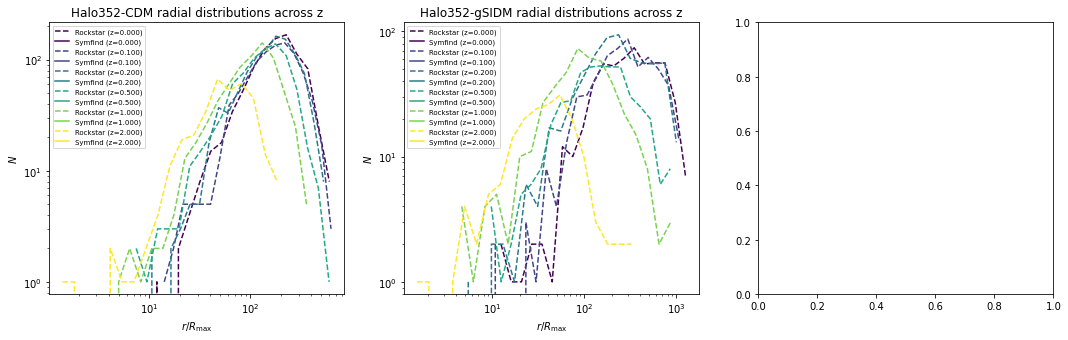

In [2]:
def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    # cap on distance still expressed relative to host Rvir, same aperture as before
    r_over_rvir = dists[mass_ok] / host_rvir_mpc
    in_aperture = r_over_rvir < n_rvir_max

    dists_kept = dists[mass_ok][in_aperture]
    rmax_kept = subs['rvmax'][mass_ok][in_aperture] / 1000.0  # kpc/h -> Mpc/h, matches dists' units

    r_over_rmax = dists_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    rmax_all = h["rvmax"][:, snap_index]   # physical kpc, same convention as host_rvir

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    in_aperture = r_over_rvir < n_rvir_max

    r_kept = r[keep][in_aperture]
    rmax_kept = rmax_all[keep][in_aperture]

    r_over_rmax = r_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir, n_subs

'''
halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]
'''

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


# rvir = size of each subhalo, not distance from center of host halo
# rvir/rmax = radius of each subhalo / radius of each subhalo at vmax 
# tells us how far along in gravothermal evolution it is 
# tells us if subhalo is cored or not

ValueError: no field of name rvir

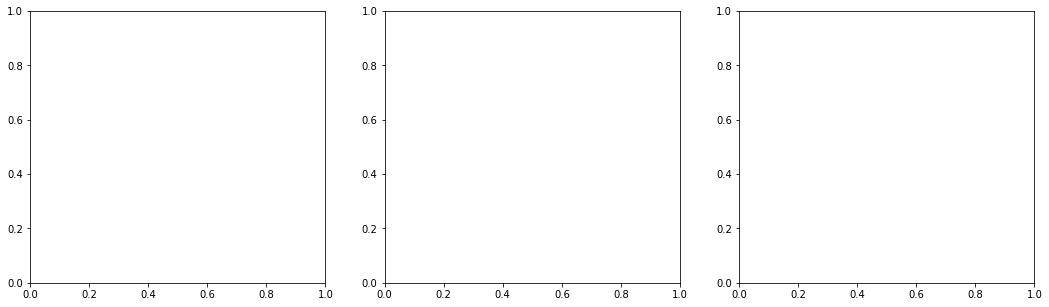

In [7]:
def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)

    sub_mass = subs['mvir'] / h_hubble
    mass_ok = sub_mass > mass_cut

    # aperture cut: keep subhalos within n_rvir_max * host Rvir
    in_aperture = (dists / host_rvir_mpc) < n_rvir_max
    keep = mass_ok & in_aperture

    # per-subhalo concentration proxy: its own Rvir / its own Rmax (both kpc/h, ratio is unitless)
    ratio = subs['rvir'][keep] / subs['rvmax'][keep]
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    in_aperture = (r / host_rvir) < n_rvir_max

    keep = ok & mass_ok & in_aperture
    keep[0] = False  # drop the host itself

    sub_rvir = sf["rvir"][:, snap_index][keep]
    sub_rmax = sf["rvmax"][:, snap_index][keep]

    ratio = sub_rvir / sub_rmax
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir, n_subs




halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [3]:
sim_dir = symlib_addconcerto1.get_host_directory(base_dir, "ConcertoGroupHR", "Halo352-CDM")
sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")
print("sf   fields:", sf.dtype.names)
print("hist fields:", sf_hist.dtype.names)

sf   fields: ('x', 'v', 'r_tidal', 'r_half', 'm_tidal', 'm_tidal_bound', 'm', 'vmax', 'm_raw', 'ok', 'interp', 'f_core', 'f_core_rs', 'd_core_mbp', 'r_half_rs', 'ok_rs', 'is_err', 'is_err_rs')
hist fields: ('mpeak', 'vpeak', 'merger_snap', 'merger_ratio', 'start', 'end', 'is_real', 'is_disappear', 'is_main_sub', 'preprocess', 'first_infall_snap', 'branch_idx', 'false_selection', 'mpeak_pre', 'conv_snap_discrete', 'conv_snap_eps', 'conv_snap_relax', 'conv_snap_relax_hydro', 'disrupt_snap', 'disrupt_snap_rs')


In [ ]:
def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    
    # apply mass and distance but
    dists = getDistance(host, subs, box_size=125)
    sub_mass = subs['mvir'] / h_hubble
    

    
    r_over_rvir = subs['rvir'] / subs['rvmax']
    in_aperture = r_over_rvir < n_rvir_max

    dists_kept = dists[mass_ok][in_aperture]
    rmax_kept = subs['rvmax'][mass_ok][in_aperture] / 1000.0  # kpc/h -> Mpc/h, matches dists' units

    r_over_rmax = dists_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{hlist_path} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs, z_found


def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    rmax_all = h["rvmax"][:, snap_index]   # physical kpc, same convention as host_rvir

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    keep = ok & mass_ok
    keep[0] = False  # drop the host itself

    r_over_rvir = r[keep] / host_rvir
    in_aperture = r_over_rvir < n_rvir_max

    r_kept = r[keep][in_aperture]
    rmax_kept = rmax_all[keep][in_aperture]

    r_over_rmax = r_kept / rmax_kept

    n_subs = len(r_over_rmax)
    if n_subs < 2:
        raise ValueError(
            f"Only {n_subs} subhalo(s) survive the mass cut + radius cap for "
            f"{suite}/{halo_name} at z={target_z} — too few to bin meaningfully."
        )

    bins = np.logspace(np.log10(r_over_rmax.min()), np.log10(r_over_rmax.max()), n_bins)
    n, _ = np.histogram(r_over_rmax, bins=bins)
    return bins[:-1], n, host_rvir, n_subs

'''
halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
]
'''

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$r / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


# rvir = size of each subhalo, not distance from center of host halo
# rvir/rmax = radius of each subhalo / radius of each subhalo at vmax 
# tells us how far along in gravothermal evolution it is 
# tells us if subhalo is cored or not

TypeError: ufunc 'bitwise_and' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

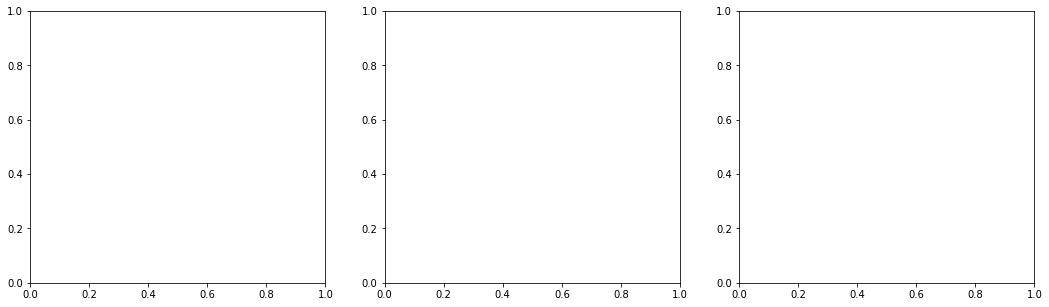

In [3]:
# start radial distribution from scratch


def rockstar_radial_dist(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    
    # apply mass cut and within virial radius
    dists = getDistance(host, subs, box_size=125)
    sub_mass = subs['mvir'] / h_hubble
    subs_valid = subs[dists<host_rvir_mpc & sub_mass > mass_cut]
    
    # of the valid subs, find each subhalos invidiaul virial radius and vmax radius
    ratio_list = []
    for subhalo in subs_valid: 
        
        subhalo_rvir = subs_valid['rvir']
        subhalo_vmax = subs_valid['vmax']
        ratio_list.append(subhalo_rvir / subhalo_vmax)
        
    bins = np.logspace(np.log10(ratio_list.min()), np.log10(ratio_list.max()), n_bins)
    n, _ = np.histogram(ratio_list, bins=bins)
    return bins[:-1], n, host_rvir, n_subs
        
    
def symfind_radial_dist(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    
    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    rmax_all = h["rvmax"][:, snap_index]   # physical kpc, same convention as host_rvir

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut
    
    subs_ok = sf[mass_ok] & sf[r<host_rvir]
    
    ratio_list = []
    for subhalo in subs_ok:
        subhalo_rvir = subhalo['rvir']
        subhalo_rvmax = subhalo['rvmx']
        ratio_list.append(subhalo_rvir / subhalo_rvmax)
        
    bins = np.logspace(np.log10(ratio_list.min()), np.log10(ratio_list.max()), n_bins)
    n, _ = np.histogram(ratio_list, bins=bins)
    return bins[:-1], n, host_rvir, n_subs
    
    
halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs, rockstar_z = rockstar_radial_dist(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_radial_dist(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$rvir / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


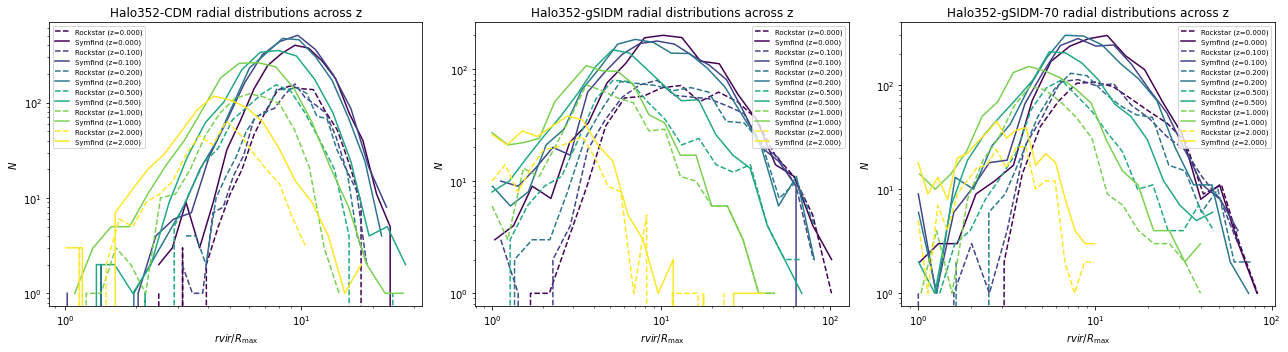

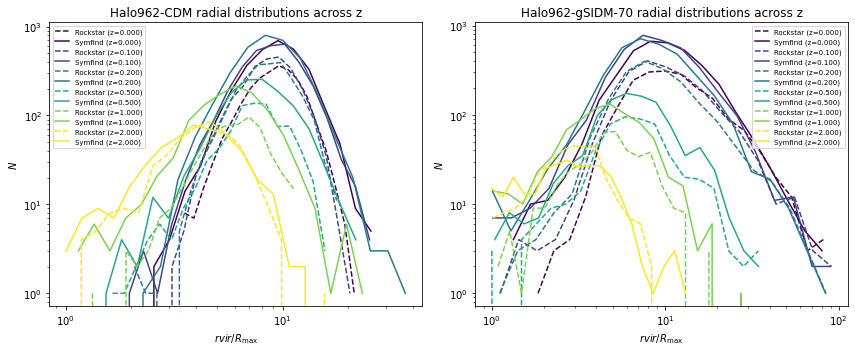

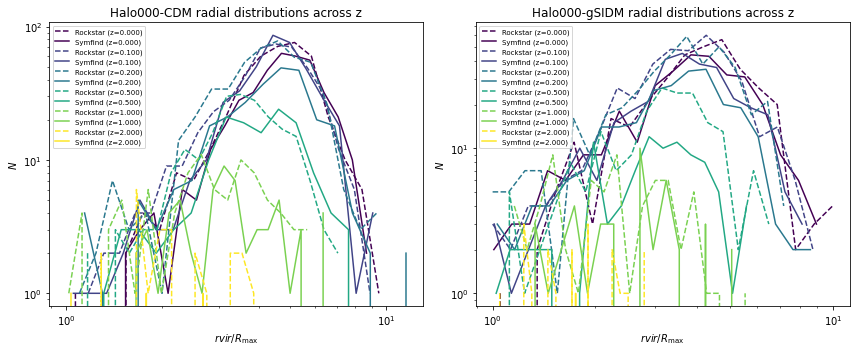

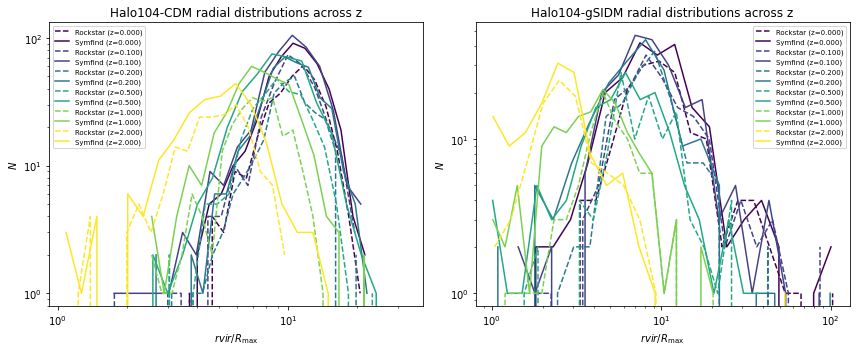

ValueError: The following field(s) are not available: rvmax.
Available fields: scale, id, desc_scale, desc_id, num_prog, pid, upid, desc_pid, phantom, sam_mvir, mvir, rvir, rs, vrms, mmp?, scale_of_last_MM, vmax, x, y, z, vx, vy, vz, Jx, Jy, Jz, Spin, Breadth_first_ID, Depth_first_ID, Tree_root_ID, Orig_halo_ID, Snap_num, Next_coprogenitor_depthfirst_ID, Last_progenitor_depthfirst_ID, Rs_Klypin, Mvir_all, M200b, M200c, M500c, M2500c, Xoff, Voff, Spin_Bullock, b_to_a, c_to_a, A[x], A[y], A[z], b_to_a(500c), c_to_a(500c), A[x](500c), A[y](500c), A[z](500c), T/|U|, Macc, Mpeak, Vacc, Vpeak, Halfmass_Scale, Acc_Rate_Inst, Acc_Rate_100Myr, Acc_Rate_Tdyn.

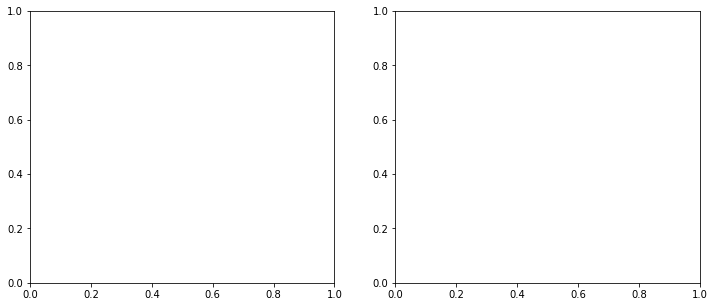

In [2]:
def rockstar_rvir_rvmax(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)
    sub_mass = subs['mvir'] / h_hubble

    keep = (dists < n_rvir_max * host_rvir_mpc) & (sub_mass > mass_cut) & (subs['rvmax'] > 0)
    ratio = subs['rvir'][keep] / subs['rvmax'][keep]
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(f"Only {n_subs} subhalo(s) survive cuts for {hlist_path}")

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs


def symfind_rvir_rvmax(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)  # source of rvir/rvmax -- sf has neither
    host_rvir = h["rvir"][0, snap_index]
    sub_rvir = h["rvir"][:, snap_index]
    sub_rvmax = h["rvmax"][:, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")
    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut

    keep = ok & mass_ok & (r < n_rvir_max * host_rvir) & (sub_rvmax > 0)
    keep[0] = False  # drop the host itself

    ratio = sub_rvir[keep] / sub_rvmax[keep]
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(f"Only {n_subs} subhalo(s) survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir, n_subs


halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]




for halo in halo_groups:
    ncols = len(halo)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if ncols == 1:
        axes = [axes]
    for i, (suite, halo_name, hlist_dir, particle_mass) in enumerate(halo):
        for iz_idx, iz in enumerate(list_of_z):
            rockstar_bins, rockstar_N, rockstar_host, nsubs = rockstar_rvir_rvmax(
                hlist_dir, particle_mass, iz
            )
            symfind_bins, symfind_N, symfind_host_rvir, symfind_nsubs = symfind_rvir_rvmax(
                base_dir, suite, halo_name, iz
            )
            ax = axes[i]
            color = cmap(iz_idx / max(len(list_of_z) - 1, 1))
            ax.plot(rockstar_bins, rockstar_N, label=f"Rockstar (z={iz:.3f})", ls="dashed", color=color)
            ax.plot(symfind_bins, symfind_N, label=f"Symfind (z={iz:.3f})", color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel(r'$rvir / R_{\rm max}$') #ax.set_xlabel(r'$r / R_{\rm vir}$')
            ax.set_ylabel(r'$N$')
            ax.set_title(f"{halo_name} radial distributions across z")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


In [1]:
# try to add Halo004 
import sys
sys.path.append('/expanse/lustre/projects/ddp469/rlai3')
from helpers.SimulationAnalysis import readHlist, getDistance
import numpy as np

import matplotlib.pyplot as plt
import os
import re
import symlib_addconcerto1

#list_of_halos = [Halo352, Halo962, Halo000, Halo104, Halo416] 

def build_redshift_lookup(hlist_dir):
    lookup = []
    for fname in os.listdir(hlist_dir):
        match = re.match(r"hlist_([0-9.]+)\.list", fname)
        if match:
            a = float(match.group(1))
            z = 1.0 / a - 1.0
            lookup.append((z, os.path.join(hlist_dir, fname)))
    lookup.sort(key=lambda pair: pair[0])
    return lookup

def find_closest_hlist(target_z, lookup):
    return min(lookup, key=lambda pair: abs(pair[0] - target_z))

In [6]:
# plot rvir/rvmax vs mass of subhalo for each subhalo 

# rockstar rvir/rmax function required (hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20)
# rockstar_shmf(hlist_dir, particle_mass, target_z):
#def symfind_shmf(base_dir, suite, halo_name, target_z):
#def rockstar_probe_effective_concentration()


# symfind_rvir_rvmax(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
'''
def rockstar_rvir_rvmax(hlist_dir, particle_mass, target_z, n_rvir_max=1, n_bins=20):
    mass_cut = 300 * particle_mass
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)
    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z', 'vmax', 'rvmax'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]
    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs, box_size=125)
    sub_mass = subs['mvir'] / h_hubble

    keep = (dists < n_rvir_max * host_rvir_mpc) & (sub_mass > mass_cut) & (subs['rvmax'] > 0)
    ratio = subs['rvir'][keep] / subs['rvmax'][keep]
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(f"Only {n_subs} subhalo(s) survive cuts for {hlist_path}")

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir_mpc, n_subs


def symfind_rvir_rvmax(base_dir, suite, halo_name, target_z, n_rvir_max=1, n_bins=20):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)  # source of rvir/rvmax -- sf has neither
    host_rvir = h["rvir"][0, snap_index]
    sub_rvir = h["rvir"][:, snap_index]
    sub_rvmax = h["rvmax"][:, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")
    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    mass_ok = sf_hist["mpeak"] > mass_cut

    keep = ok & mass_ok & (r < n_rvir_max * host_rvir) & (sub_rvmax > 0)
    keep[0] = False  # drop the host itself

    ratio = sub_rvir[keep] / sub_rvmax[keep]
    ratio = ratio[np.isfinite(ratio) & (ratio > 0)]

    n_subs = len(ratio)
    if n_subs < 2:
        raise ValueError(f"Only {n_subs} subhalo(s) survive cuts for {suite}/{halo_name} at z={target_z}")

    bins = np.logspace(np.log10(ratio.min()), np.log10(ratio.max()), n_bins)
    n, _ = np.histogram(ratio, bins=bins)
    return bins[:-1], n, host_rvir, n_subs




def symfind_shmf(base_dir, suite, halo_name, target_z):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]

    n_vir, _ = np.histogram(sub_masses, bins=bins)
    N_vir = np.cumsum(n_vir[::-1])[::-1]

    return bins[:-1], N_vir 

def rockstar_shmf(hlist_dir, particle_mass, target_z):
    """Load the snapshot closest to target_z, find the largest host, and
    return SHMF curves for r<Rvir."""
    mass_cut = 300 * particle_mass   # Msun
    h_hubble = 0.7

    lookup = build_redshift_lookup(hlist_dir)
    z_found, hlist_path = find_closest_hlist(target_z, lookup)

    h = readHlist(hlist_path, ['id', 'mvir', 'mpeak', 'upid', 'rvir', 'x', 'y', 'z'])

    host_mask_all = h['upid'] == -1
    largest_halo_id = h['id'][host_mask_all][h['mvir'][host_mask_all].argmax()]

    host = h[h['id'] == largest_halo_id][0]
    host_rvir_mpc = host['rvir'] / 1000.0   # kpc/h -> Mpc/h

    subs = h[h['upid'] == largest_halo_id]
    dists = getDistance(host, subs)
    within_rvir = dists < host_rvir_mpc

    mass_subs = subs['mpeak'][within_rvir] / h_hubble
    mass_subs = mass_subs[mass_subs > mass_cut]

    bins = np.logspace(np.log10(mass_subs.min()), np.log10(mass_subs.max()), 30)
    n, _ = np.histogram(mass_subs, bins=bins)
    N = np.cumsum(n[::-1])[::-1]

    return bins[:-1], N, host, z_found

# plot 
def symfind_eff_c_mvir_scatter(base_dir, suite, halo_name, target_z,n_rvir_max=1, n_bins=20): # would it be better to invoke already established rvir/rvmax functions or to hard 
    
    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]
    
    
    
    # list_of_subhalos = symfindaddconcerto1.read_subhalos()
    subhalo_mass_list = []
    eff_con_list = []
    for i_subhalo in list_of_subhalos:
        subhalo_mass = list_of_subhalos[i_subhalo]['mvir']
        eff_con = (list_of_subhalos[i_subhalo]['rvir'])/(list_of_subhalos[isubhalo]['rvmax'])
        subhalo_mass_list.append(subhalo_mass)
        eff_con_list.append(eff_con)
    
    
    return subhalo_mass_list, eff_con_list '''





def symfind_eff_c_mvir_scatter(base_dir, suite, halo_name, target_z,n_rvir_max=1, n_bins=20):

    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass
    m_min, m_max = mass_cut, 1e14
    n_bins = 300
    bins = 10 ** np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    # Rockstar read: only needed for the host's Rvir/position, since
    # Symfind doesn't independently define host halo properties.
    h, _ = symlib_addconcerto1.read_subhalos(sim_dir)
    host_rvir = h["rvir"][0, snap_index]

    # Symfind read: this is the actual particle-tracking catalog — the piece
    # that was missing entirely.
    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix = "")

    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index] & (r < host_rvir)

    sub_masses = sf_hist["mpeak"][ok][1:]
    sub_masses = sub_masses[sub_masses > mass_cut]
    rvir_list = sf_hist[sub_masses]['rvir']
    rvmax_list = sf_hist[sub_masses]['rvmax']
    eff_con_list = rvir_list/rvmax_list
    return sub_masses, eff_con_list

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]


suite, halo_name, hlist_dir, particle_mass = halo_groups[0][0]
target_z = list_of_z[0]

sub_masses, eff_con_list = symfind_eff_c_mvir_scatter(base_dir, suite, halo_name,target_z,n_rvir_max=1, n_bins=20)
plt.scatter(sub_masses,eff_con_list)


IndexError: arrays used as indices must be of integer (or boolean) type

In [3]:
halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 

base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

# test to see if this yields the correct labels 
suite, halo_name, hlist_dir, particle_mass = halo_groups[0][0]
print(suite, halo_name, hlist_dir, particle_mass)

ConcertoGroupHR Halo352-CDM /expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists 400000.0


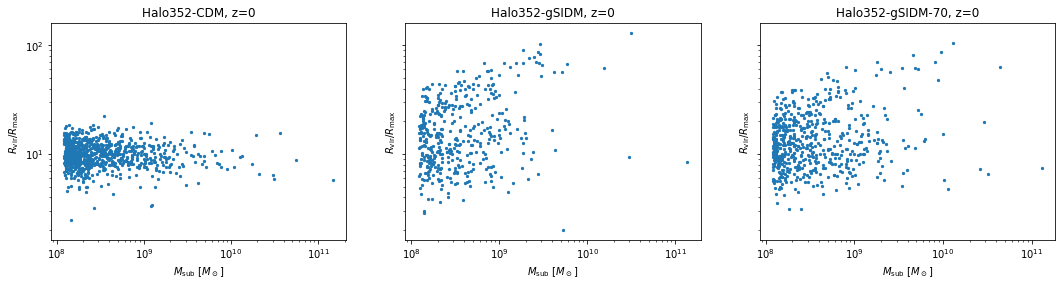

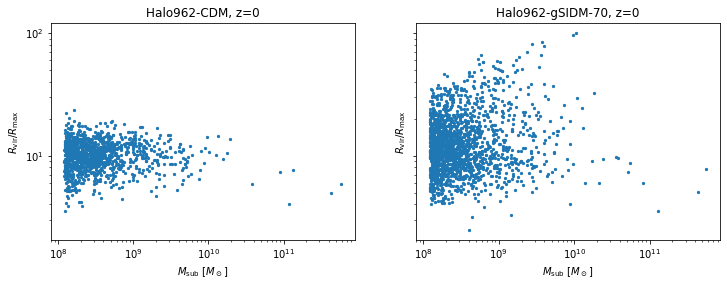

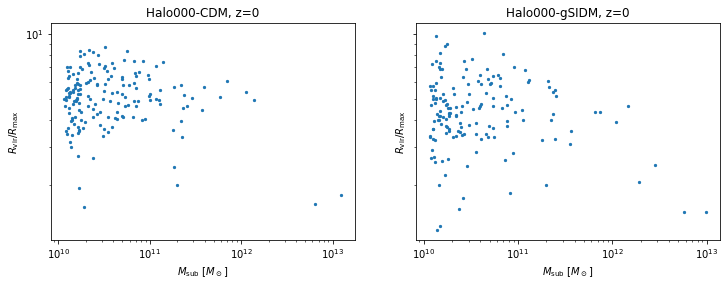

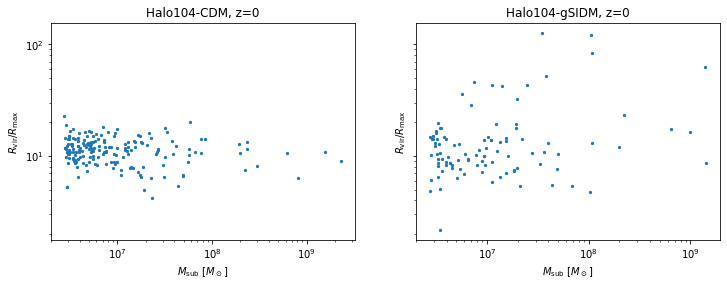

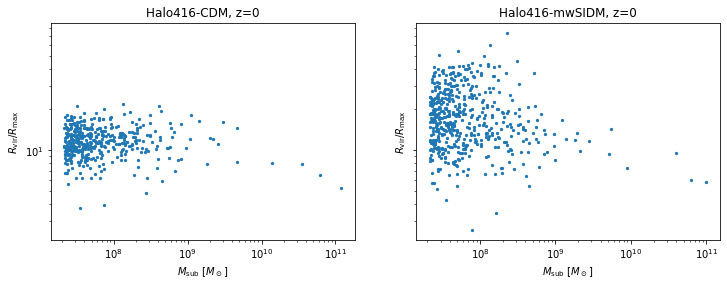

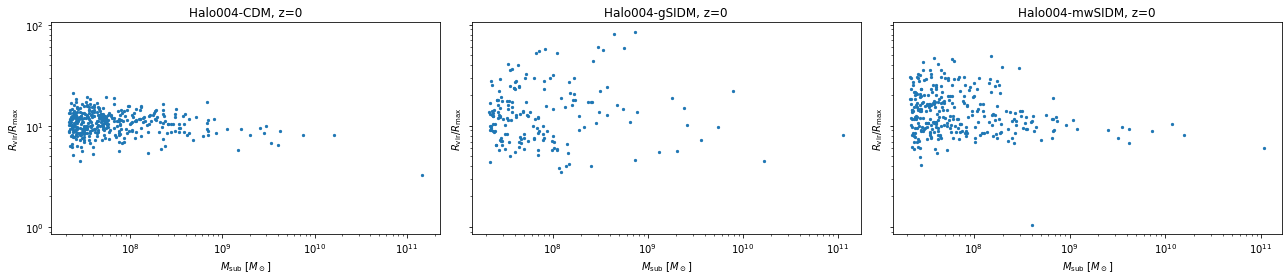

In [2]:
def symfind_eff_c_mvir_scatter(base_dir, suite, halo_name, target_z, n_rvir_max=1):
    params = symlib_addconcerto1.simulation_parameters(suite)
    particle_mass = params["mp"] / params["h100"]
    mass_cut = 300 * particle_mass

    sim_dir = symlib_addconcerto1.get_host_directory(base_dir, suite, halo_name)
    scale_factors = symlib_addconcerto1.scale_factors(sim_dir)
    target_a = 1 / (1 + target_z)
    snap_index = np.argmin(np.abs(scale_factors - target_a))

    h, hist = symlib_addconcerto1.read_subhalos(sim_dir)  # source of rvir/rvmax
    host_rvir = h["rvir"][0, snap_index]
    sub_rvir = h["rvir"][:, snap_index]
    sub_rvmax = h["rvmax"][:, snap_index]

    sf, sf_hist = symlib_addconcerto1.read_symfind(sim_dir, suffix="")
    r = np.sqrt(np.sum(sf["x"][:, snap_index] ** 2, axis=1))
    ok = sf["ok"][:, snap_index]
    # mpeak = sf_hist["m"] # seeing if we can replace mpeak with m
    current_masses = sf["m"][:, snap_index]

    keep = ok & (current_masses > mass_cut) & (r < n_rvir_max * host_rvir) & (sub_rvmax > 0)
    keep[0] = False  # drop the host itself

    sub_masses = current_masses[keep]
    eff_con = sub_rvir[keep] / sub_rvmax[keep]

    valid = np.isfinite(eff_con) & (eff_con > 0)
    return sub_masses[valid], eff_con[valid]

halo_groups = [
    [["ConcertoGroupHR",   "Halo352-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_8k/rockstar/hlists',     4e5],
     ["ConcertoGroupHR",   "Halo352-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo352/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoGroupHR",   "Halo962-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/cdm_8k/rockstar/hlists',      4e5],
     ["ConcertoGroupHR",   "Halo962-gSIDM-70",  '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo962/sidm_70_8k/rockstar/hlists',  4e5]],
    [["ConcertoLClusterHR","Halo000-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/cdm_16k/rockstar/hlists',    2.7e7],
     ["ConcertoLClusterHR","Halo000-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo_000/GroupSIDM_16k/rockstar/hlists', 2.7e7]],
    [["ConcertoLMCHR",     "Halo104-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/cdm_32k/rockstar/hlists',     6.3e3],
     ["ConcertoLMCHR",     "Halo104-gSIDM",     '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo104/GroupSIDM_32k/rockstar/hlists', 6.3e3]],
    [["ConcertoMW416HR",   "Halo416-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW416HR",   "Halo416-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]],
    [["ConcertoMW004HR",   "Halo004-CDM",       '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/cdm_8k/rockstar/hlists',      5e4],
     ["ConcertoMW004HR",   "Halo004-gSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4],
     ["ConcertoMW004HR",   "Halo004-mwSIDM",    '/expanse/lustre/projects/ddp469/enadler/Concerto/Rockstar/Halo416/SIDM_16k/rockstar/hlists',    5e4]]
] 


base_dir = '/expanse/lustre/projects/ddp469/enadler/Concerto/Symfind/'
cmap = plt.cm.viridis
list_of_z = [0, 0.1, 0.2, 0.5, 1.0, 2.0]

#ncols = len(halo)
#fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
#fig, ax = plt.subplots(1,3, figsize = (20,10))

#halo_0 = halo_groups[0]
#ncols = len(halo_0)
#fig, ax = plt.subplots(1, ncols, figsize=(6*ncols, 5))

for i_group in halo_groups: 
    
    ncols = len(i_group)
    fig, ax = plt.subplots(1, ncols, figsize=(6*ncols, 4), sharey=True)

    for i,halo in enumerate(i_group): 

        suite, halo_name, hlist_dir, particle_mass = halo
        target_z = list_of_z[0]

        sub_masses, eff_con_list = symfind_eff_c_mvir_scatter(base_dir, suite, halo_name, target_z, n_rvir_max=1)
        ax[i].scatter(sub_masses, eff_con_list,s=5)
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
        ax[i].set_xlabel(r'$M_{\rm sub}$ [$M_\odot$]')
        ax[i].set_ylabel(r'$R_{\rm vir}/R_{\rm max}$')
        ax[i].set_title(f"{halo_name}, z={target_z}")
plt.tight_layout()
plt.show()